# Latent Volatility Modelling Through Bayesian Machine Learning

Estimating latent volatility trends via Bayesian inference on daily S&P 500 data. Models are developed on priors, tested under in-sample regression, and evaluated under sequential (out-of-sample) updating — see below for each stage.


## What is Volatility?

Volatility is defined as the standard deviation of daily log returns — an unobservable ("latent") quantity, since it's not directly published like price. 

## Import and Process Data

Data is imported from Yahoo Finance in three sets, corresponding to the three stages of the analysis:

- **2013–2017**: developing priors
- **2018–2021**: testing under regression (in-sample) conditions
- **2022–2025**: testing under sequential updating (out-of-sample)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats as scipy_stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
import yfinance as yf
from scipy.stats import beta as beta_dist
from scipy.stats import gamma as gamma_dist
from scipy import integrate
np.random.seed(42)

# Download data
full_data = yf.download("SPY",
                         start="2013-01-01",
                         end="2025-12-31",
                         auto_adjust=True,
                         progress=False)


Below, the daily log returns are computed for each time period.

In [2]:
def data_returns(data):
    '''Compute log returns from a price series r_t = ln(P_t/P_(t-1))'''
    return np.log(data["Close"]).diff().dropna()
full_returns = data_returns(full_data)

# Split by date
prior_returns      = full_returns["2013-01-01":"2017-12-31"]
regression_returns = full_returns["2018-01-01":"2021-12-31"]
sequential_returns = full_returns["2022-01-01":"2025-12-31"]

# 1d for computation
prior_returns_1d      = prior_returns.values.flatten()
regression_returns_1d = regression_returns.values.flatten()
sequential_returns_1d = sequential_returns.values.flatten()

prior_dates = prior_returns.index
regression_dates = regression_returns.index
sequential_dates = sequential_returns.index

# check type/date
print(type(prior_returns))          
print(type(prior_returns_1d))        

print(prior_returns.shape)          
print(prior_returns_1d.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>
(1258, 1)
(1258,)


### Dates indices for all periods

For future computation, it makes sense to lay out the date indices for all the periods.

In [3]:
import scipy.special
print(scipy.special.gammaln(5))

3.1780538303479458


In [4]:
# Prior period
def print_date(dates, title):
      print(f"{title}: {dates[0].date()} to {dates[-1].date()}, "
            f"n={len(dates)}")

print_date(prior_dates, 'Prior_Returns')
print_date(regression_dates, 'Regression_Returns')
print_date(sequential_dates, 'Sequential_Returns')

Prior_Returns: 2013-01-03 to 2017-12-29, n=1258
Regression_Returns: 2018-01-02 to 2021-12-31, n=1008
Sequential_Returns: 2022-01-03 to 2025-12-30, n=1002


# General Procedure

3 models will be tested, a baseline rolling average, a time series model and a stochastic model.

Note that each model will be developed and then tested on both regression and sequential data. At the end of this notebook, the models will be compared to each other using different metrics like Realized Volatility (QLIKE and Realized Volatility Coverage), PIT Histogram and Return Coverage



## Regression

## Regression Conditions

Priors developed on 2013–2017 data are updated using 2018–2021 data to obtain posterior samples for model parameters.

This is an in-sample test: the fitted parameters are propagated forward through the regression-period data itself to obtain implied volatility paths.



## Sequential Updating

Starting with posterior samples from the regression period, models are sequentially updated over windows spanning 2022–2025.

In each window:
1. Volatility is forecast using the previous window's posterior samples
2. The posterior is then updated by treating the previous window's posterior as the new prior (via fitting posterior samples to the original prior distributions), conditioned on the current window's data

## Baseline: Rolling Average

The rolling average calculates the volatility over the past month 21 days, and uses it as the estimate for the volatility over the next 21 days.

This volatility is the sample standard deviation of the previous $h$ log returns:

\begin{equation*}
    \hat{\sigma}_t^{roll} = \sqrt{\frac{1}{h-1}
    \sum_{i=0}^{h-1}(r_{t-i} - \bar{r}_t)^2}
\end{equation*}
where $\bar{r}_t = \frac{1}{h}\sum_{i=0}^{h-1} r_{t-i}$ is the rolling mean and $h=21$

In [5]:
def rolling_vol(returns, h=21):
    '''Return Rolling Volatility'''
    return returns.rolling(h).std()


full_rolling = rolling_vol(full_returns)

rolling_prior      = full_rolling.loc[prior_dates].dropna()
rolling_regression = full_rolling.loc[regression_dates].dropna()
rolling_sequential = full_rolling.loc[sequential_dates].dropna()

rolling_prior_1d      = rolling_prior.values.flatten()
rolling_regression_1d = rolling_regression.values.flatten()
rolling_sequential_1d = rolling_sequential.values.flatten()

rolling_prior_dates      = rolling_prior.index
rolling_regression_dates = rolling_regression.index
rolling_sequential_dates = rolling_sequential.index

print_date(rolling_prior_dates, 'Prior_Rolling')
print_date(rolling_regression_dates, 'Regression_Rolling')
print_date(rolling_sequential_dates, 'Sequential_Rolling')

Prior_Rolling: 2013-02-01 to 2017-12-29, n=1238
Regression_Rolling: 2018-01-02 to 2021-12-31, n=1008
Sequential_Rolling: 2022-01-03 to 2025-12-30, n=1002


## Metrics


## Historical Volatility

### What is Historical Volatility

The historical volatility is the standard deviation of log returns over the next 21 log returns. It represents the average volatility throughout that period by assuming constant volatility throughout this period.

In particular, 

\begin{equation*}
    \hat{\sigma}_t^{empirical} = \sqrt{\frac{1}{h-1}
    \sum_{i=1}^{h}(r_{t+i} - \bar{r}_t)^2}
\end{equation*}

where $r_{t}=ln(\frac{P_{t}}{P_{t-1}})$ and $\bar{r}_t = \frac{1}{h}\sum_{i=1}^{h} r_{t+i}$ and $h=21$ 



### Model Historical Volatility

In order to use the empirical historical volatility for a fair comparison, a model equivalent historical volatility is required.

For the rolling average, this is relatively straightforward since the rolling volatility estimates are already in the appropriate format

Note that the final values have NaN since computing their realized volatility would require data from 2026 onwards.

In [6]:
def historical_vol(returns, h=21):
    '''Compute forward-looking historical volatility: std of r_{t+1},...,r_{t+h}.'''
    return returns.rolling(h).std().shift(-h)

full_hv = historical_vol(full_returns)

hv_prior      = full_hv.loc[prior_dates].dropna()
hv_regression = full_hv.loc[regression_dates].dropna()
hv_sequential = full_hv.loc[sequential_dates].dropna()

hv_prior_1d      = hv_prior.values.flatten()
hv_regression_1d = hv_regression.values.flatten()
hv_sequential_1d = hv_sequential.values.flatten()

hv_prior_dates      = hv_prior.index
hv_regression_dates = hv_regression.index
hv_sequential_dates = hv_sequential.index

print_date(hv_prior_dates, 'Prior_hv')
print_date(hv_regression_dates, 'Regression_hv')
print_date(hv_sequential_dates, 'Sequential_hv')

Prior_hv: 2013-01-03 to 2017-12-29, n=1258
Regression_hv: 2018-01-02 to 2021-12-31, n=1008
Sequential_hv: 2022-01-03 to 2025-11-28, n=981


### QLIKE Comparison with Realized Voalatility

### What is QLIKE?

The QLIKE estimator compares the pointwise estimates of realized volatility.

\begin{equation*}
    \text{QLIKE}(\hat{\sigma}_t, RV_t) = \frac{RV_t^2}{\hat{\sigma}_t^2} 
    - \log\!\left(\frac{RV_t^2}{\hat{\sigma}_t^2}\right) - 1
\end{equation*}

### Why QLIKE?

QLIKE Loss is used since it takes into account the volatility asymmetry (generally underpredicting volatility is worse than overpredicting volatility)

Furthermore, the QLIKE loss is known to work well with volatility proxies (like historical volatility).

### Interpreting QLIKE

Simply put, a lower mean QLIKE loss is better since it suggests the model closely fits the realized volatility. 

In [7]:
def align_series(series_a, series_b):
    '''Align two Series on their common dates, returning aligned 1D arrays + the shared index.'''
    common_dates = series_a.index.intersection(series_b.index)
    a_aligned = series_a.loc[common_dates]
    b_aligned = series_b.loc[common_dates]
    return a_aligned.values.flatten(), b_aligned.values.flatten(), common_dates

forecast_prior_rolling,      actual_prior_rolling,      dates_prior_rolling      = align_series(rolling_prior, hv_prior)
forecast_regression_rolling, actual_regression_rolling, dates_regression_rolling = align_series(rolling_regression, hv_regression)
forecast_sequential_rolling, actual_sequential_rolling, dates_sequential_rolling  = align_series(rolling_sequential, hv_sequential)

print_date(dates_prior_rolling, 'Prior_Aligned')
print_date(dates_regression_rolling, 'Regression_Aligned')
print_date(dates_sequential_rolling, 'Sequential_Aligned')

Prior_Aligned: 2013-02-01 to 2017-12-29, n=1238
Regression_Aligned: 2018-01-02 to 2021-12-31, n=1008
Sequential_Aligned: 2022-01-03 to 2025-11-28, n=981


In [8]:
def qlike(sigma, rv):
    assert len(sigma) == len(rv), f"Length mismatch: sigma={len(sigma)}, rv={len(rv)}"
    ratio = rv**2 / sigma**2
    return ratio - np.log(ratio) - 1

ql_regression_rolling = qlike(forecast_regression_rolling, actual_regression_rolling)
ql_sequential_rolling = qlike(forecast_sequential_rolling, actual_sequential_rolling)

print(f"QLIKE (regression): mean = {ql_regression_rolling.mean():.4f}")
print(f"QLIKE (sequential): mean = {ql_sequential_rolling.mean():.4f}")

QLIKE (regression): mean = 1.2659
QLIKE (sequential): mean = 0.3955


Note that the high QLIKE values in the regression period is likely due to COVID.

## 

In the regression section, COVID is important including the COVID spike etc.

For the regression segregate the QLIKE keeping COVID in mind.


In [9]:
def period_indices(dates, boundaries):
    '''Convert a list of boundary dates into (start_idx, end_idx) pairs for each period.
    Works for any number of periods — COVID (3) or sequential windows (8).'''
    return [(np.searchsorted(dates, boundaries[i]), np.searchsorted(dates, boundaries[i+1]))
            for i in range(len(boundaries) - 1)]


def metric_by_period(forecast, actual, dates, boundaries, metric_fn):
    '''Compute a per-day metric, then average within each period.'''
    values = metric_fn(forecast, actual)
    results = {}
    for i, (start_idx, end_idx) in enumerate(period_indices(dates, boundaries)):
        results[f"period_{i+1}"] = {
            'start': boundaries[i], 'end': boundaries[i+1],
            'value': values[start_idx:end_idx].mean()
        }
    return results


def mask_by_period(inside_mask, dates, boundaries):
    '''Average a precomputed boolean mask within each period.'''
    results = {}
    for i, (start_idx, end_idx) in enumerate(period_indices(dates, boundaries)):
        results[f"period_{i+1}"] = {
            'start': boundaries[i], 'end': boundaries[i+1],
            'value': np.mean(inside_mask[start_idx:end_idx])
        }
    return results


In [10]:
def covid_breakdown(forecast, actual, dates, covid_start_date, covid_end_date, metric_fn):
    '''pre/covid/post breakdown of a metric — uses dates.min()/max() as the outer bounds,
    which correctly represents "everything this specific (possibly trimmed) series has available".'''
    boundaries = [dates.min(), covid_start_date, covid_end_date, dates.max()]
    result = metric_by_period(forecast, actual, dates, boundaries, metric_fn)
    return {'pre': result['period_1']['value'], 'covid': result['period_2']['value'], 'post': result['period_3']['value']}

covid_start_date = pd.Timestamp("2020-01-30")
covid_end_date = pd.Timestamp("2020-04-30")

qlike_covid_rolling = covid_breakdown(
    forecast_regression_rolling, actual_regression_rolling, dates_regression_rolling,
    covid_start_date, covid_end_date, qlike
)

In [11]:
# ── 7. Printing QLIKE COVID breakdown ──
def print_covid_breakdown(breakdown, label="", metric_name="Metric"):
    print(f"{label} — Pre-COVID {metric_name}:  {breakdown['pre']:.4f}")
    print(f"{label} — COVID {metric_name}:      {breakdown['covid']:.4f}")
    print(f"{label} — Post-COVID {metric_name}: {breakdown['post']:.4f}")

print_covid_breakdown(qlike_covid_rolling, label="Rolling Average", metric_name="QLIKE")

Rolling Average — Pre-COVID QLIKE:  1.2380
Rolling Average — COVID QLIKE:      6.3625
Rolling Average — Post-COVID QLIKE: 0.5425


In [12]:
# ── 8. HV Coverage ──
def hv_coverage_intervals(forecast, actual, level=90, sigma_eta=None):
    if sigma_eta is None:
        sigma_eta = np.std(np.log(actual) - np.log(forecast))
    z = scipy_stats.norm.ppf(1 - (100 - level) / 200)
    lower = forecast * np.exp(-z * sigma_eta)
    upper = forecast * np.exp(+z * sigma_eta)
    inside = (actual >= lower) & (actual <= upper)
    return lower, upper, inside, sigma_eta

def hv_coverage(forecast, actual, levels=[50, 60, 70, 80, 85, 90, 95, 99]):
    sigma_eta = np.std(np.log(actual) - np.log(forecast))
    results = {}
    for level in levels:
        _, _, inside, _ = hv_coverage_intervals(forecast, actual, level, sigma_eta)
        results[level] = np.mean(inside)
    return sigma_eta, results

sigma_eta_regression_rolling, hv_coverage_rolling = hv_coverage(forecast_regression_rolling, actual_regression_rolling)

In [13]:
# ── 9. Printing HV Coverage ──
def print_hv_coverage(sigma_eta, results, label=""):
    print(f"{label} — Measurement noise std: {sigma_eta:.4f}")
    print("Coverage at different CI levels:")
    print("-" * 40)
    for level, coverage in results.items():
        print(f"{level}% CI coverage: {coverage:.2%}")

print_hv_coverage(sigma_eta_regression_rolling, hv_coverage_rolling, label="Rolling Average")

Rolling Average — Measurement noise std: 0.5822
Coverage at different CI levels:
----------------------------------------
50% CI coverage: 52.28%
60% CI coverage: 61.41%
70% CI coverage: 70.54%
80% CI coverage: 80.46%
85% CI coverage: 84.42%
90% CI coverage: 89.78%
95% CI coverage: 95.34%
99% CI coverage: 99.11%


In [14]:
# ── 10. Single-level (90%) bounds for plotting/COVID coverage breakdown ──
lower_90_regression_rolling, upper_90_regression_rolling, inside_90_regression_rolling, _ = hv_coverage_intervals(
    forecast_regression_rolling, actual_regression_rolling, level=90, sigma_eta=sigma_eta_regression_rolling
)

In [15]:
# ── 11. RV Coverage COVID breakdown ──
def hv_coverage_covid_breakdown(inside_mask, dates, covid_start_date, covid_end_date):
    boundaries = [dates.min(), covid_start_date, covid_end_date, dates.max()]
    result = mask_by_period(inside_mask, dates, boundaries)
    return {'pre': result['period_1']['value'], 'covid': result['period_2']['value'], 'post': result['period_3']['value']}

covid_coverage_rolling = hv_coverage_covid_breakdown(
    inside_90_regression_rolling, dates_regression_rolling, covid_start_date, covid_end_date
)

In [16]:
# ── 12. Printing RV Coverage COVID breakdown ──
def print_hv_coverage_covid(breakdown, label="", level=90):
    print(f"At {level}% CI coverage")
    print(f"{label} — Pre-COVID coverage:  {breakdown['pre']:.2%}")
    print(f"{label} — COVID coverage:      {breakdown['covid']:.2%}")
    print(f"{label} — Post-COVID coverage: {breakdown['post']:.2%}")

print_hv_coverage_covid(covid_coverage_rolling, label="Rolling Average")

At 90% CI coverage
Rolling Average — Pre-COVID coverage:  88.70%
Rolling Average — COVID coverage:      52.38%
Rolling Average — Post-COVID coverage: 96.68%


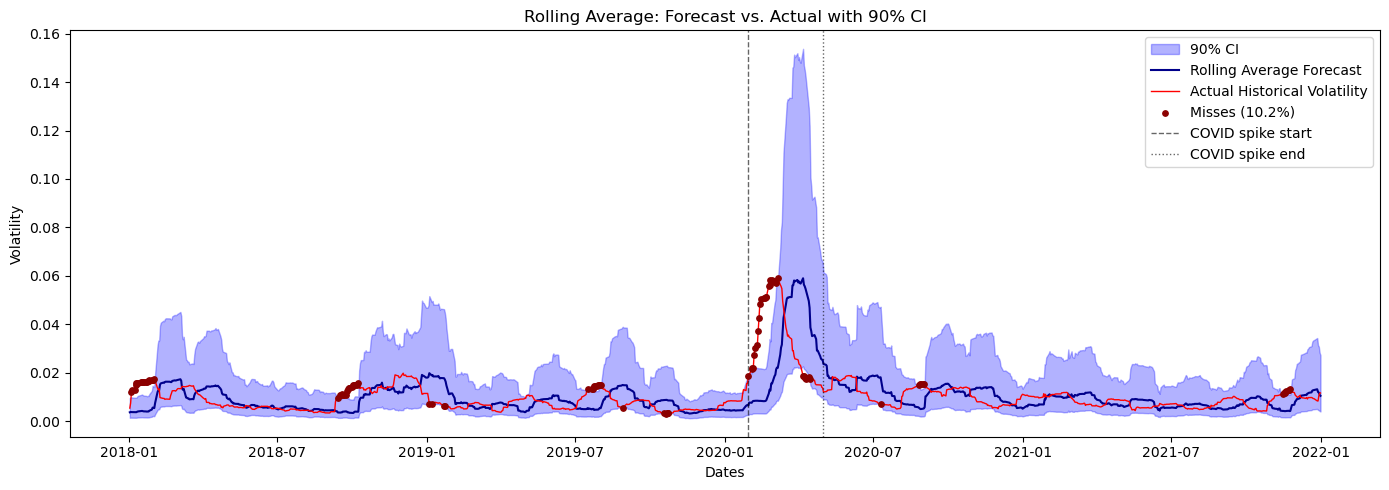

In [17]:
# ── 13. Plotting ──
def plot_hv_coverage(forecast, actual, dates, lower, upper, inside, level=90, label="Model",
                      boundary_dates=None, boundary_labels=None, boundary_styles=None):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.fill_between(dates, lower, upper, alpha=0.3, color='blue', label=f'{level}% CI')
    ax.plot(dates, forecast, color='darkblue', lw=1.5, label=f'{label} Forecast')
    ax.plot(dates, actual, color='red', lw=1, label='Actual Historical Volatility')

    miss_idx = np.where(~inside)[0]
    miss_pct = (1 - np.mean(inside)) * 100
    ax.scatter(dates[miss_idx], actual[miss_idx], color='darkred', s=15, zorder=5, label=f'Misses ({miss_pct:.1f}%)')

    if boundary_dates is not None:
        for i, b in enumerate(boundary_dates):
            if dates[0] <= b <= dates[-1]:
                style = boundary_styles[i] if boundary_styles else '--'
                lbl = boundary_labels[i] if boundary_labels else ('Boundary' if i == 0 else None)
                ax.axvline(b, color='black', linestyle=style, alpha=0.6, lw=1, label=lbl)

    ax.set_title(f"{label}: Forecast vs. Actual with {level}% CI")
    ax.set_xlabel("Dates"); ax.set_ylabel("Volatility"); ax.legend()
    plt.tight_layout(); plt.show()

plot_hv_coverage(
    forecast_regression_rolling, actual_regression_rolling, dates_regression_rolling,
    lower_90_regression_rolling, upper_90_regression_rolling, inside_90_regression_rolling,
    level=90, label="Rolling Average",
    boundary_dates=[covid_start_date, covid_end_date],
    boundary_labels=['COVID spike start', 'COVID spike end'],
    boundary_styles=['--', ':']
)

Historical Volatility Coverage for baseline

Since the baseline doesn't have a model assumption, need to assume normal distribution for this test to work

### Output from these Results

While overall RV coverage for the rolling baseline is well-calibrated (e.g. 89.78% at the 90% level), this aggregate figure masks severe regime-dependent miscalibration: coverage drops to 52.38% during the COVID period, before overshooting to 96.69% immediately after. This illustrates the homoscedasticity limitation of the log-normal noise model (a single, period-wide $\hat\sigma_\eta$ cannot adapt to a volatility regime shift), compounded by the rolling average's inherent sluggishness in adjusting its own point forecast — both contributing to under-coverage during the shock and over-coverage in its immediate aftermath.


Still need the plot, PIT/KS stuff and other uniformity tests

In [18]:
def compute_pit(returns, sigma, mu=0.0, dist='normal', df=None):
    '''Compute u_t = F_t(r_t) and run KS test against Uniform(0,1).
    mu: the model's assumed mean return, subtracted before standardizing (r_t = mu + sigma_t*eps_t).
    dist: 'normal' or 't' (Student-t, requires df).'''
    if dist == 'normal':
        u = scipy_stats.norm.cdf((returns - mu) / sigma)
    elif dist == 't':
        u = scipy_stats.t.cdf((returns - mu) / sigma, df=df)
    else:
        raise ValueError("dist must be 'normal' or 't'")
    ks_stat, p_value = scipy_stats.kstest(u, 'uniform')
    return u, ks_stat, p_value


def print_pit_result(ks_stat, p_value, label=""):
    print(f"{label} — KS statistic: {ks_stat:.4f}")
    print(f"{label} — p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"{label} — Reject null: model is not well calibrated")
    else:
        print(f"{label} — Fail to reject null: no evidence of miscalibration")


def plot_pit(u, label=""):
    '''Histogram + empirical CDF diagnostic plots for PIT values.'''
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(u, bins=20, density=True, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].axhline(1.0, color='red', linestyle='--', label='Ideal uniform density')
    axes[0].set_title(f"Histogram of PIT values (u_t) — {label}")
    axes[0].set_xlabel("u_t")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    sorted_u = np.sort(u)
    empirical_cdf = np.arange(1, len(sorted_u)+1) / len(sorted_u)
    axes[1].plot(sorted_u, empirical_cdf, color='steelblue', label='Empirical CDF of $u_t$')
    axes[1].plot([0, 1], [0, 1], color='red', linestyle='--', label='Uniform(0,1) CDF')
    axes[1].set_title(f"PIT: Empirical CDF vs. Uniform — {label}")
    axes[1].set_xlabel("u_t")
    axes[1].set_ylabel("Cumulative probability")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Rolling Average — KS statistic: 0.0481
Rolling Average — p-value: 0.0184
Rolling Average — Reject null: model is not well calibrated


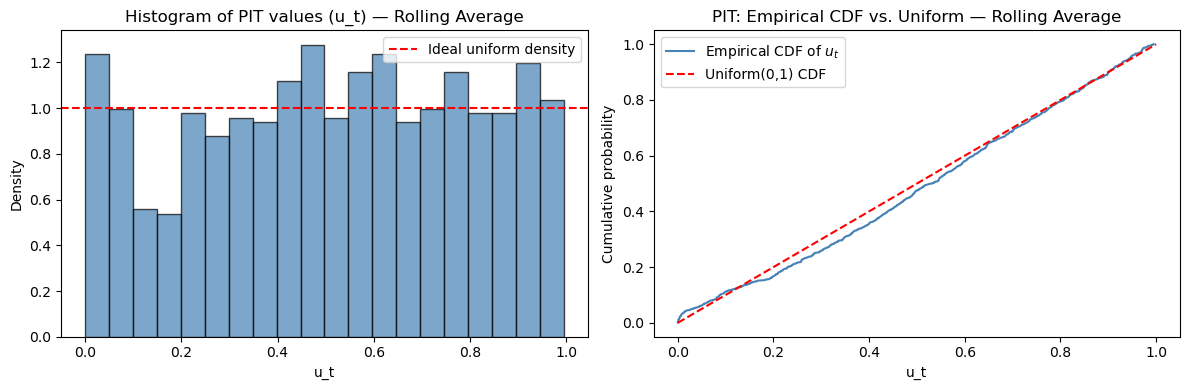

In [19]:
forecast_regression_rolling_pit, returns_regression_rolling, dates_regression_rolling_pit = align_series(
    rolling_regression, regression_returns
)

u_t_regression_rolling, ks_stat_regression_rolling, p_value_regression_rolling = compute_pit(
    returns_regression_rolling, forecast_regression_rolling_pit,
    mu=returns_regression_rolling.mean(), dist='normal'
)

print_pit_result(ks_stat_regression_rolling, p_value_regression_rolling, label="Rolling Average")
plot_pit(u_t_regression_rolling, label="Rolling Average")

The model is not well-calibrated for volatility.

In [20]:
def compute_z(u, dates):
    '''Transform u_t to z_t = Phi^{-1}(u_t) as a date-indexed Series, dropping non-finite values.'''
    z_raw = pd.Series(scipy_stats.norm.ppf(u), index=dates)
    return z_raw[np.isfinite(z_raw)]


def ljung_box_tests(z, lags=[1, 5, 10]):
    '''Run Ljung-Box on z_t (level) and z_t^2 (squared).'''
    lb_level = acorr_ljungbox(z, lags=lags, return_df=True)
    lb_sq    = acorr_ljungbox(z**2, lags=lags, return_df=True)
    return lb_level, lb_sq


def print_ljung_box(lb_level, lb_sq, label=""):
    print(f"Ljung-Box test on z_t (level) — {label}:")
    print(lb_level)
    print(f"\nLjung-Box test on z_t^2 (squared, ARCH-LM style) — {label}:")
    print(lb_sq)


def plot_acf_diagnostics(z, lags=20, label=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(z, lags=lags, ax=axes[0])
    axes[0].set_title(f"ACF of $z_t$ (level) — {label}")
    plot_acf(z**2, lags=lags, ax=axes[1])
    axes[1].set_title(f"ACF of $z_t^2$ (squared) — {label}")
    plt.tight_layout()
    plt.show()


def sign_bias_test(z, returns, dates):
    '''Engle-Ng sign-bias test: regress z_t^2 on sign(r_{t-1}), aligned strictly by date.'''
    returns_series = pd.Series(returns, index=dates)
    z_sq = z**2
    sign_lag = np.sign(returns_series).shift(1)

    aligned = pd.concat([z_sq, sign_lag], axis=1, join='inner').dropna()
    aligned.columns = ['z_sq', 'sign_lag']

    X = sm.add_constant(aligned['sign_lag'])
    model = sm.OLS(aligned['z_sq'], X).fit(cov_type='HC3')
    return model


def print_sign_bias(model, label=""):
    print(f"Engle-Ng Sign-Bias Test — {label}:")
    print(model.summary())

Ljung-Box test on z_t (level) — Rolling Average:
      lb_stat  lb_pvalue
1    0.635062   0.425505
5    1.460047   0.917634
10  12.684254   0.241865

Ljung-Box test on z_t^2 (squared, ARCH-LM style) — Rolling Average:
       lb_stat     lb_pvalue
1    29.617742  5.262108e-08
5    96.387411  3.048138e-19
10  105.752166  3.823852e-18


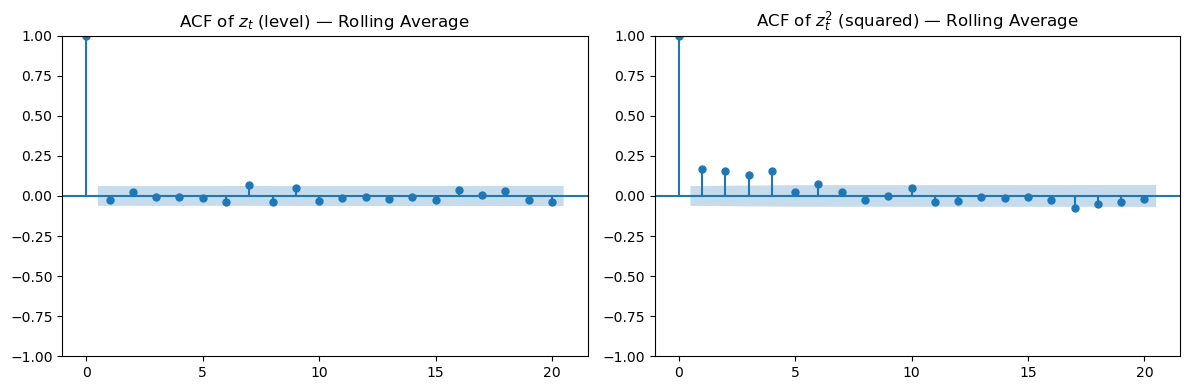

Engle-Ng Sign-Bias Test — Rolling Average:
                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     20.18
Date:                Fri, 07 Aug 2026   Prob (F-statistic):           7.88e-06
Time:                        20:42:49   Log-Likelihood:                -2002.3
No. Observations:                1007   AIC:                             4009.
Df Residuals:                    1005   BIC:                             4018.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const    

In [21]:
z_t_regression_rolling = compute_z(u_t_regression_rolling, dates_regression_rolling_pit)

lb_level_regression_rolling, lb_sq_regression_rolling = ljung_box_tests(z_t_regression_rolling)
print_ljung_box(lb_level_regression_rolling, lb_sq_regression_rolling, label="Rolling Average")
plot_acf_diagnostics(z_t_regression_rolling, label="Rolling Average")

sign_bias_model_regression_rolling = sign_bias_test(z_t_regression_rolling, returns_regression_rolling, dates_regression_rolling_pit)
print_sign_bias(sign_bias_model_regression_rolling, label="Rolling Average")

Test 1 (level): p-values well above 0.05 at all lags → fail to reject the null of no autocorrelation. No evidence that calibration errors have directional persistence (errors don't systematically run in one direction from day to day).

Test 2 (squared): p-values far below 0.05 at all lags → reject the null of no autocorrelation. Strong evidence of leftover volatility clustering — the model's errors bunch up in time, consistent with the rolling average failing to adapt quickly enough to genuine regime shifts.

Test 3 (sign bias): coefficient on sign(r_{t-1}) is significant (p<0.001, coefficient=-0.26) → reject the null of no sign-dependence. Calibration errors are meaningfully larger following negative returns than positive ones, indicating the rolling average fails to capture the leverage effect.

Therefore, the baseline model didn't work well for volatility modelling on the regression. 
Therefore, the baseline model shouldn't work on sequential but this should still be checked to understand the differences in the data between sequential and regression periods 

## Sequential Rolling

For sequential need the windows, need timestamps for the 8 regions each in 8 6 month periods from 2022 to 2025

Then for plotting hv coverage, need a new function for sequential with the window lines similar to the COVID lines (everything else unchanged)

Additionally QLIKe by window. 
Maybe also the Return Coverage at 90% for that period, (replacing the COVID breakdown)

In [22]:
# ── Window boundaries ────────────────────────────────────────────
window_boundaries = pd.date_range(start="2022-01-01", end="2026-01-01", freq="6MS")


In [23]:
# ── 19. QLIKE by window, using the already-consolidated period functions ──
qlike_windows_rolling = metric_by_period(
    forecast_sequential_rolling, actual_sequential_rolling, dates_sequential_rolling, window_boundaries, qlike
)

In [24]:
# ── 20. Print QLIKE by window ──
def print_metric_by_window(results, label="", metric_name="Metric"):
    print(f"{metric_name} by window — {label}:")
    for name, r in results.items():
        print(f"  {name} ({pd.Timestamp(r['start']).date()} to {pd.Timestamp(r['end']).date()}): {r['value']:.4f}")

print_metric_by_window(qlike_windows_rolling, label="Rolling Average", metric_name="QLIKE")

QLIKE by window — Rolling Average:
  period_1 (2022-01-01 to 2022-07-01): 0.2578
  period_2 (2022-07-01 to 2023-01-01): 0.1093
  period_3 (2023-01-01 to 2023-07-01): 0.0842
  period_4 (2023-07-01 to 2024-01-01): 0.1296
  period_5 (2024-01-01 to 2024-07-01): 0.1702
  period_6 (2024-07-01 to 2025-01-01): 0.9491
  period_7 (2025-01-01 to 2025-07-01): 1.0283
  period_8 (2025-07-01 to 2026-01-01): 0.4464


In [25]:
# ── 21. Expanding sigma_eta, per window (genuinely new — no equivalent in period_indices/metric_by_period) ──
def sigma_eta_sequential(forecast, actual, forecast_regression, actual_regression, dates, window_boundaries):
    '''Expanding sigma_eta: starts with regression residuals, accumulates each completed sequential window.'''
    all_log_resid = list(np.log(actual_regression) - np.log(forecast_regression))
    log_resid_sequential = np.log(actual) - np.log(forecast)

    sigma_eta_by_window = {}
    for i, (start_idx, end_idx) in enumerate(period_indices(dates, window_boundaries)):
        sigma_eta_by_window[f"window_{i+1}"] = np.std(all_log_resid)
        all_log_resid.extend(log_resid_sequential[start_idx:end_idx])

    return sigma_eta_by_window

In [26]:
# ── 22. Usage ──
sigma_eta_windows_rolling = sigma_eta_sequential(
    forecast_sequential_rolling, actual_sequential_rolling,
    forecast_regression_rolling, actual_regression_rolling,
    dates_sequential_rolling, window_boundaries
)

In [27]:
# ── 23. RV coverage using a different (expanding) sigma_eta per window ──
def hv_coverage_sequential(forecast, actual, dates, window_boundaries, sigma_eta_by_window, level=90):
    '''RV coverage using a different (expanding) sigma_eta per window.'''
    z = scipy_stats.norm.ppf(1 - (100 - level) / 200)
    lower = np.zeros_like(forecast)
    upper = np.zeros_like(forecast)

    for i, (start_idx, end_idx) in enumerate(period_indices(dates, window_boundaries)):
        sigma_eta_i = sigma_eta_by_window[f"window_{i+1}"]
        lower[start_idx:end_idx] = forecast[start_idx:end_idx] * np.exp(-z * sigma_eta_i)
        upper[start_idx:end_idx] = forecast[start_idx:end_idx] * np.exp(+z * sigma_eta_i)

    inside = (actual >= lower) & (actual <= upper)
    return lower, upper, inside

In [28]:
# ── 24. Usage ──
lower_seq_rolling, upper_seq_rolling, inside_seq_rolling = hv_coverage_sequential(
    forecast_sequential_rolling, actual_sequential_rolling, dates_sequential_rolling,
    window_boundaries, sigma_eta_windows_rolling, level=90
)

In [29]:
# ── 25. Coverage % by window, using the already-consolidated mask_by_period ──
coverage_windows_rolling = mask_by_period(inside_seq_rolling, dates_sequential_rolling, window_boundaries)

In [30]:
# ── 26. Print coverage by window ──
def print_coverage_by_window(results, label="", level=90):
    print(f"{level}% CI Coverage by window — {label}:")
    for name, r in results.items():
        print(f"  {name} ({pd.Timestamp(r['start']).date()} to {pd.Timestamp(r['end']).date()}): {r['value']:.2%}")

print_coverage_by_window(coverage_windows_rolling, label="Rolling Average", level=90)

90% CI Coverage by window — Rolling Average:
  period_1 (2022-01-01 to 2022-07-01): 100.00%
  period_2 (2022-07-01 to 2023-01-01): 100.00%
  period_3 (2023-01-01 to 2023-07-01): 100.00%
  period_4 (2023-07-01 to 2024-01-01): 98.41%
  period_5 (2024-01-01 to 2024-07-01): 100.00%
  period_6 (2024-07-01 to 2025-01-01): 86.72%
  period_7 (2025-01-01 to 2025-07-01): 69.67%
  period_8 (2025-07-01 to 2026-01-01): 94.34%


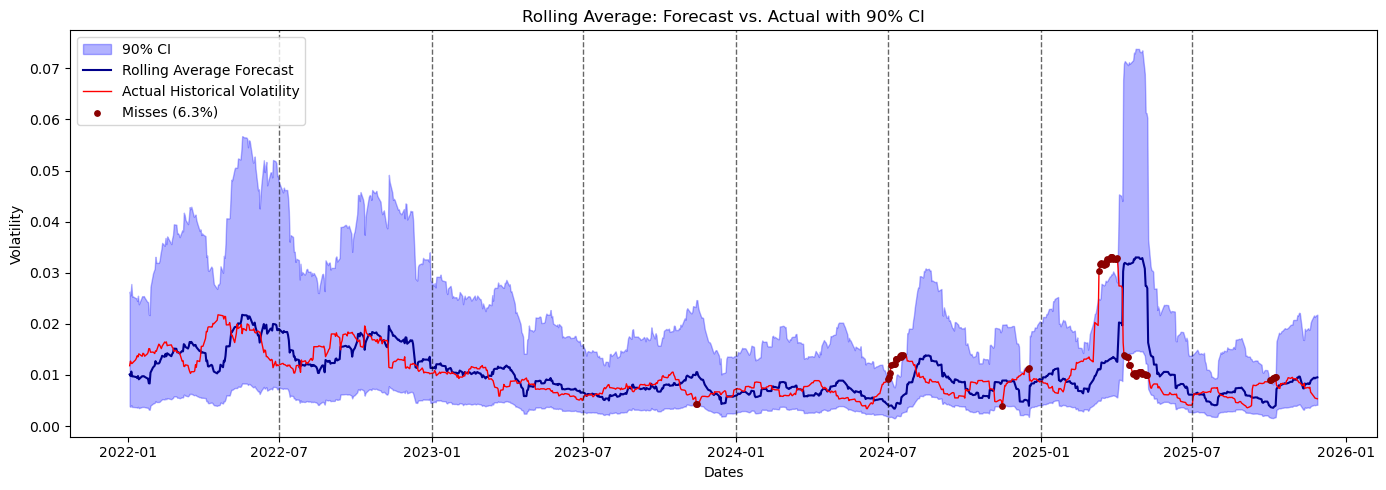

In [31]:
# windows
plot_hv_coverage(
    forecast_sequential_rolling, actual_sequential_rolling, dates_sequential_rolling,
    lower_seq_rolling, upper_seq_rolling, inside_seq_rolling,
    level=90, label="Rolling Average",
    boundary_dates=window_boundaries,
    boundary_labels=[None]*len(window_boundaries),
    boundary_styles=['--']*len(window_boundaries)
)

PIT 

Rolling Average (Sequential) — KS statistic: 0.0415
Rolling Average (Sequential) — p-value: 0.0619
Rolling Average (Sequential) — Fail to reject null: no evidence of miscalibration


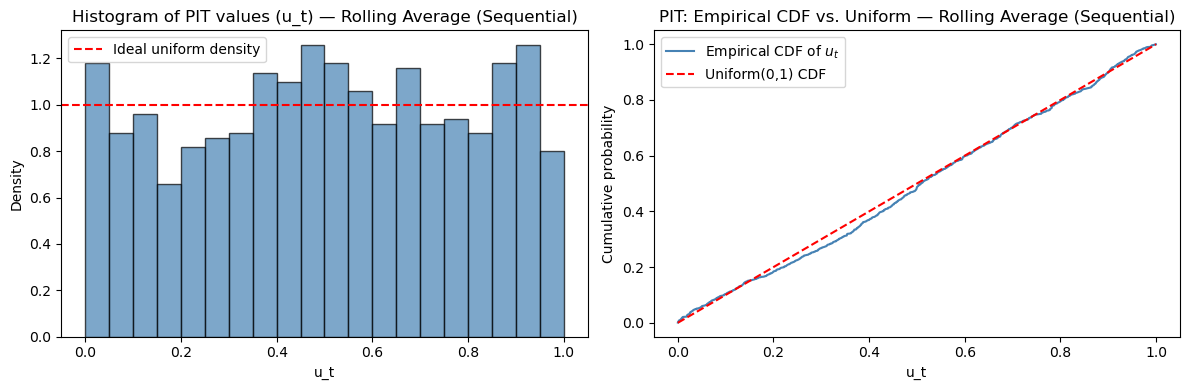

In [32]:
forecast_sequential_rolling_pit, returns_sequential_rolling, dates_sequential_rolling_pit = align_series(
    rolling_sequential, sequential_returns
)
u_t_sequential_rolling, ks_stat_sequential_rolling, p_value_sequential_rolling = compute_pit(
    returns_sequential_rolling, forecast_sequential_rolling_pit,
    mu=returns_sequential_rolling.mean(), dist='normal'
)
print_pit_result(ks_stat_sequential_rolling, p_value_sequential_rolling, label="Rolling Average (Sequential)")
plot_pit(u_t_sequential_rolling, label="Rolling Average (Sequential)")

Serial Dependence

Ljung-Box test on z_t (level) — Rolling Average (Sequential):
     lb_stat  lb_pvalue
1   0.003540   0.952552
5   1.335001   0.931289
10  1.916597   0.996940

Ljung-Box test on z_t^2 (squared, ARCH-LM style) — Rolling Average (Sequential):
      lb_stat  lb_pvalue
1    2.040097   0.153200
5   14.780696   0.011342
10  17.631161   0.061513


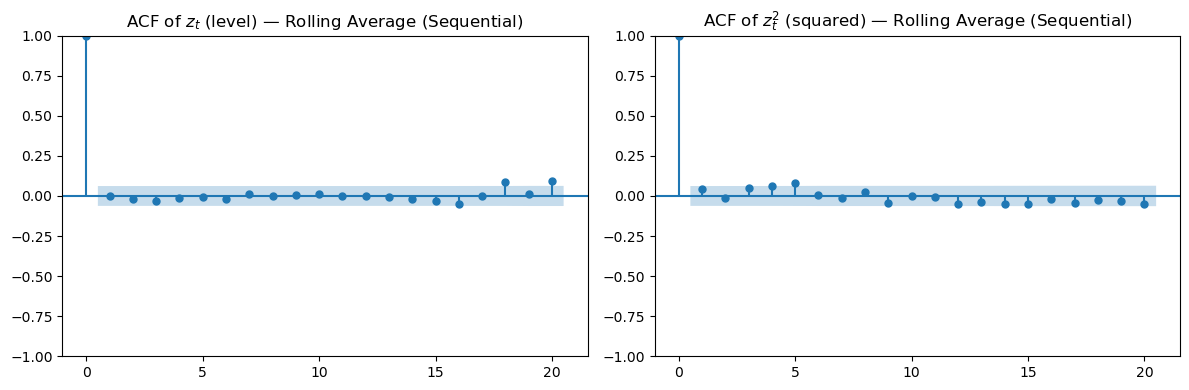

Engle-Ng Sign-Bias Test — Rolling Average (Sequential):
                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     7.677
Date:                Fri, 07 Aug 2026   Prob (F-statistic):            0.00570
Time:                        20:42:50   Log-Likelihood:                -1853.9
No. Observations:                1001   AIC:                             3712.
Df Residuals:                     999   BIC:                             3722.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [33]:
z_t_sequential_rolling = compute_z(u_t_sequential_rolling, dates_sequential_rolling_pit)
lb_level_seq_rolling, lb_sq_seq_rolling = ljung_box_tests(z_t_sequential_rolling)
print_ljung_box(lb_level_seq_rolling, lb_sq_seq_rolling, label="Rolling Average (Sequential)")
plot_acf_diagnostics(z_t_sequential_rolling, label="Rolling Average (Sequential)")

sign_bias_model_seq_rolling = sign_bias_test(z_t_sequential_rolling, returns_sequential_rolling, dates_sequential_rolling_pit)
print_sign_bias(sign_bias_model_seq_rolling, label="Rolling Average (Sequential)")

## Model 2- Time Series

### Model Selection

Note that all the model selection code should be done using the prior returns. 

In order to select the models, AIC and BIC are used where these are given by:

AIC = -2loglikelihood+2k
BIC = -2loglikelihood + kln(n)

In [34]:
import pandas as pd
import numpy as np
from scipy import stats
from arch import arch_model
# GARCH
garch_mle = arch_model(prior_returns * 100, vol="Garch", p=1, q=1,mean="Constant",dist="t")
result_garch = garch_mle.fit(disp="off")


#GJR GARCH
# EGARCH
egarch_mle = arch_model(prior_returns * 100, vol="EGARCH", p=1, o=1, q=1,mean="Constant",dist="t")
result_egarch = egarch_mle.fit(disp="off")
gjr_garch_mle = arch_model(prior_returns*100, vol='Garch',p=1,o=1,q=1,mean="Constant",dist="t")
result_gjr_garch = gjr_garch_mle.fit(disp='off')

garch_2_1_mle = arch_model(prior_returns * 100,vol="Garch", p=2, q=1,mean="Constant",dist="t")
result_garch_2_1 = garch_2_1_mle.fit(disp="off")

garch_1_2_mle = arch_model(prior_returns*100, vol="Garch", p=1, q=2, mean="Constant", dist="t")
result_garch_1_2 = garch_1_2_mle.fit(disp="off")



From the table below, EGARCH-t has minimal AIC and BIC so it is the best time series model for this task.

In [35]:
import pandas as pd

model_selection = pd.DataFrame({
    "Model": ["GARCH(1,1)-t", "EGARCH(1,1)-t", "GJR-GARCH(1,1)-t", "GARCH(2,1)-t","GARCH(1,2)-t"],
    "AIC":   [result_garch.aic, result_egarch.aic, result_gjr_garch.aic, result_garch_2_1.aic, result_garch_1_2.aic],
    "BIC":   [result_garch.bic, result_egarch.bic, result_gjr_garch.bic, result_garch_2_1.bic, result_garch_1_2.bic],
    "Log-Likelihood": [result_garch.loglikelihood, result_egarch.loglikelihood, result_gjr_garch.loglikelihood, result_garch_2_1.loglikelihood, result_garch_1_2.loglikelihood]
})

model_selection = model_selection.set_index("Model")
print(model_selection.round(2))

                      AIC      BIC  Log-Likelihood
Model                                             
GARCH(1,1)-t      2492.97  2518.66        -1241.49
EGARCH(1,1)-t     2422.57  2453.40        -1205.29
GJR-GARCH(1,1)-t  2443.79  2474.62        -1215.90
GARCH(2,1)-t      2494.87  2525.70        -1241.44
GARCH(1,2)-t      2494.97  2525.80        -1241.49


### EGARCH

The EGARCH(1,1)-t model is parameterized by:

\begin{align}
r_t &= \mu + \epsilon_t, \quad \epsilon_t = \sigma_t z_t, \quad z_t \overset{\text{i.i.d.}}{\sim} t_\nu(0,1) \\
\ln\sigma_t^2 &= \omega + \alpha\left(|z_{t-1}| - \mathbb{E}|z_{t-1}|\right) + \gamma z_{t-1} + \beta\ln\sigma_{t-1}^2
\end{align}

Its key differentiator over other time series models is its ability to capture the leverage effect (the principle that volatility reacts asymmetrically to equal changes in positive and negative returns) through $\gamma$.

It also captures other key properties of volatility (the t-distribution captures fat-tailedness of returns and $\alpha$ captures the effect of sudden large changes in price).

From the summary below, potential parameters for priors can be determined

In [36]:
print(result_egarch.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                          SPY   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -1205.29
Distribution:      Standardized Student's t   AIC:                           2422.57
Method:                  Maximum Likelihood   BIC:                           2453.40
                                              No. Observations:                 1258
Date:                      Fri, Aug 07 2026   Df Residuals:                     1257
Time:                              20:42:51   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

In [37]:
prior_std = prior_returns_1d.std()
print(f"prior_std: {prior_std:.6f}")

prior_std: 0.007444


In [38]:
import scipy.special

# ── Fix: log-space E_abs_z_t to avoid gamma-function overflow ──
def E_abs_z_t(nu):
    """E[|z|] for standardized t with unit variance — log-space to avoid overflow for large nu."""
    log_num = np.log(2) + 0.5*np.log(nu-2) + scipy.special.gammaln((nu+1)/2)
    log_den = 0.5*np.log(np.pi) + np.log(nu-1) + scipy.special.gammaln(nu/2)
    return np.exp(log_num - log_den)

nu_grid = np.linspace(2.1,100, 1000)
e_abs_grid = E_abs_z_t(nu_grid)

def E_abs_z_interp_numpy(nu, nu_grid=nu_grid, e_abs_grid=e_abs_grid):
    '''NumPy equivalent of the JAX E_abs_z_interp used inside egarch_model — safe for any nu.'''
    return np.interp(nu, nu_grid, e_abs_grid)

def simulate_egarch_t_vectorized(omega, alpha, beta, gamma, nu, mu, n, ls2_init=None):
    '''Simulate n days for a batch of S parameter draws (all arrays of length S).
    ls2_init: optional per-draw starting state (array of length S). If None, uses the
    stationary initial condition omega/(1-beta) — used for prior predictive checking.
    If provided (e.g. carried-forward state), used for sequential forecast generation.
    Returns (r, sigma), each of shape (S, n), with r[:,t] and sigma[:,t] both belonging
    to the same model day t (sigma[:,t] is the sigma that generated r[:,t]).'''
    S = len(omega)
    log_sigma2 = np.zeros((S, n))
    r = np.zeros((S, n))
    e_abs = E_abs_z_interp_numpy(nu)
    scale = np.sqrt((nu - 2) / nu)

    if ls2_init is None:
        ls2 = np.clip(omega / (1 - beta), -20, 2)
    else:
        ls2 = np.clip(ls2_init, -20, 2)

    for t in range(n):
        log_sigma2[:, t] = ls2
        z = np.random.standard_t(nu) * scale
        r[:, t] = mu + np.exp(0.5 * ls2) * z
        if t < n - 1:
            ls2 = np.clip(omega + beta * ls2 + gamma * z + alpha * (np.abs(z) - e_abs), -20, 2)
    return r, np.sqrt(np.exp(log_sigma2))

def sigma_to_hv_correct(sigma_paths, h=21):
    '''Correct order: average sigma^2 ACROSS PATHS first (per timestep), then RMS-aggregate over the window.'''
    mean_sigma_sq_per_t = np.mean(sigma_paths**2, axis=0)   # E[sigma_{t+i}^2] at each t, across paths
    rv = pd.Series(mean_sigma_sq_per_t).rolling(h).mean().shift(-h+1)  # window average, forward-looking
    return np.sqrt(rv).values

def sigma_sq_windowed_per_path(sigma_paths, h=21):
    '''Per-path windowed mean of sigma^2 (no sqrt), for percentile-band purposes.'''
    result = np.zeros((sigma_paths.shape[0], sigma_paths.shape[1]))
    for n_idx in range(sigma_paths.shape[0]):
        result[n_idx] = pd.Series(sigma_paths[n_idx]**2).rolling(h).mean().shift(-h+1).values
    return result


In [39]:
from scipy import stats as scipy_stats
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm

egarch_prior_params = {
    "beta_ab": (47, 3),
    "alpha_scale": 0.05,
    "gamma_scale": 0.05,
    "mu_scale": 0.001,
    "uncond_vol_scale": 0.003,
    "nu_gamma_scale": 2,
}

omega_egarch = result_egarch.params['omega']
alpha_egarch = result_egarch.params['alpha[1]']  # magnitude
gamma_egarch = result_egarch.params['gamma[1]']  # leverage
beta_egarch  = result_egarch.params['beta[1]']
nu_egarch    = result_egarch.params['nu']
mu_egarch    = result_egarch.params['mu'] / 100  # divide by 100
prior_std    = prior_returns_1d.std()

In [40]:
def prior_predictive_simulate_egarch(
    prior_returns_1d, omega_egarch, alpha_egarch, gamma_egarch, beta_egarch, nu_egarch, mu_egarch, prior_std,
    prior_params=egarch_prior_params,
    n_paths=1000, seed=42
):
    '''EGARCH-specific: sample parameters from priors, reject invalid draws, simulate forward.
    prior_params: dict of prior hyperparameters — pass explicitly so this matches egarch_model's own prior exactly.
    Returns (vol_paths, ret_paths, valid_paths).'''
    np.random.seed(seed)
    n = len(prior_returns_1d)

    alpha_arr = scipy_stats.truncnorm.rvs(
        (0 - alpha_egarch) / prior_params["alpha_scale"], np.inf,
        loc=alpha_egarch, scale=prior_params["alpha_scale"], size=n_paths
    )
    beta_arr  = np.random.beta(*prior_params["beta_ab"], size=n_paths)
    gamma_arr = np.random.normal(gamma_egarch, prior_params["gamma_scale"], size=n_paths)
    mu_arr    = np.random.normal(mu_egarch, prior_params["mu_scale"], size=n_paths)
    nu_arr    = 2.1 + np.random.gamma(shape=(nu_egarch - 2.1) / 2, scale=prior_params["nu_gamma_scale"], size=n_paths)
    uncond_vol_arr = scipy_stats.truncnorm.rvs(
        (0 - prior_std) / prior_params["uncond_vol_scale"], (0.02 - prior_std) / prior_params["uncond_vol_scale"],
        loc=prior_std, scale=prior_params["uncond_vol_scale"], size=n_paths
    )
    omega_arr = np.log(uncond_vol_arr**2) * (1 - beta_arr)

    valid_mask = np.array([np.isfinite(E_abs_z_t(nu_i)) for nu_i in nu_arr]) & (np.abs(beta_arr) < 1)
    alpha_v, beta_v, gamma_v, mu_v, nu_v, omega_v = (
        alpha_arr[valid_mask], beta_arr[valid_mask], gamma_arr[valid_mask],
        mu_arr[valid_mask], nu_arr[valid_mask], omega_arr[valid_mask]
    )

    ret_paths, vol_paths = simulate_egarch_t_vectorized(omega_v, alpha_v, beta_v, gamma_v, nu_v, mu_v, n)

    explosive_mask = (np.any(np.isnan(ret_paths), axis=1) | np.any(np.isinf(ret_paths), axis=1) |
                       (np.max(np.abs(ret_paths), axis=1) > 0.5))
    vol_paths = vol_paths[~explosive_mask]
    ret_paths = ret_paths[~explosive_mask]
    valid_paths = vol_paths.shape[0]

    print(f"Valid paths: {valid_paths}/{n_paths} ({valid_paths/n_paths*100:.0f}%)")
    return vol_paths, ret_paths, valid_paths

In [41]:
import warnings
def prior_predictive_check(vol_paths, ret_paths, valid_paths, prior_returns_1d, prior_dates, hv_prior,
                           
                            model_label="Model", color="blue", n_paths=1000, save_path=None):
    '''Model-agnostic: aggregate (Method 2 mean, per-path band), align, and plot.
    Works for any model's vol_paths/ret_paths (EGARCH, SV, ...).
    color: base color for the plotted band/mean/simulated lines (e.g. "blue" for EGARCH, "green" for SV).'''
    save_path = save_path or f"{model_label.lower()}_prior_predictive.pdf"
    dark_color = f"dark{color}"

    # ── Aggregate: mean (Method 2) and band (per-path, then percentile) ──
    mean_correct = sigma_to_hv_correct(vol_paths, h=21)
    sigma_sq_windowed = sigma_sq_windowed_per_path(vol_paths, h=21)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="All-NaN slice encountered")
        lower = np.sqrt(np.nanpercentile(sigma_sq_windowed, 5, axis=0))
        upper = np.sqrt(np.nanpercentile(sigma_sq_windowed, 95, axis=0))

    # ── Build date-indexed series, align ──
    mean_correct_series = pd.Series(mean_correct, index=prior_dates[:len(mean_correct)]).dropna()
    lower_series = pd.Series(lower, index=prior_dates[:len(lower)]).dropna()
    upper_series = pd.Series(upper, index=prior_dates[:len(upper)]).dropna()

    forecast_prior, actual_prior, dates_prior = align_series(mean_correct_series, hv_prior)
    lower_aligned = lower_series.reindex(dates_prior).values
    upper_aligned = upper_series.reindex(dates_prior).values

    inside_prior = (actual_prior >= lower_aligned) & (actual_prior <= upper_aligned)
    miss_pct_prior = (1 - np.mean(inside_prior)) * 100

    # ── Plot ──
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    axes[0].fill_between(dates_prior, lower_aligned, upper_aligned,
                          alpha=0.2, color=color, label="5th-95th percentile (per-path, sqrt applied last)")
    axes[0].plot(dates_prior, forecast_prior, color=dark_color,
                 linewidth=1.5, label="E[HV] across paths (correct order)")
    axes[0].plot(dates_prior, actual_prior, color="red",
                 linewidth=1.5, label="Actual Historical Volatility")
    miss_idx = np.where(~inside_prior)[0]
    axes[0].scatter(dates_prior[miss_idx], actual_prior[miss_idx],
                     color='darkred', s=15, zorder=5, label=f'Misses ({miss_pct_prior:.1f}%)')
    axes[0].set_title(f"{model_label} Prior Predictive Check Volatility: ({valid_paths}/{n_paths} accepted paths)")
    axes[0].set_ylabel("Historical Volatility"); axes[0].set_xlabel("Date"); axes[0].legend()

    ret_lower = np.percentile(ret_paths, 5, axis=0)
    ret_upper = np.percentile(ret_paths, 95, axis=0)
    ret_mean  = np.mean(ret_paths, axis=0)
    axes[1].fill_between(prior_dates, ret_lower, ret_upper, alpha=0.2, color=color, label="5th-95th percentile")
    axes[1].plot(prior_dates, ret_mean, color=dark_color, linewidth=1.5, label="Simulated Prior Mean")
    axes[1].plot(prior_dates, prior_returns_1d, color="red", linewidth=1.5, label="Actual log returns")
    axes[1].set_title("Log Returns"); axes[1].set_ylabel("Log Returns"); axes[1].set_xlabel("Date"); axes[1].legend()

    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print(f"Miss rate (visual diagnostic only): {miss_pct_prior:.1f}%")
    print("Rejection rate indicates prior stationarity constraint tightness")

    return {
        "forecast": forecast_prior, "actual": actual_prior, "dates": dates_prior,
        "lower": lower_aligned, "upper": upper_aligned, "miss_pct": miss_pct_prior,
    }

In [42]:
def prior_predictive_simulate_egarch(
    prior_returns_1d, omega_egarch, alpha_egarch, gamma_egarch, beta_egarch, nu_egarch, mu_egarch, prior_std,
    prior_params=egarch_prior_params,
    n_paths=1000, seed=42
):
    '''EGARCH-specific: sample parameters from priors, reject invalid draws, simulate forward.
    prior_params: dict of prior hyperparameters — pass explicitly so this matches egarch_model's own prior exactly.
    Returns (vol_paths, ret_paths, valid_paths).'''
    np.random.seed(seed)
    n = len(prior_returns_1d)

    alpha_arr = scipy_stats.truncnorm.rvs(
        (0 - alpha_egarch) / prior_params["alpha_scale"], np.inf,
        loc=alpha_egarch, scale=prior_params["alpha_scale"], size=n_paths
    )
    beta_arr  = np.random.beta(*prior_params["beta_ab"], size=n_paths)
    gamma_arr = np.random.normal(gamma_egarch, prior_params["gamma_scale"], size=n_paths)
    mu_arr    = np.random.normal(mu_egarch, prior_params["mu_scale"], size=n_paths)
    nu_arr    = 2.1 + np.random.gamma(shape=(nu_egarch - 2.1) / 2, scale=prior_params["nu_gamma_scale"], size=n_paths)
    uncond_vol_arr = scipy_stats.truncnorm.rvs(
        (0 - prior_std) / prior_params["uncond_vol_scale"], (0.02 - prior_std) / prior_params["uncond_vol_scale"],
        loc=prior_std, scale=prior_params["uncond_vol_scale"], size=n_paths
    )
    omega_arr = np.log(uncond_vol_arr**2) * (1 - beta_arr)

    valid_mask = np.array([np.isfinite(E_abs_z_t(nu_i)) for nu_i in nu_arr]) & (np.abs(beta_arr) < 1)
    alpha_v, beta_v, gamma_v, mu_v, nu_v, omega_v = (
        alpha_arr[valid_mask], beta_arr[valid_mask], gamma_arr[valid_mask],
        mu_arr[valid_mask], nu_arr[valid_mask], omega_arr[valid_mask]
    )

    ret_paths, vol_paths = simulate_egarch_t_vectorized(omega_v, alpha_v, beta_v, gamma_v, nu_v, mu_v, n)

    explosive_mask = (np.any(np.isnan(ret_paths), axis=1) | np.any(np.isinf(ret_paths), axis=1) |
                       (np.max(np.abs(ret_paths), axis=1) > 0.5))
    vol_paths = vol_paths[~explosive_mask]
    ret_paths = ret_paths[~explosive_mask]
    valid_paths = vol_paths.shape[0]

    print(f"Valid paths: {valid_paths}/{n_paths} ({valid_paths/n_paths*100:.0f}%)")
    return vol_paths, ret_paths, valid_paths

Valid paths: 992/1000 (99%)


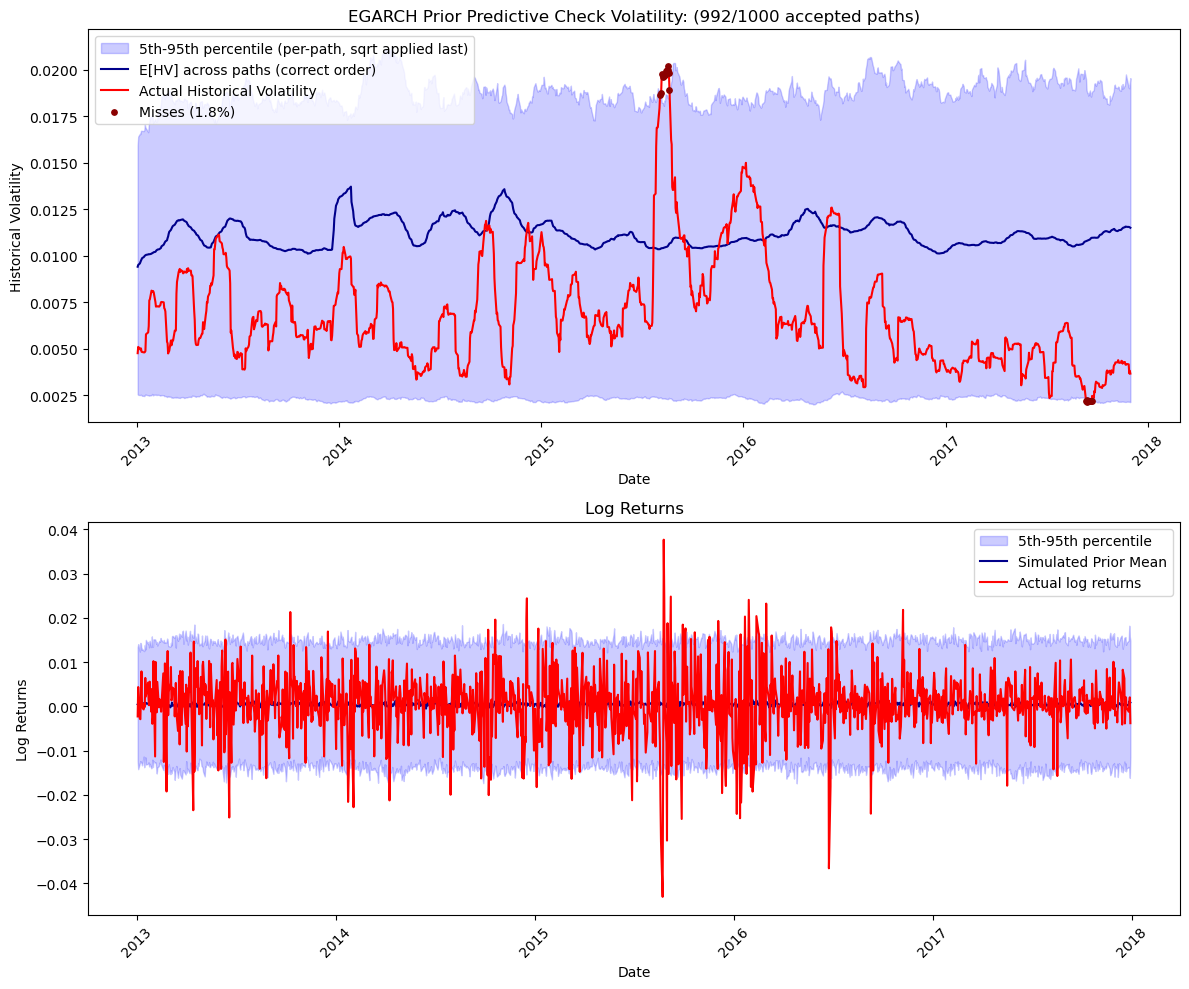

Miss rate (visual diagnostic only): 1.8%
Rejection rate indicates prior stationarity constraint tightness


In [43]:
vol_paths_egarch, ret_paths_egarch, valid_paths_egarch = prior_predictive_simulate_egarch(
    prior_returns_1d, omega_egarch, alpha_egarch, gamma_egarch, beta_egarch, nu_egarch, mu_egarch, prior_std
)
results_prior_egarch = prior_predictive_check(
    vol_paths_egarch, ret_paths_egarch, valid_paths_egarch, prior_returns_1d, prior_dates, hv_prior, model_label="EGARCH"
)

The plots above are sufficiently good, (even though the confidence intervals don't actually map much onto the actual rolling std, it covers it which is enough for the MCMC)

### Implementation

Use Numpyro for implementation of the MCMC method

In [44]:
pip install numpyro jax

Note: you may need to restart the kernel to use updated packages.


### Regression Code

In [45]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import jax
jax.config.update("jax_enable_x64", True)  # MUST be before any JAX operations
import jax.numpy as jnp
import numpyro
numpyro.set_host_device_count(4)
returns_jax = jnp.array(regression_returns_1d)  

def make_egarch_model(mu_egarch, alpha_egarch, beta_egarch, gamma_egarch, nu_egarch, prior_std, e_abs_grid):
    '''Returns a NumPyro model function, with all MLE-fit values closed over explicitly.'''
    e_abs_grid_t = jnp.array(e_abs_grid)

    def E_abs_z_interp(nu):
        idx      = (nu - 2.1) / (100 - 2.1) * 999
        idx_low  = jnp.clip(jnp.floor(idx).astype(int), 0, 998)
        idx_high = jnp.clip(idx_low + 1, 0, 999)
        frac     = idx - jnp.floor(idx)
        return e_abs_grid_t[idx_low] * (1-frac) + e_abs_grid_t[idx_high] * frac

    def egarch_model(returns):
        mu_ret     = numpyro.sample("mu_ret",     dist.Normal(mu_egarch, 0.001))
        alpha      = numpyro.sample("alpha",      dist.TruncatedNormal(alpha_egarch, 0.05, low=0))
        beta       = numpyro.sample("beta",       dist.Beta(47, 3))
        gamma      = numpyro.sample("gamma",      dist.Normal(gamma_egarch, 0.05))
        nu_shift   = numpyro.sample("nu_shift",   dist.Gamma((nu_egarch-2.1)/2, 0.5))
        nu         = nu_shift + 2.1
        uncond_vol = numpyro.sample("uncond_vol", dist.TruncatedNormal(prior_std, 0.003, low=0, high=0.02))
        omega      = jnp.log(uncond_vol**2) * (1 - beta_egarch)

        e_abs = E_abs_z_interp(nu)

        def egarch_step(ls2, r):
            z       = (r - mu_ret) / jnp.sqrt(jnp.exp(jnp.clip(ls2, -20.0, 2.0)))
            ls2_new = omega + beta*ls2 + gamma*z + alpha*(jnp.abs(z) - e_abs)
            return jnp.clip(ls2_new, -20.0, 2.0), ls2_new

        ls2_init = jnp.log(uncond_vol**2)
        # Scanning ALL T returns (not returns[:-1]) produces log_sigma2_shifted = [ls2_1,...,ls2_T] --
        # one step further than the likelihood needs, since T returns naturally imply T+1 states
        # (ls2_0 through ls2_T) but the likelihood only ever scores ls2_0..ls2_{T-1} against
        # returns[0..T-1]. log_sigma2_full (next line) reconstructs exactly that likelihood-facing
        # sequence -- prepend ls2_init as ls2_0, drop the extra ls2_T via [:-1] -- so the fit itself
        # is byte-for-byte unchanged from scanning returns[:-1]. The dropped element,
        # log_sigma2_shifted[-1] == ls2_T, is the true state AFTER this window's last return; it
        # never enters the likelihood, only reused below as ls2_next for carry-forward.
        _, log_sigma2_shifted = jax.lax.scan(egarch_step, ls2_init, returns)
        log_sigma2_full = jnp.concatenate([ls2_init.reshape(1), log_sigma2_shifted[:-1]])
        sigma = jnp.sqrt(jnp.exp(log_sigma2_full))
        scale = jnp.clip(sigma * jnp.sqrt((nu-2)/nu), 1e-6, 10)

        numpyro.sample("obs", dist.StudentT(nu, mu_ret, scale), obs=returns)
        numpyro.deterministic("sigma", sigma)
        numpyro.deterministic("ls2_next", log_sigma2_shifted[-1])

    return egarch_model

In [46]:
egarch_model = make_egarch_model(mu_egarch, alpha_egarch, beta_egarch, gamma_egarch, nu_egarch, prior_std, e_abs_grid)

nuts_kernel = NUTS(egarch_model, target_accept_prob=0.95)
mcmc_egarch = MCMC(nuts_kernel, num_warmup=2000, num_samples=2000, num_chains=4, chain_method='parallel')
mcmc_egarch.run(jax.random.PRNGKey(42), jnp.array(regression_returns_1d))
mcmc_egarch.print_summary()

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
       alpha      0.25      0.03      0.25      0.20      0.29   5949.61      1.00
        beta      0.94      0.00      0.94      0.93      0.95   3707.19      1.00
       gamma     -0.23      0.02     -0.23     -0.26     -0.19   5812.52      1.00
      mu_ret      0.00      0.00      0.00      0.00      0.00   8666.47      1.00
    nu_shift      3.92      0.96      3.80      2.39      5.38   5545.57      1.00
  uncond_vol      0.01      0.00      0.01      0.01      0.01   3583.22      1.00

Number of divergences: 0


Save data

In [47]:
import pickle
from pathlib import Path

Path("results/egarch").mkdir(parents=True, exist_ok=True)

samples_egarch = mcmc_egarch.get_samples()   # your existing line

with open("results/egarch/egarch_regression_mcmc.pkl", "wb") as f:
    pickle.dump({k: np.array(v) for k, v in samples_egarch.items()}, f)

print("Saved regression MCMC samples.")

Saved regression MCMC samples.


In [48]:
with open("results/egarch/egarch_regression_mcmc.pkl", "rb") as f:
    samples_egarch = pickle.load(f)

In [49]:
# ── Load/confirm the saved posterior samples ──
# samples_egarch = pickle.load(...) if reloading, or mcmc_egarch.get_samples() if freshly run
sigma_posterior_egarch = np.array(mcmc_egarch.get_samples()["sigma"])   # shape (S, T)
nu_all = np.array(mcmc_egarch.get_samples()["nu_shift"]) + 2.1          # nu_all defined here
mu_ret_all = np.array(mcmc_egarch.get_samples()["mu_ret"])              # per-draw mean, needed for PIT

In [50]:
def hv_per_draw_windowed(sigma_posterior, h=21):
    '''Per-draw windowed HV (sqrt applied), shape (S, T) — same as sigma_sq_windowed_per_path but with sqrt.'''
    return np.sqrt(sigma_sq_windowed_per_path(sigma_posterior, h=h))

def hv_coverage_posterior(hv_per_draw, actual, sigma_eta, level=90):
    '''Combined posterior-spread + log-normal noise interval, via simulation (Order A).'''
    S, T = hv_per_draw.shape
    noise = np.random.normal(0, sigma_eta, size=(S, T))
    noisy_hv = hv_per_draw * np.exp(noise)

    pct = (100 - level) / 2
    lower = np.percentile(noisy_hv, pct, axis=0)
    upper = np.percentile(noisy_hv, 100 - pct, axis=0)
    inside = (actual >= lower) & (actual <= upper)
    return lower, upper, inside

In [51]:
# Seeded for reproducibility -- covers hv_coverage_posterior's measurement-noise injection (EGARCH regression, 90% CI)
np.random.seed(42)

# ── QLIKE / RV Coverage: unchanged, Method 2 (posterior-averaged mean) ──
forecast_regression_egarch_series = pd.Series(
    sigma_to_hv_correct(sigma_posterior_egarch, h=21),
    index=regression_returns.index
).dropna()

forecast_regression_egarch, actual_regression_egarch, dates_regression_egarch = align_series(
    forecast_regression_egarch_series, hv_regression
)

ql_regression_egarch = qlike(forecast_regression_egarch, actual_regression_egarch)
print(f"QLIKE (EGARCH regression): mean = {ql_regression_egarch.mean():.4f}")

# ── RV Coverage: combined posterior spread + log-normal noise (Order A) ──
sigma_eta_egarch, _ = hv_coverage(forecast_regression_egarch, actual_regression_egarch)  # keep, just for sigma_eta

# Build per-draw windowed HV over the SAME dates as forecast_regression_egarch (i.e. aligned against hv_regression)
hv_per_draw_regression_egarch = hv_per_draw_windowed(sigma_posterior_egarch, h=21)  # shape (S, T_full)

# Align to match dates_regression_egarch (same dates as forecast_regression_egarch/actual_regression_egarch)
hv_per_draw_regression_egarch_df = pd.DataFrame(
    hv_per_draw_regression_egarch.T, index=regression_returns.index
).loc[dates_regression_egarch]
hv_per_draw_regression_egarch_aligned = hv_per_draw_regression_egarch_df.values.T  # (S, T_aligned)

lower_90_egarch, upper_90_egarch, inside_90_egarch = hv_coverage_posterior(
    hv_per_draw_regression_egarch_aligned, actual_regression_egarch, sigma_eta_egarch, level=90
)

coverage_90_egarch = np.mean(inside_90_egarch)
print(f"EGARCH — 90% CI coverage (posterior + noise): {coverage_90_egarch:.2%}")

QLIKE (EGARCH regression): mean = 0.0992
EGARCH — 90% CI coverage (posterior + noise): 85.43%


In [52]:
def hv_coverage_posterior_multilevel(hv_per_draw, actual, sigma_eta, levels=[50, 60, 70, 80, 85, 90, 95, 99]):
    '''Combined posterior-spread + log-normal noise coverage, at multiple CI levels — one shared noise draw.'''
    S, T = hv_per_draw.shape
    noise = np.random.normal(0, sigma_eta, size=(S, T))   # simulated once, reused for all levels
    noisy_hv = hv_per_draw * np.exp(noise)

    results = {}
    for level in levels:
        pct = (100 - level) / 2
        lower = np.percentile(noisy_hv, pct, axis=0)
        upper = np.percentile(noisy_hv, 100 - pct, axis=0)
        inside = (actual >= lower) & (actual <= upper)
        results[level] = np.mean(inside)
    return results


def print_hv_coverage_posterior(sigma_eta, results, label=""):
    print(f"{label} — Measurement noise std: {sigma_eta:.4f}")
    print("Coverage at different CI levels (posterior + noise):")
    print("-" * 40)
    for level, coverage in results.items():
        print(f"{level}% CI coverage: {coverage:.2%}")

In [162]:
# Seeded for reproducibility -- covers hv_coverage_posterior_multilevel's measurement-noise injection (EGARCH regression, multilevel CI)
np.random.seed(42)

hv_coverage_regression_egarch = hv_coverage_posterior_multilevel(
    hv_per_draw_regression_egarch_aligned, actual_regression_egarch, sigma_eta_egarch
)
print_hv_coverage_posterior(sigma_eta_egarch, hv_coverage_regression_egarch, label="EGARCH")

EGARCH — Measurement noise std: 0.2042
Coverage at different CI levels (posterior + noise):
----------------------------------------
50% CI coverage: 43.83%
60% CI coverage: 52.33%
70% CI coverage: 62.45%
80% CI coverage: 73.89%
85% CI coverage: 80.87%
90% CI coverage: 85.43%
95% CI coverage: 92.31%
99% CI coverage: 97.17%


EGARCH — Pre-COVID QLIKE:  0.1112
EGARCH — COVID QLIKE:      0.1622
EGARCH — Post-COVID QLIKE: 0.0739
At 90% CI coverage
EGARCH — Pre-COVID coverage:  80.65%
EGARCH — COVID coverage:      87.30%
EGARCH — Post-COVID coverage: 91.29%


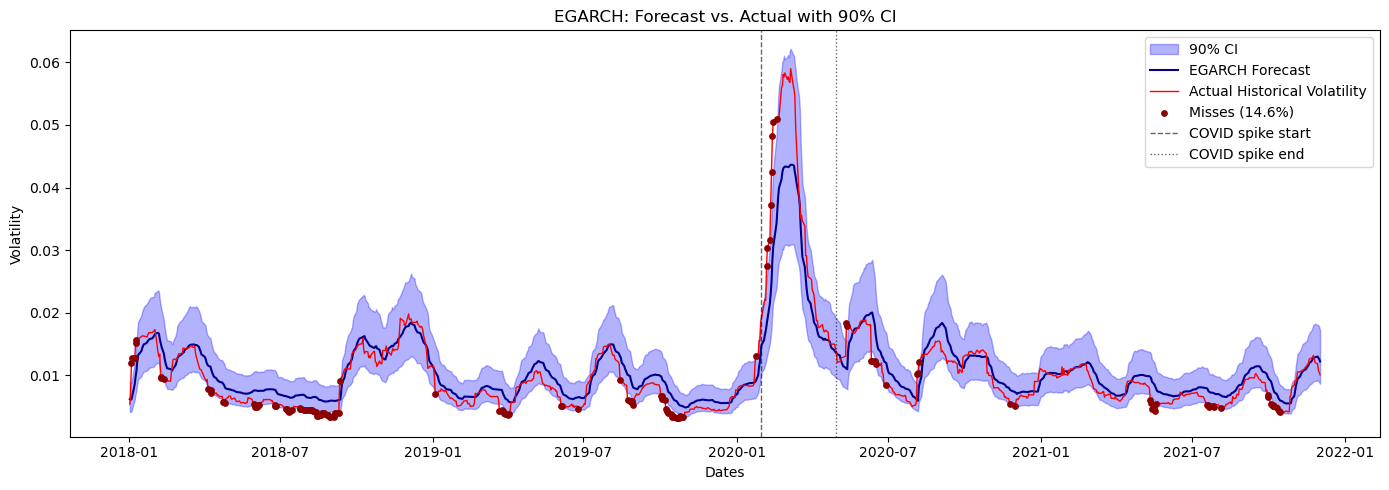

In [54]:
# ── QLIKE COVID breakdown ──
qlike_breakdown_egarch = covid_breakdown(
    forecast_regression_egarch, actual_regression_egarch, dates_regression_egarch,
    covid_start_date, covid_end_date, qlike
)
print_covid_breakdown(qlike_breakdown_egarch, label="EGARCH", metric_name="QLIKE")

# ── COVID sub-period breakdown — RV Coverage (90% CI) ──
covid_coverage_egarch = hv_coverage_covid_breakdown(
    inside_90_egarch, dates_regression_egarch, covid_start_date, covid_end_date
)
print_hv_coverage_covid(covid_coverage_egarch, label="EGARCH")

# ── Plot with COVID vlines ──
plot_hv_coverage(
    forecast_regression_egarch, actual_regression_egarch, dates_regression_egarch,
    lower_90_egarch, upper_90_egarch, inside_90_egarch,
    level=90, label="EGARCH",
    boundary_dates=[covid_start_date, covid_end_date],
    boundary_labels=['COVID spike start', 'COVID spike end'],
    boundary_styles=['--', ':']
)

In [55]:
# ── PIT alignment: sigma_posterior_egarch against returns (separate from HV alignment above) ──
sigma_posterior_egarch_df = pd.DataFrame(
    sigma_posterior_egarch.T,   # (T, S) — one row per date, one column per draw
    index=regression_returns.index
).dropna()

common_dates_pit = sigma_posterior_egarch_df.index.intersection(regression_returns.index)
sigma_posterior_egarch_pit = sigma_posterior_egarch_df.loc[common_dates_pit].values.T  # back to (S, T_common)
returns_regression_egarch_pit = regression_returns.loc[common_dates_pit].values.flatten()
dates_regression_egarch_pit = common_dates_pit

In [56]:
def compute_pit_posterior(returns, sigma_per_draw, mu_per_draw, dist='t', df=None):
    '''Method 1: compute u_t per posterior draw, then average across draws.
    sigma_per_draw: shape (S, T) — raw per-day sigma_t, one row per draw.
    mu_per_draw: shape (S,) — each draw's own fitted mean, subtracted before standardizing.
    df: for dist='t', shape (S,) — each draw's own degrees of freedom. The scale is corrected
    to sigma_per_draw[s] * sqrt((df[s]-2)/df[s]) to match the model's StudentT(df, mu, scale)
    observation (raw sigma_t is NOT the StudentT scale parameter).'''
    S, T = sigma_per_draw.shape
    u_per_draw = np.zeros((S, T))
    for s in range(S):
        if dist == 't':
            scale = sigma_per_draw[s] * np.sqrt((df[s] - 2) / df[s])
            u_per_draw[s] = scipy_stats.t.cdf(returns, df=df[s], loc=mu_per_draw[s], scale=scale)
        else:
            u_per_draw[s] = scipy_stats.norm.cdf(returns, loc=mu_per_draw[s], scale=sigma_per_draw[s])
    u_t = np.mean(u_per_draw, axis=0)   # average across draws — Method 1
    ks_stat, p_value = scipy_stats.kstest(u_t, 'uniform')
    return u_t, ks_stat, p_value

EGARCH (posterior-averaged PIT) — KS statistic: 0.0276
EGARCH (posterior-averaged PIT) — p-value: 0.4195
EGARCH (posterior-averaged PIT) — Fail to reject null: no evidence of miscalibration


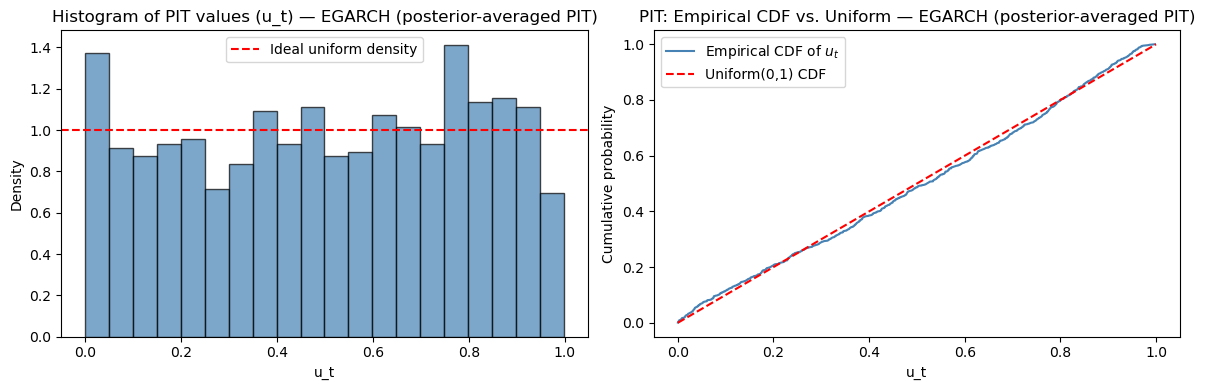

In [57]:
# ── Run PIT using Method 1 (posterior-averaged) ──
u_t_regression_egarch, ks_stat_regression_egarch, p_value_regression_egarch = compute_pit_posterior(
    returns_regression_egarch_pit, sigma_posterior_egarch_pit, mu_ret_all, dist='t', df=nu_all
)
print_pit_result(ks_stat_regression_egarch, p_value_regression_egarch, label="EGARCH (posterior-averaged PIT)")
plot_pit(u_t_regression_egarch, label="EGARCH (posterior-averaged PIT)")

Ljung-Box test on z_t (level) — EGARCH:
      lb_stat  lb_pvalue
1    0.811800   0.367589
5    2.244216   0.814424
10  14.396441   0.155664

Ljung-Box test on z_t^2 (squared, ARCH-LM style) — EGARCH:
      lb_stat  lb_pvalue
1    0.617192   0.432093
5   10.261393   0.068159
10  13.482031   0.197955


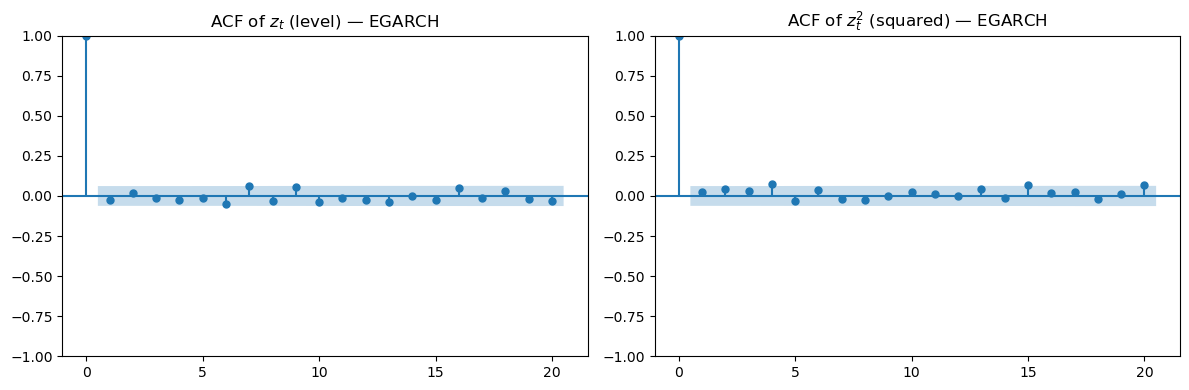

Engle-Ng Sign-Bias Test — EGARCH:
                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     3.993
Date:                Fri, 07 Aug 2026   Prob (F-statistic):             0.0459
Time:                        20:44:06   Log-Likelihood:                -1796.4
No. Observations:                1007   AIC:                             3597.
Df Residuals:                    1005   BIC:                             3607.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0

In [58]:
# ── Serial dependence — inherits the corrected Method-1 u_t ──
z_t_regression_egarch = compute_z(u_t_regression_egarch, dates_regression_egarch_pit)

lb_level_regression_egarch, lb_sq_regression_egarch = ljung_box_tests(z_t_regression_egarch)
print_ljung_box(lb_level_regression_egarch, lb_sq_regression_egarch, label="EGARCH")
plot_acf_diagnostics(z_t_regression_egarch, label="EGARCH")

sign_bias_model_regression_egarch = sign_bias_test(
    z_t_regression_egarch, returns_regression_egarch_pit, dates_regression_egarch_pit
)
print_sign_bias(sign_bias_model_regression_egarch, label="EGARCH")

### Sequential EGARCH

In [59]:
# ── Carry forward per-draw end-of-regression state (no re-simulation needed) ──
# FIX: previously used sigma[:,-1], the state ENTERING the window's last day (informed only
# through the second-to-last return). ls2_next is the true state after ALL returns are seen.
ls2_carry_egarch = np.array(mcmc_egarch.get_samples()["ls2_next"])   # shape (S,) — each draw's own true ls2_T
sigma_carry_egarch = np.sqrt(np.exp(ls2_carry_egarch))

print(f"Number of posterior draws carried forward: {len(sigma_carry_egarch)}")
print(f"Mean sigma at end of regression: {sigma_carry_egarch.mean():.6f}")
print(f"5th-95th percentile: [{np.percentile(sigma_carry_egarch, 5):.6f}, "
      f"{np.percentile(sigma_carry_egarch, 95):.6f}]")

Number of posterior draws carried forward: 8000
Mean sigma at end of regression: 0.008328
5th-95th percentile: [0.007844, 0.008852]


In [60]:
# ── Core numerical/data libraries ──
import numpy as np
import pandas as pd
import scipy.stats as scipy_stats          # note: code uses `scipy_stats.t.cdf`, not `stats.t.cdf`
from scipy.stats import norm, kstest, beta as beta_dist, gamma as gamma_dist
import scipy.special                       # for gammaln, used in E_abs_z_t

# ── JAX / NumPyro (model fitting) ──
import jax
jax.config.update("jax_enable_x64", True)  # MUST be before any JAX operations
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
numpyro.set_host_device_count(4)

# ── Statistical diagnostics ──
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm

# ── Plotting ──
import matplotlib.pyplot as plt

# ── Saving/loading results ──
import pickle
from pathlib import Path


In [129]:
# Seeded for reproducibility -- covers forward_simulate_egarch_window's random shocks (blind + filtered legs)
np.random.seed(42)

def fit_beta_params(samples):
    a, b, _, _ = beta_dist.fit(np.array(samples), floc=0, fscale=1)
    return float(a), float(b)

def fit_gamma_params(samples):
    mu, var = np.array(samples).mean(), np.array(samples).var()
    return float(mu**2 / var), float(mu / var)

def forward_simulate_egarch_window(samples_prior, ls2_start_per_draw, T_w):
    '''Forward-simulate T_w days using each draw's own parameters + own carried state.'''
    S = len(samples_prior["alpha"])
    alpha_s  = np.array(samples_prior["alpha"])
    beta_s   = np.array(samples_prior["beta"])
    gamma_s  = np.array(samples_prior["gamma"])
    nu_s     = np.array(samples_prior["nu_shift"]) + 2.1
    uncond_s = np.array(samples_prior["uncond_vol"])
    omega_s  = np.log(uncond_s**2) * (1 - beta_s)
    e_abs_s  = E_abs_z_interp_numpy(nu_s)

    sigma_paths = np.zeros((S, T_w))
    ls2 = ls2_start_per_draw.copy()
    for t in range(T_w):
        sigma_paths[:, t] = np.sqrt(np.exp(np.clip(ls2, -20, 2)))
        z = np.random.standard_t(nu_s) * np.sqrt((nu_s - 2) / nu_s)
        ls2 = np.clip(omega_s + beta_s*ls2 + gamma_s*z + alpha_s*(np.abs(z) - e_abs_s), -20, 2)
    return sigma_paths


def filtered_pass_egarch_window(samples_prior, ls2_start_per_draw, window_returns):
    '''t,t+1-style causal filter: walks the EGARCH recursion through the REAL
    window returns instead of random shocks. filtered_sigma[:, t] is the state
    entering day t, informed only by returns[0..t-1] (and the carried-in state) --
    it never touches returns[t] itself, so it is safe to use for one-step-ahead PIT.'''
    S = len(samples_prior["alpha"])
    alpha_s  = np.array(samples_prior["alpha"])
    beta_s   = np.array(samples_prior["beta"])
    gamma_s  = np.array(samples_prior["gamma"])
    nu_s     = np.array(samples_prior["nu_shift"]) + 2.1
    mu_s     = np.array(samples_prior["mu_ret"])
    uncond_s = np.array(samples_prior["uncond_vol"])
    omega_s  = np.log(uncond_s**2) * (1 - beta_s)
    e_abs_s  = E_abs_z_interp_numpy(nu_s)

    T_w = len(window_returns)
    filtered_sigma = np.zeros((S, T_w))
    ls2 = ls2_start_per_draw.copy()
    for t in range(T_w):
        filtered_sigma[:, t] = np.sqrt(np.exp(np.clip(ls2, -20, 2)))
        z_t = (window_returns[t] - mu_s) / filtered_sigma[:, t]
        if t < T_w - 1:
            ls2 = np.clip(omega_s + beta_s*ls2 + gamma_s*z_t + alpha_s*(np.abs(z_t) - e_abs_s), -20, 2)
    return filtered_sigma


def filtered_forecast_egarch_window(samples_prior, ls2_start_per_draw, window_returns, h=21):
    '''t,t+1-style forecast. Each day t's state is causally filtered through real
    returns[:t] (see filtered_pass_egarch_window), then blind-forward-simulated h days
    to get that day's h-day-ahead HV forecast -- future returns are genuinely unknown
    at evaluation time, so the h-day leg still has to be a blind simulation.
    Returns (filtered_sigma, forecast_hv, hv_per_draw):
      filtered_sigma : (S, T_w) -- causal one-step-ahead state, for PIT.
      forecast_hv    : (T_w,)   -- pooled h-day-ahead HV forecast anchored at each day.
      hv_per_draw    : (S, T_w) -- per-draw version of the same, for CI bands.'''
    filtered_sigma = filtered_pass_egarch_window(samples_prior, ls2_start_per_draw, window_returns)
    S = filtered_sigma.shape[0]
    T_w = len(window_returns)
    forecast_hv = np.full(T_w, np.nan)
    hv_per_draw = np.full((S, T_w), np.nan)
    for t in range(T_w):
        ls2_t = np.log(filtered_sigma[:, t]**2)   # FIX: forward_simulate_egarch_window expects log-variance, not sigma
        sim_paths_t = forward_simulate_egarch_window(samples_prior, ls2_t, h)
        mean_sigma_sq_per_step = np.mean(sim_paths_t**2, axis=0)
        forecast_hv[t] = np.sqrt(mean_sigma_sq_per_step.mean())
        hv_per_draw[:, t] = np.sqrt(np.mean(sim_paths_t**2, axis=1))
    return filtered_sigma, forecast_hv, hv_per_draw


def make_egarch_model_refit(mu_prior_mu, mu_prior_std, alpha_prior_mu, alpha_prior_std,
                                   beta_a, beta_b, gamma_prior_mu, gamma_prior_std,
                                   nu_shape, nu_rate, uncond_prior_mu, uncond_prior_std,
                                   beta_egarch, e_abs_grid, ls2_seed_scalar):
    '''Returns a NumPyro model function for one sequential window's refit, with all
    window-specific priors and the carried-forward state closed over explicitly.'''
    e_abs_grid_t = jnp.array(e_abs_grid)

    def E_abs_z_interp(nu):
        idx      = (nu - 2.1) / (100 - 2.1) * 999
        idx_low  = jnp.clip(jnp.floor(idx).astype(int), 0, 998)
        idx_high = jnp.clip(idx_low + 1, 0, 999)
        frac     = idx - jnp.floor(idx)
        return e_abs_grid_t[idx_low]*(1-frac) + e_abs_grid_t[idx_high]*frac

    def egarch_model_sequential(returns):
        mu_ret   = numpyro.sample("mu_ret",   dist.Normal(mu_prior_mu, mu_prior_std))
        alpha    = numpyro.sample("alpha",    dist.TruncatedNormal(alpha_prior_mu, alpha_prior_std, low=0))
        beta     = numpyro.sample("beta",     dist.Beta(beta_a, beta_b))
        gamma    = numpyro.sample("gamma",    dist.Normal(gamma_prior_mu, gamma_prior_std))
        nu_shift = numpyro.sample("nu_shift", dist.Gamma(nu_shape, nu_rate))
        nu       = nu_shift + 2.1
        uncond_vol = numpyro.sample("uncond_vol", dist.TruncatedNormal(uncond_prior_mu, uncond_prior_std, low=0, high=0.03))
        omega    = jnp.log(uncond_vol**2) * (1 - beta_egarch)

        e_abs = E_abs_z_interp(nu)

        def egarch_step(ls2, r):
            z = (r - mu_ret) / jnp.sqrt(jnp.exp(jnp.clip(ls2, -20.0, 2.0)))
            ls2_new = omega + beta*ls2 + gamma*z + alpha*(jnp.abs(z) - e_abs)
            return jnp.clip(ls2_new, -20.0, 2.0), ls2_new

        ls2_init = jnp.float64(ls2_seed_scalar)
        # Scanning ALL T returns (not returns[:-1]) produces log_sigma2_shifted = [ls2_1,...,ls2_T] --
        # one step further than the likelihood needs, since T returns naturally imply T+1 states
        # (ls2_0 through ls2_T) but the likelihood only ever scores ls2_0..ls2_{T-1} against
        # returns[0..T-1]. log_sigma2_full (next line) reconstructs exactly that likelihood-facing
        # sequence -- prepend ls2_init as ls2_0, drop the extra ls2_T via [:-1] -- so the fit itself
        # is byte-for-byte unchanged from scanning returns[:-1]. The dropped element,
        # log_sigma2_shifted[-1] == ls2_T, is the true state AFTER this window's last return; it
        # never enters the likelihood, only reused below as ls2_next for carry-forward.
        _, log_sigma2_shifted = jax.lax.scan(egarch_step, ls2_init, returns)
        log_sigma2_full = jnp.concatenate([ls2_init.reshape(1), log_sigma2_shifted[:-1]])
        sigma = jnp.sqrt(jnp.exp(log_sigma2_full))
        numpyro.deterministic("sigma", sigma)
        numpyro.deterministic("ls2_next", log_sigma2_shifted[-1])
        scale = jnp.clip(sigma * jnp.sqrt((nu-2)/nu), 1e-6, 10)
        numpyro.sample("obs", dist.StudentT(nu, mu_ret, scale), obs=returns)

    return egarch_model_sequential




In [ ]:
# ── Initialize ──────────────────────────────────────────────────────
target_S = 2000
if len(samples_egarch["alpha"]) != target_S:
    idx = np.random.choice(len(samples_egarch["alpha"]), size=target_S, replace=False)
    samples_w = {k: np.array(v)[idx] for k, v in samples_egarch.items()}
    ls2_current_seq = ls2_carry_egarch[idx]
else:
    samples_w = samples_egarch
    ls2_current_seq = ls2_carry_egarch

all_pit_values_egarch_seq   = []
all_returns_obs_egarch_seq  = []
all_window_stats_egarch_seq = []
all_forecast_egarch_seq     = []
all_hv_per_draw_egarch_seq  = []
all_samples_w_by_window     = []

# ── t,t+1 (filtered) forecast -- parallel storage, existing arrays above untouched ──
all_forecast_egarch_seq_filtered    = []
all_hv_per_draw_egarch_seq_filtered = []
all_pit_values_egarch_seq_filtered  = []

for i in range(len(window_boundaries) - 1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    window_returns = full_returns[window_start:window_end].values.flatten().astype('float64')
    T_w = len(window_returns)

    # ── Step 0: forward-simulated forecast for THIS window, using ONLY the incoming posterior ──
    # Simulate h-1 extra "overhang" days past the window so the rolling h-day HV window has
    # enough runway to produce a real (non-NaN) forecast for every day, including the last h-1 --
    # those overhang days are blind-simulated continuation, discarded afterward.
    h_horizon = 21
    sim_paths_ext = forward_simulate_egarch_window(samples_w, ls2_current_seq, T_w + h_horizon - 1)
    sim_paths = sim_paths_ext[:, :T_w]   # exactly the window's real days -- PIT below is unaffected

    forecast_window_egarch = sigma_to_hv_correct(sim_paths_ext, h=h_horizon)[:T_w]
    all_forecast_egarch_seq.append(forecast_window_egarch)

    hv_per_draw_window = np.sqrt(sigma_sq_windowed_per_path(sim_paths_ext, h=h_horizon))[:, :T_w]
    all_hv_per_draw_egarch_seq.append(hv_per_draw_window)

    # ── Step 0b: t,t+1-style forecast -- causal day-by-day filtering through REAL returns ──
    # Unlike Step 0 (blind from window-start state), each day's state here is informed by
    # yesterday's real return. The h=21-day HV leg still blind-simulates forward, since
    # future returns are genuinely unknown at evaluation time.
    filtered_sigma_egarch, forecast_window_egarch_filtered, hv_per_draw_window_filtered = \
        filtered_forecast_egarch_window(samples_w, ls2_current_seq, window_returns, h=21)
    all_forecast_egarch_seq_filtered.append(forecast_window_egarch_filtered)
    all_hv_per_draw_egarch_seq_filtered.append(hv_per_draw_window_filtered)

    S_filt = filtered_sigma_egarch.shape[0]
    nu_s_filt = np.array(samples_w["nu_shift"]) + 2.1
    mu_s_filt = np.array(samples_w["mu_ret"])
    scale_filt = filtered_sigma_egarch * np.sqrt((nu_s_filt[:, None] - 2) / nu_s_filt[:, None])
    u_per_draw_filt = np.zeros((S_filt, T_w))
    for s in range(S_filt):
        u_per_draw_filt[s] = scipy_stats.t.cdf(window_returns, df=nu_s_filt[s], loc=mu_s_filt[s], scale=scale_filt[s])
    pit_w_filtered = np.mean(u_per_draw_filt, axis=0)
    all_pit_values_egarch_seq_filtered.extend(pit_w_filtered)

    # ── Step 1: PIT from the forecast (sim_paths), Method 1 (averaged across draws) ──
    S = sim_paths.shape[0]
    mu_s = np.array(samples_w["mu_ret"])
    nu_s = np.array(samples_w["nu_shift"]) + 2.1
    scale_s = sim_paths * np.sqrt((nu_s[:, None] - 2) / nu_s[:, None])

    u_per_draw = np.zeros((S, T_w))
    for s in range(S):
        u_per_draw[s] = scipy_stats.t.cdf(window_returns, df=nu_s[s], loc=mu_s[s], scale=scale_s[s])

    pit_w = np.mean(u_per_draw, axis=0)

    all_pit_values_egarch_seq.extend(pit_w)
    all_returns_obs_egarch_seq.extend(window_returns)

    # ── Step 2: Extract priors from previous posterior ──
    alpha_post_seq  = float(np.array(samples_w["alpha"]).mean())
    beta_post_seq   = float(np.array(samples_w["beta"]).mean())
    gamma_post_seq  = float(np.array(samples_w["gamma"]).mean())
    uncond_post_seq = float(np.array(samples_w["uncond_vol"]).mean())
    mu_post_seq     = float(np.array(samples_w["mu_ret"]).mean())

    alpha_prior_mu, alpha_prior_std = alpha_post_seq, max(float(np.array(samples_w["alpha"]).std()), 0.01)
    beta_a, beta_b   = fit_beta_params(samples_w["beta"])
    gamma_prior_mu, gamma_prior_std = gamma_post_seq, max(float(np.array(samples_w["gamma"]).std()), 0.01)
    uncond_prior_mu, uncond_prior_std = uncond_post_seq, max(float(np.array(samples_w["uncond_vol"]).std()), 0.003)
    mu_prior_mu, mu_prior_std = mu_post_seq, max(float(np.array(samples_w["mu_ret"]).std()), 0.0001)
    nu_shape, nu_rate = fit_gamma_params(samples_w["nu_shift"])

    ls2_seed_scalar = float(np.mean(ls2_current_seq))

    # ── Step 3: Refit ──
    returns_jax_w = jnp.array(window_returns)

    egarch_model_sequential = make_egarch_model_refit(
        mu_prior_mu, mu_prior_std, alpha_prior_mu, alpha_prior_std,
        beta_a, beta_b, gamma_prior_mu, gamma_prior_std,
        nu_shape, nu_rate, uncond_prior_mu, uncond_prior_std,
        beta_egarch, e_abs_grid, ls2_seed_scalar
    )

    print(f"Refitting on {len(window_returns)} observations...")
    mcmc_w = MCMC(NUTS(egarch_model_sequential, target_accept_prob=0.95),
                  num_warmup=500, num_samples=1000, num_chains=2, chain_method="sequential")
    mcmc_w.run(jax.random.PRNGKey(i+100), returns_jax_w)
    samples_w = mcmc_w.get_samples()

    all_samples_w_by_window.append({k: np.array(v) for k, v in samples_w.items()})

    # ── Step 4: carry forward THIS window's own per-draw end state ──
    # FIX: ls2_next is the true state after this window's LAST return (previously used
    # sigma[:,-1], the state entering the last day -- missing that day's own return)
    ls2_current_seq = np.array(samples_w["ls2_next"])

    all_window_stats_egarch_seq.append({
        "window": i+1, "start": str(window_start.date()), "end": str(window_end.date()),
        "n_obs": T_w,
        "pit_coverage": float(np.mean((pit_w >= 0.05) & (pit_w <= 0.95))),
        "uncond_vol": uncond_post_seq, "beta": beta_post_seq,
    })
    print(f"Window {i+1} PIT coverage: {all_window_stats_egarch_seq[-1]['pit_coverage']:.2%}")
    print(f"Carry forward mean sigma: {np.mean(np.sqrt(np.exp(ls2_current_seq))):.6f}")

# ── Final arrays ──────────────────────────────────────────────────────
all_pit_values_egarch_seq  = np.array(all_pit_values_egarch_seq)
all_returns_obs_egarch_seq = np.array(all_returns_obs_egarch_seq)
forecast_sequential_egarch = np.concatenate(all_forecast_egarch_seq)

# ── t,t+1 (filtered) final arrays ──
all_pit_values_egarch_seq_filtered = np.array(all_pit_values_egarch_seq_filtered)
forecast_sequential_egarch_filtered = np.concatenate(all_forecast_egarch_seq_filtered)

In [62]:
from pathlib import Path
Path("results/egarch").mkdir(parents=True, exist_ok=True)

sequential_mcmc_egarch = {
    "forecast_sequential":       forecast_sequential_egarch,
    "pit_values":                all_pit_values_egarch_seq,
    "returns_observed":          all_returns_obs_egarch_seq,
    "window_stats":              all_window_stats_egarch_seq,
    "final_samples_w":           {k: np.array(v) for k, v in samples_w.items()},
    "all_forecast_by_window":    all_forecast_egarch_seq,
    "all_hv_per_draw_by_window": all_hv_per_draw_egarch_seq,   # NEW
    "all_samples_w_by_window":   all_samples_w_by_window,       # NEW — avoids ever needing to rerun again
    "forecast_sequential_filtered":    forecast_sequential_egarch_filtered,
    "pit_values_filtered":             all_pit_values_egarch_seq_filtered,
    "all_forecast_by_window_filtered": all_forecast_egarch_seq_filtered,
    "all_hv_per_draw_by_window_filtered": all_hv_per_draw_egarch_seq_filtered,
}

with open("results/egarch/egarch_sequential_mcmc.pkl", "wb") as f:
    pickle.dump(sequential_mcmc_egarch, f)

print("Saved sequential MCMC results.")

Saved sequential MCMC results.


In [63]:
forecast_sequential_egarch_pieces = []
forecast_sequential_egarch_dates = []

for i in range(len(window_boundaries) - 1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    window_dates = full_returns[window_start:window_end].index
    piece = all_forecast_egarch_seq[i]
    
    assert len(piece) == len(window_dates), f"Window {i+1}: forecast length {len(piece)} != date length {len(window_dates)}"
    
    forecast_sequential_egarch_pieces.append(piece)
    forecast_sequential_egarch_dates.append(window_dates)

forecast_sequential_egarch_series = pd.Series(
    np.concatenate(forecast_sequential_egarch_pieces),
    index=np.concatenate(forecast_sequential_egarch_dates)
).dropna()

# ── t,t+1 (filtered) version, same window/date alignment ──
forecast_sequential_egarch_filtered_pieces = []

for i in range(len(window_boundaries) - 1):
    piece_filtered = all_forecast_egarch_seq_filtered[i]
    window_dates_i = forecast_sequential_egarch_dates[i]
    assert len(piece_filtered) == len(window_dates_i), \
        f"Window {i+1}: filtered forecast length {len(piece_filtered)} != date length {len(window_dates_i)}"
    forecast_sequential_egarch_filtered_pieces.append(piece_filtered)

forecast_sequential_egarch_filtered_series = pd.Series(
    np.concatenate(forecast_sequential_egarch_filtered_pieces),
    index=np.concatenate(forecast_sequential_egarch_dates)
).dropna()

In [64]:
dates_sequential_egarch_pit = np.concatenate(forecast_sequential_egarch_dates)  # same underlying dates, already computed
returns_sequential_egarch = all_returns_obs_egarch_seq

assert len(all_pit_values_egarch_seq) == len(dates_sequential_egarch_pit), \
    f"Mismatch: {len(all_pit_values_egarch_seq)} PIT values vs {len(dates_sequential_egarch_pit)} dates"
assert len(all_pit_values_egarch_seq) == len(returns_sequential_egarch), \
    f"Mismatch: {len(all_pit_values_egarch_seq)} PIT values vs {len(returns_sequential_egarch)} returns"


In [65]:
forecast_sequential_egarch, actual_sequential_egarch, dates_sequential_egarch = align_series(
    forecast_sequential_egarch_series, hv_sequential
)

In [66]:
ql_sequential_egarch = qlike(forecast_sequential_egarch, actual_sequential_egarch)

qlike_windows_egarch = metric_by_period(forecast_sequential_egarch, actual_sequential_egarch,
                                          dates_sequential_egarch, window_boundaries, qlike)
print_metric_by_window(qlike_windows_egarch, label="EGARCH", metric_name="QLIKE")

QLIKE by window — EGARCH:
  period_1 (2022-01-01 to 2022-07-01): 0.4552
  period_2 (2022-07-01 to 2023-01-01): 0.0874
  period_3 (2023-01-01 to 2023-07-01): 0.5456
  period_4 (2023-07-01 to 2024-01-01): 0.4048
  period_5 (2024-01-01 to 2024-07-01): 0.3764
  period_6 (2024-07-01 to 2025-01-01): 0.1989
  period_7 (2025-01-01 to 2025-07-01): 1.3727
  period_8 (2025-07-01 to 2026-01-01): 0.3456


In [67]:
# ── t,t+1 (filtered) version, same alignment machinery as the blind forecast above ──
forecast_sequential_egarch_filtered, actual_sequential_egarch_filtered, dates_sequential_egarch_filtered = align_series(
    forecast_sequential_egarch_filtered_series, hv_sequential
)

In [68]:
ql_sequential_egarch_filtered = qlike(forecast_sequential_egarch_filtered, actual_sequential_egarch_filtered)
print(f"QLIKE (EGARCH sequential, filtered t,t+1): mean = {ql_sequential_egarch_filtered.mean():.4f}")
print(f"QLIKE (EGARCH sequential, blind t+126):    mean = {ql_sequential_egarch.mean():.4f}")

qlike_windows_egarch_filtered = metric_by_period(forecast_sequential_egarch_filtered, actual_sequential_egarch_filtered,
                                                    dates_sequential_egarch_filtered, window_boundaries, qlike)
print_metric_by_window(qlike_windows_egarch_filtered, label="EGARCH (filtered t,t+1)", metric_name="QLIKE")

QLIKE (EGARCH sequential, filtered t,t+1): mean = 0.2944
QLIKE (EGARCH sequential, blind t+126):    mean = 0.4714
QLIKE by window — EGARCH (filtered t,t+1):
  period_1 (2022-01-01 to 2022-07-01): 0.1516
  period_2 (2022-07-01 to 2023-01-01): 0.0779
  period_3 (2023-01-01 to 2023-07-01): 0.3591
  period_4 (2023-07-01 to 2024-01-01): 0.2637
  period_5 (2024-01-01 to 2024-07-01): 0.2186
  period_6 (2024-07-01 to 2025-01-01): 0.2403
  period_7 (2025-01-01 to 2025-07-01): 0.7744
  period_8 (2025-07-01 to 2026-01-01): 0.2834


In [69]:
# Concatenate per-window hv_per_draw along the time axis, matching forecast_sequential_egarch_series's dates
hv_per_draw_sequential_egarch_full = np.concatenate(all_hv_per_draw_egarch_seq, axis=1)  # (S, T_total)

hv_per_draw_sequential_df = pd.DataFrame(
    hv_per_draw_sequential_egarch_full.T,
    index=np.concatenate(forecast_sequential_egarch_dates)  # same date pieces used for forecast_sequential_egarch_series
).dropna()

hv_per_draw_sequential_aligned = hv_per_draw_sequential_df.loc[dates_sequential_egarch].values.T

In [70]:
print(len(all_hv_per_draw_egarch_seq))
for i, x in enumerate(all_hv_per_draw_egarch_seq):
    print(i, x.shape)

8
0 (2000, 124)
1 (2000, 127)
2 (2000, 124)
3 (2000, 126)
4 (2000, 124)
5 (2000, 128)
6 (2000, 122)
7 (2000, 127)


In [71]:
def hv_coverage_sequential_posterior(hv_per_draw, actual, dates, window_boundaries, sigma_eta_by_window, level=90):
    '''Combined posterior-spread + noise coverage, using a different sigma_eta per window (expanding).'''
    S, T = hv_per_draw.shape
    inside = np.zeros(T, dtype=bool)
    lower_full = np.zeros(T)
    upper_full = np.zeros(T)
    pct = (100 - level) / 2

    for i, (start_idx, end_idx) in enumerate(period_indices(dates, window_boundaries)):
        sigma_eta_i = sigma_eta_by_window[f"window_{i+1}"]
        window_hv_per_draw = hv_per_draw[:, start_idx:end_idx]
        noise = np.random.normal(0, sigma_eta_i, size=window_hv_per_draw.shape)
        noisy_hv = window_hv_per_draw * np.exp(noise)

        lower = np.percentile(noisy_hv, pct, axis=0)
        upper = np.percentile(noisy_hv, 100 - pct, axis=0)
        lower_full[start_idx:end_idx] = lower
        upper_full[start_idx:end_idx] = upper
        inside[start_idx:end_idx] = (actual[start_idx:end_idx] >= lower) & (actual[start_idx:end_idx] <= upper)

    return lower_full, upper_full, inside

90% CI Coverage by window — EGARCH:
  period_1 (2022-01-01 to 2022-07-01): 92.74%
  period_2 (2022-07-01 to 2023-01-01): 100.00%
  period_3 (2023-01-01 to 2023-07-01): 84.68%
  period_4 (2023-07-01 to 2024-01-01): 96.83%
  period_5 (2024-01-01 to 2024-07-01): 97.58%
  period_6 (2024-07-01 to 2025-01-01): 100.00%
  period_7 (2025-01-01 to 2025-07-01): 81.15%
  period_8 (2025-07-01 to 2026-01-01): 93.40%


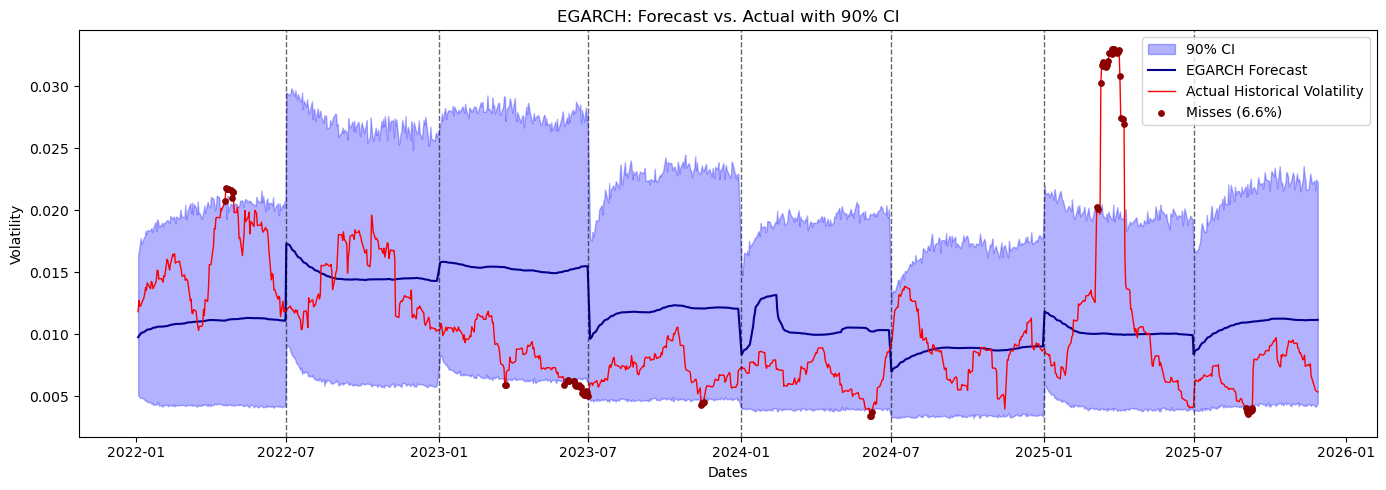

In [72]:
# Seeded for reproducibility -- covers hv_coverage_sequential_posterior's measurement-noise injection (EGARCH sequential CI)
np.random.seed(42)

sigma_eta_windows_egarch = sigma_eta_sequential(
    forecast_sequential_egarch, actual_sequential_egarch,
    forecast_regression_egarch, actual_regression_egarch,
    dates_sequential_egarch, window_boundaries
)

lower_seq_egarch, upper_seq_egarch, inside_seq_egarch = hv_coverage_sequential_posterior(
    hv_per_draw_sequential_aligned, actual_sequential_egarch, dates_sequential_egarch,
    window_boundaries, sigma_eta_windows_egarch, level=90
)

coverage_windows_egarch = mask_by_period(inside_seq_egarch, dates_sequential_egarch, window_boundaries)
print_coverage_by_window(coverage_windows_egarch, label="EGARCH", level=90)

plot_hv_coverage(
    forecast_sequential_egarch, actual_sequential_egarch, dates_sequential_egarch,
    lower_seq_egarch, upper_seq_egarch, inside_seq_egarch,
    level=90, label="EGARCH",
    boundary_dates=window_boundaries,
    boundary_labels=[None]*len(window_boundaries),
    boundary_styles=['--']*len(window_boundaries)
)

In [73]:
avg_of_hv_per_draw = np.mean(hv_per_draw_sequential_aligned, axis=0)
print(np.mean(forecast_sequential_egarch - avg_of_hv_per_draw))  # should be small but positive, per Jensen

0.0009893991830936145


In [74]:
print(np.mean(forecast_sequential_egarch))
print(0.0011673153602909285 / np.mean(forecast_sequential_egarch))

0.01164324262147729
0.10025689562954586


EGARCH (Sequential, t,t+1 filtered) — KS statistic: 0.0338
EGARCH (Sequential, t,t+1 filtered) — p-value: 0.1974
EGARCH (Sequential, t,t+1 filtered) — Fail to reject null: no evidence of miscalibration


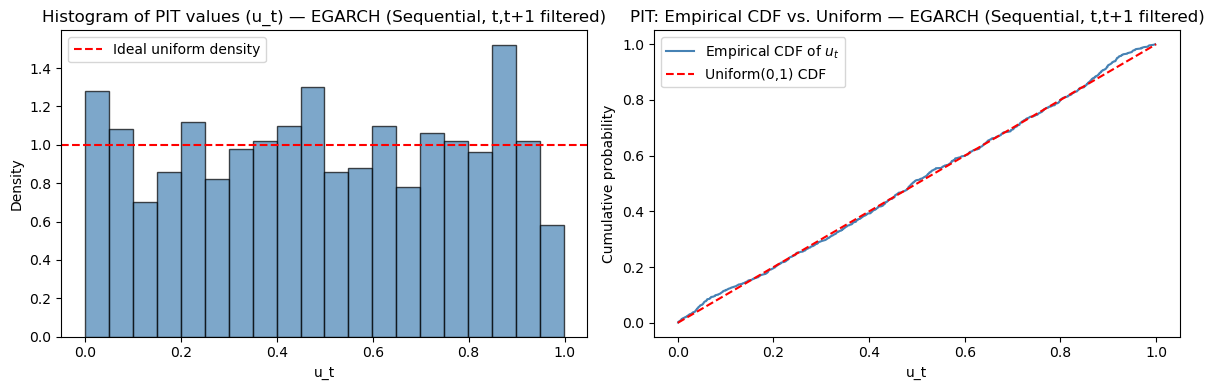

In [75]:
# should be scipy_stats import ktest
ks_stat_seq_egarch, p_value_seq_egarch = kstest(all_pit_values_egarch_seq_filtered, 'uniform')
print_pit_result(ks_stat_seq_egarch, p_value_seq_egarch, label="EGARCH (Sequential, t,t+1 filtered)")
plot_pit(all_pit_values_egarch_seq_filtered, label="EGARCH (Sequential, t,t+1 filtered)")

Ljung-Box test on z_t (level) — EGARCH (Sequential, t,t+1 filtered):
     lb_stat  lb_pvalue
1   0.020315   0.886660
5   2.410272   0.789943
10  2.821153   0.985325

Ljung-Box test on z_t^2 (squared, ARCH-LM style) — EGARCH (Sequential, t,t+1 filtered):
      lb_stat  lb_pvalue
1    3.284310   0.069945
5   15.212608   0.009491
10  17.247699   0.069060


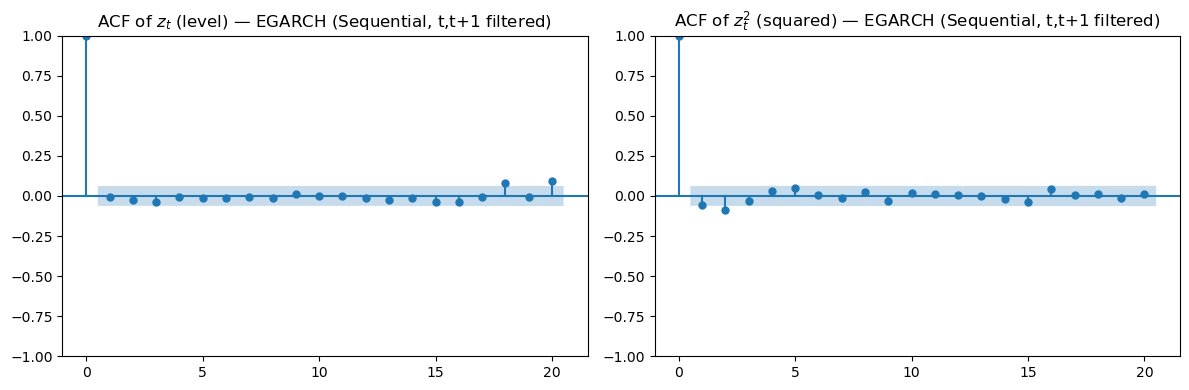

Engle-Ng Sign-Bias Test — EGARCH (Sequential, t,t+1 filtered):
                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8537
Date:                Fri, 07 Aug 2026   Prob (F-statistic):              0.356
Time:                        20:49:40   Log-Likelihood:                -1720.0
No. Observations:                1001   AIC:                             3444.
Df Residuals:                     999   BIC:                             3454.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [76]:
# ── Serial dependence — using the corrected PIT values, dates, and returns ──
z_t_sequential_egarch = compute_z(all_pit_values_egarch_seq_filtered, dates_sequential_egarch_pit)

lb_level_seq_egarch, lb_sq_seq_egarch = ljung_box_tests(z_t_sequential_egarch)
print_ljung_box(lb_level_seq_egarch, lb_sq_seq_egarch, label="EGARCH (Sequential, t,t+1 filtered)")
plot_acf_diagnostics(z_t_sequential_egarch, label="EGARCH (Sequential, t,t+1 filtered)")

sign_bias_model_seq_egarch = sign_bias_test(
    z_t_sequential_egarch, returns_sequential_egarch, dates_sequential_egarch_pit
)
print_sign_bias(sign_bias_model_seq_egarch, label="EGARCH (Sequential, t,t+1 filtered)")

### EGARCH: Regression, Matched Period (2022-2025)

A second, one-shot regression, fit on the exact same 2022-2025 span the Sequential loop covers, carried forward from the 2018-2021 regression's posterior (`samples_egarch`, `ls2_carry_egarch`) using the same posterior-to-prior extraction and `make_egarch_model_refit` builder each Sequential window already uses — same priors, same starting state. The only difference from Sequential is that this fits once over the whole span instead of refitting every 6 months, which isolates that refit-frequency effect from the 2018-2021-vs-2022-2025 market-period effect that otherwise confounds the original Regression-vs-Sequential comparison.

In [131]:
# ── Priors: carried forward from the 2018-2021 regression posterior, same extraction as each Sequential window's Step 2 ──
alpha_post_r22  = float(np.array(samples_egarch["alpha"]).mean())
beta_post_r22   = float(np.array(samples_egarch["beta"]).mean())
gamma_post_r22  = float(np.array(samples_egarch["gamma"]).mean())
uncond_post_r22 = float(np.array(samples_egarch["uncond_vol"]).mean())
mu_post_r22     = float(np.array(samples_egarch["mu_ret"]).mean())

alpha_prior_mu_r22, alpha_prior_std_r22   = alpha_post_r22, max(float(np.array(samples_egarch["alpha"]).std()), 0.01)
beta_a_r22, beta_b_r22                    = fit_beta_params(samples_egarch["beta"])
gamma_prior_mu_r22, gamma_prior_std_r22   = gamma_post_r22, max(float(np.array(samples_egarch["gamma"]).std()), 0.01)
uncond_prior_mu_r22, uncond_prior_std_r22 = uncond_post_r22, max(float(np.array(samples_egarch["uncond_vol"]).std()), 0.003)
mu_prior_mu_r22, mu_prior_std_r22         = mu_post_r22, max(float(np.array(samples_egarch["mu_ret"]).std()), 0.0001)
nu_shape_r22, nu_rate_r22                 = fit_gamma_params(samples_egarch["nu_shift"])

ls2_seed_scalar_r22 = float(np.mean(ls2_carry_egarch))   # same carried state Sequential's window 1 uses

egarch_model_refit2022 = make_egarch_model_refit(
    mu_prior_mu_r22, mu_prior_std_r22, alpha_prior_mu_r22, alpha_prior_std_r22,
    beta_a_r22, beta_b_r22, gamma_prior_mu_r22, gamma_prior_std_r22,
    nu_shape_r22, nu_rate_r22, uncond_prior_mu_r22, uncond_prior_std_r22,
    beta_egarch, e_abs_grid, ls2_seed_scalar_r22
)

print(f"Refitting EGARCH on the full 2022-2025 span ({len(sequential_returns_1d)} observations)...")
mcmc_egarch_r22 = MCMC(NUTS(egarch_model_refit2022, target_accept_prob=0.95),
                        num_warmup=500, num_samples=1000, num_chains=2, chain_method="sequential")
mcmc_egarch_r22.run(jax.random.PRNGKey(2022), jnp.array(sequential_returns_1d))
samples_egarch_r22 = mcmc_egarch_r22.get_samples()
print("Done.")

Refitting EGARCH on the full 2022-2025 span (1002 observations)...


sample: 100%|██████████| 1500/1500 [00:49<00:00, 30.01it/s, 127 steps of size 2.87e-02. acc. prob=0.94]

Done.


In [132]:
Path("results/egarch").mkdir(parents=True, exist_ok=True)

with open("results/egarch/egarch_regression_2022_mcmc.pkl", "wb") as f:
    pickle.dump({k: np.array(v) for k, v in samples_egarch_r22.items()}, f)

print("Saved EGARCH matched-period (2022-2025) regression MCMC samples.")

Saved EGARCH matched-period (2022-2025) regression MCMC samples.


In [133]:
with open("results/egarch/egarch_regression_2022_mcmc.pkl", "rb") as f:
    samples_egarch_r22 = pickle.load(f)

In [134]:
# Seeded for reproducibility -- covers hv_coverage_posterior's measurement-noise injection (EGARCH Regression 2022-2025, 90% CI)
np.random.seed(42)

sigma_posterior_egarch_r22 = np.array(samples_egarch_r22["sigma"])   # in-sample causally-filtered sigma, same role as sigma_posterior_egarch

forecast_regression_egarch_r22_series = pd.Series(
    sigma_to_hv_correct(sigma_posterior_egarch_r22, h=21),
    index=sequential_returns.index
).dropna()

forecast_regression_egarch_r22, actual_regression_egarch_r22, dates_regression_egarch_r22 = align_series(
    forecast_regression_egarch_r22_series, hv_sequential
)

ql_regression_egarch_r22 = qlike(forecast_regression_egarch_r22, actual_regression_egarch_r22)
print(f"QLIKE (EGARCH regression, 2022-2025 matched period): mean = {ql_regression_egarch_r22.mean():.4f}")

# ── RV Coverage: combined posterior spread + log-normal noise (Order A) ──
sigma_eta_egarch_r22, _ = hv_coverage(forecast_regression_egarch_r22, actual_regression_egarch_r22)

hv_per_draw_regression_egarch_r22 = hv_per_draw_windowed(sigma_posterior_egarch_r22, h=21)

hv_per_draw_regression_egarch_r22_df = pd.DataFrame(
    hv_per_draw_regression_egarch_r22.T, index=sequential_returns.index
).loc[dates_regression_egarch_r22]
hv_per_draw_regression_egarch_r22_aligned = hv_per_draw_regression_egarch_r22_df.values.T

lower_90_egarch_r22, upper_90_egarch_r22, inside_90_egarch_r22 = hv_coverage_posterior(
    hv_per_draw_regression_egarch_r22_aligned, actual_regression_egarch_r22, sigma_eta_egarch_r22, level=90
)

coverage_90_egarch_r22 = np.mean(inside_90_egarch_r22)
print(f"EGARCH (2022-2025 matched period) — 90% CI coverage (posterior + noise): {coverage_90_egarch_r22:.2%}")

QLIKE (EGARCH regression, 2022-2025 matched period): mean = 0.0726
EGARCH (2022-2025 matched period) — 90% CI coverage (posterior + noise): 82.26%


EGARCH (Regression, 2022-2025 matched period) — KS statistic: 0.0266
EGARCH (Regression, 2022-2025 matched period) — p-value: 0.4699
EGARCH (Regression, 2022-2025 matched period) — Fail to reject null: no evidence of miscalibration


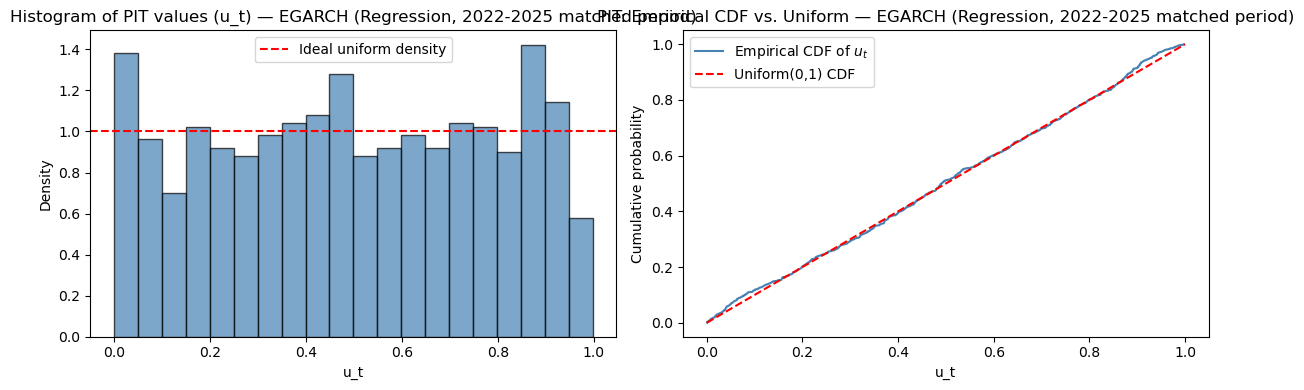

Ljung-Box test on z_t (level) — EGARCH (Regression, 2022-2025 matched period):
     lb_stat  lb_pvalue
1   0.001630   0.967792
5   2.977185   0.703503
10  3.697714   0.959955

Ljung-Box test on z_t^2 (squared, ARCH-LM style) — EGARCH (Regression, 2022-2025 matched period):
      lb_stat  lb_pvalue
1    4.121210   0.042349
5   13.272723   0.020953
10  16.020064   0.099059


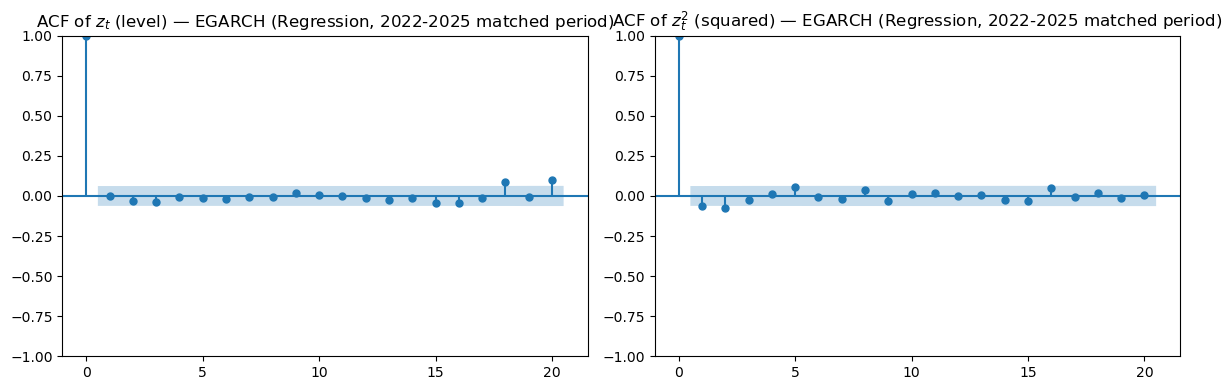

Engle-Ng Sign-Bias Test — EGARCH (Regression, 2022-2025 matched period):
                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.001
Date:                Fri, 07 Aug 2026   Prob (F-statistic):              0.317
Time:                        23:32:11   Log-Likelihood:                -1724.8
No. Observations:                1001   AIC:                             3454.
Df Residuals:                     999   BIC:                             3463.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [135]:
# ── PIT alignment: sigma_posterior_egarch_r22 against returns ──
sigma_posterior_egarch_r22_df = pd.DataFrame(
    sigma_posterior_egarch_r22.T, index=sequential_returns.index
).dropna()

common_dates_pit_r22 = sigma_posterior_egarch_r22_df.index.intersection(sequential_returns.index)
sigma_posterior_egarch_r22_pit = sigma_posterior_egarch_r22_df.loc[common_dates_pit_r22].values.T
returns_regression_egarch_r22_pit = sequential_returns.loc[common_dates_pit_r22].values.flatten()
dates_regression_egarch_r22_pit = common_dates_pit_r22

nu_all_r22     = np.array(samples_egarch_r22["nu_shift"]) + 2.1
mu_ret_all_r22 = np.array(samples_egarch_r22["mu_ret"])

u_t_regression_egarch_r22, ks_stat_regression_egarch_r22, p_value_regression_egarch_r22 = compute_pit_posterior(
    returns_regression_egarch_r22_pit, sigma_posterior_egarch_r22_pit, mu_ret_all_r22, dist='t', df=nu_all_r22
)
print_pit_result(ks_stat_regression_egarch_r22, p_value_regression_egarch_r22, label="EGARCH (Regression, 2022-2025 matched period)")
plot_pit(u_t_regression_egarch_r22, label="EGARCH (Regression, 2022-2025 matched period)")

# ── Serial dependence ──
z_t_regression_egarch_r22 = compute_z(u_t_regression_egarch_r22, dates_regression_egarch_r22_pit)

lb_level_regression_egarch_r22, lb_sq_regression_egarch_r22 = ljung_box_tests(z_t_regression_egarch_r22)
print_ljung_box(lb_level_regression_egarch_r22, lb_sq_regression_egarch_r22, label="EGARCH (Regression, 2022-2025 matched period)")
plot_acf_diagnostics(z_t_regression_egarch_r22, label="EGARCH (Regression, 2022-2025 matched period)")

sign_bias_model_regression_egarch_r22 = sign_bias_test(
    z_t_regression_egarch_r22, returns_regression_egarch_r22_pit, dates_regression_egarch_r22_pit
)
print_sign_bias(sign_bias_model_regression_egarch_r22, label="EGARCH (Regression, 2022-2025 matched period)")

In [147]:
# ── Per-window breakdown, for direct comparison against Sequential's by-window tables ──
qlike_windows_egarch_r22 = metric_by_period(forecast_regression_egarch_r22, actual_regression_egarch_r22,
                                              dates_regression_egarch_r22, window_boundaries, qlike)
print_metric_by_window(qlike_windows_egarch_r22, label="EGARCH (Regression, 2022-2025 matched period)", metric_name="QLIKE")

coverage_windows_egarch_r22 = mask_by_period(inside_90_egarch_r22, dates_regression_egarch_r22, window_boundaries)
print_coverage_by_window(coverage_windows_egarch_r22, label="EGARCH (Regression, 2022-2025 matched period)", level=90)

QLIKE by window — EGARCH (Regression, 2022-2025 matched period):
  period_1 (2022-01-01 to 2022-07-01): 0.0108
  period_2 (2022-07-01 to 2023-01-01): 0.0514
  period_3 (2023-01-01 to 2023-07-01): 0.0470
  period_4 (2023-07-01 to 2024-01-01): 0.0916
  period_5 (2024-01-01 to 2024-07-01): 0.0862
  period_6 (2024-07-01 to 2025-01-01): 0.0600
  period_7 (2025-01-01 to 2025-07-01): 0.1299
  period_8 (2025-07-01 to 2026-01-01): 0.1112
90% CI Coverage by window — EGARCH (Regression, 2022-2025 matched period):
  period_1 (2022-01-01 to 2022-07-01): 100.00%
  period_2 (2022-07-01 to 2023-01-01): 94.49%
  period_3 (2023-01-01 to 2023-07-01): 95.16%
  period_4 (2023-07-01 to 2024-01-01): 70.63%
  period_5 (2024-01-01 to 2024-07-01): 80.65%
  period_6 (2024-07-01 to 2025-01-01): 83.59%
  period_7 (2025-01-01 to 2025-07-01): 67.21%
  period_8 (2025-07-01 to 2026-01-01): 63.21%


### Particle Filters with Stochastic Volatility

This PMCMC

In [77]:
from scipy import stats as scipy_stats
from scipy import integrate
import numpy as np

def e_log_zsq_t(nu):
    # E[ln(z^2)] for standardised t_nu
    integrand = lambda z: np.log(z**2) * scipy_stats.t.pdf(z, df=nu) 
    result, _ = integrate.quad(integrand, -20, 20)
    return result


In [78]:
print(np.isnan(prior_returns_1d).sum())
print(np.isinf(prior_returns_1d).sum())

0
0


Linearlized Kalman Approximation. Demeaning is necessary since it assumed no return. Most of the parameters aren't particulary helpful since its an approximation

In [79]:
mu_return = prior_returns_1d.mean()
returns_demeaned = prior_returns_1d - mu_return
log_sq_returns = np.log(returns_demeaned**2+1e-6)

from statsmodels.tsa.statespace.structural import UnobservedComponents
model_kf = UnobservedComponents(log_sq_returns, level='local level', autoregressive=1)
res_kf = model_kf.fit(disp = False)
kf_vol = np.sqrt(np.exp(res_kf.filtered_state[0]+1.27))
print(res_kf.summary())
print(mu_return)

                        Unobserved Components Results                         
Dep. Variable:                      y   No. Observations:                 1258
Model:                    local level   Log Likelihood               -2397.089
                              + AR(1)   AIC                           4802.177
Date:                Fri, 07 Aug 2026   BIC                           4822.723
Time:                        20:49:42   HQIC                          4809.899
Sample:                             0                                         
                               - 1258                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular     2.3131      0.137     16.824      0.000       2.044       2.583
sigma2.level         0.0013      0

In [80]:
# Convert to dict first
param_dict = dict(zip(res_kf.param_names, res_kf.params))
print(param_dict)

sigma_v_kf   = np.sqrt(param_dict['sigma2.irregular'])
sigma_eta_kf = np.sqrt(param_dict['sigma2.ar'])           # FIX: sigma2.ar (the mean-reverting AR(1) component,
                                                            # the actual analogue of SV's phi/sigma_eta), not the
                                                            # near-flat, non-significant sigma2.level component
mu_kf        = float((res_kf.filtered_state[0] + 1.27).mean())  # FIX: same log-chi-squared bias correction as kf_vol above

print(f"sigma_v:   {sigma_v_kf:.4f}")
print(f"sigma_eta: {sigma_eta_kf:.4f}")
print(f"mu:        {mu_kf:.4f}")

{'sigma2.irregular': np.float64(2.3130802658554215), 'sigma2.level': np.float64(0.001260943723808477), 'sigma2.ar': np.float64(0.10228675144222411), 'ar.L1': np.float64(0.8627546008216689)}
sigma_v:   1.5209
sigma_eta: 0.3198
mu:        -9.8310


### Prior Predictive Check

In [81]:
sv_prior_params = {
    "mu_scale": 1,
    "phi_ab": (7, 1),
    "sigma_eta_scale": 0.5,
    "mu_return_scale": 0.001,
}

In [82]:
def simulate_sv_vectorized(mu, phi, sigma_eta, mu_return, n, ls2_init=None):
    '''Simulate n days for a batch of S parameter draws (all arrays of length S).
    ls2_init: optional per-draw starting state. If None, uses the stationary initial condition —
    used for prior predictive checking. If provided, used for sequential forecast generation.
    Returns (r, sigma), each of shape (S, n).'''
    S = len(mu)
    log_sigma2 = np.zeros((S, n))
    r = np.zeros((S, n))

    if ls2_init is None:
        stationary_std = sigma_eta / np.sqrt(1 - phi**2)
        log_sigma2[:, 0] = np.clip(np.random.normal(mu, stationary_std), -20, 2)
    else:
        log_sigma2[:, 0] = np.clip(ls2_init, -20, 2)

    r[:, 0] = mu_return + np.exp(0.5 * log_sigma2[:, 0]) * np.random.normal(0, 1, S)

    for t in range(1, n):
        log_sigma2[:, t] = np.clip(
            mu + phi*(log_sigma2[:, t-1] - mu) + np.random.normal(0, sigma_eta, S),
            -20, 2
        )
        r[:, t] = mu_return + np.exp(0.5 * log_sigma2[:, t]) * np.random.normal(0, 1, S)

    return r, np.sqrt(np.exp(log_sigma2))

In [83]:
def prior_predictive_simulate_sv(prior_returns_1d, mu_kf, mu_return, prior_params=sv_prior_params,
                                   n_paths=1000, seed=42):
    '''SV-specific: sample parameters from priors, reject invalid draws, simulate forward.
    Returns (vol_paths, ret_paths, valid_paths).'''
    np.random.seed(seed)
    n = len(prior_returns_1d)

    mu_s_arr        = np.random.normal(mu_kf, prior_params["mu_scale"], n_paths)
    phi_s_arr       = np.random.beta(*prior_params["phi_ab"], size=n_paths)
    sigma_eta_s_arr = np.abs(np.random.normal(0, prior_params["sigma_eta_scale"], n_paths))
    mu_return_s_arr = np.random.normal(mu_return, prior_params["mu_return_scale"], n_paths)

    valid_mask = np.abs(phi_s_arr) < 1
    mu_v, phi_v, sigma_eta_v, mu_return_v = (
        mu_s_arr[valid_mask], phi_s_arr[valid_mask],
        sigma_eta_s_arr[valid_mask], mu_return_s_arr[valid_mask]
    )

    rt_sv, vol_sv = simulate_sv_vectorized(mu_v, phi_v, sigma_eta_v, mu_return_v, n)

    explosive_mask = (
        np.any(np.isnan(rt_sv), axis=1) | np.any(np.isinf(rt_sv), axis=1) |
        np.any(np.isnan(vol_sv), axis=1) | np.any(np.isinf(vol_sv), axis=1) |
        (np.max(np.abs(rt_sv), axis=1) > 0.5) |
        (np.max(vol_sv, axis=1) > 0.3) |
        (np.min(vol_sv, axis=1) < 1e-6)
    )
    vol_sv = vol_sv[~explosive_mask]
    rt_sv = rt_sv[~explosive_mask]
    valid_paths_sv = vol_sv.shape[0]

    print(f"SV valid paths: {valid_paths_sv}/{n_paths} ({valid_paths_sv/n_paths*100:.0f}%)")
    return vol_sv, rt_sv, valid_paths_sv

SV valid paths: 892/1000 (89%)


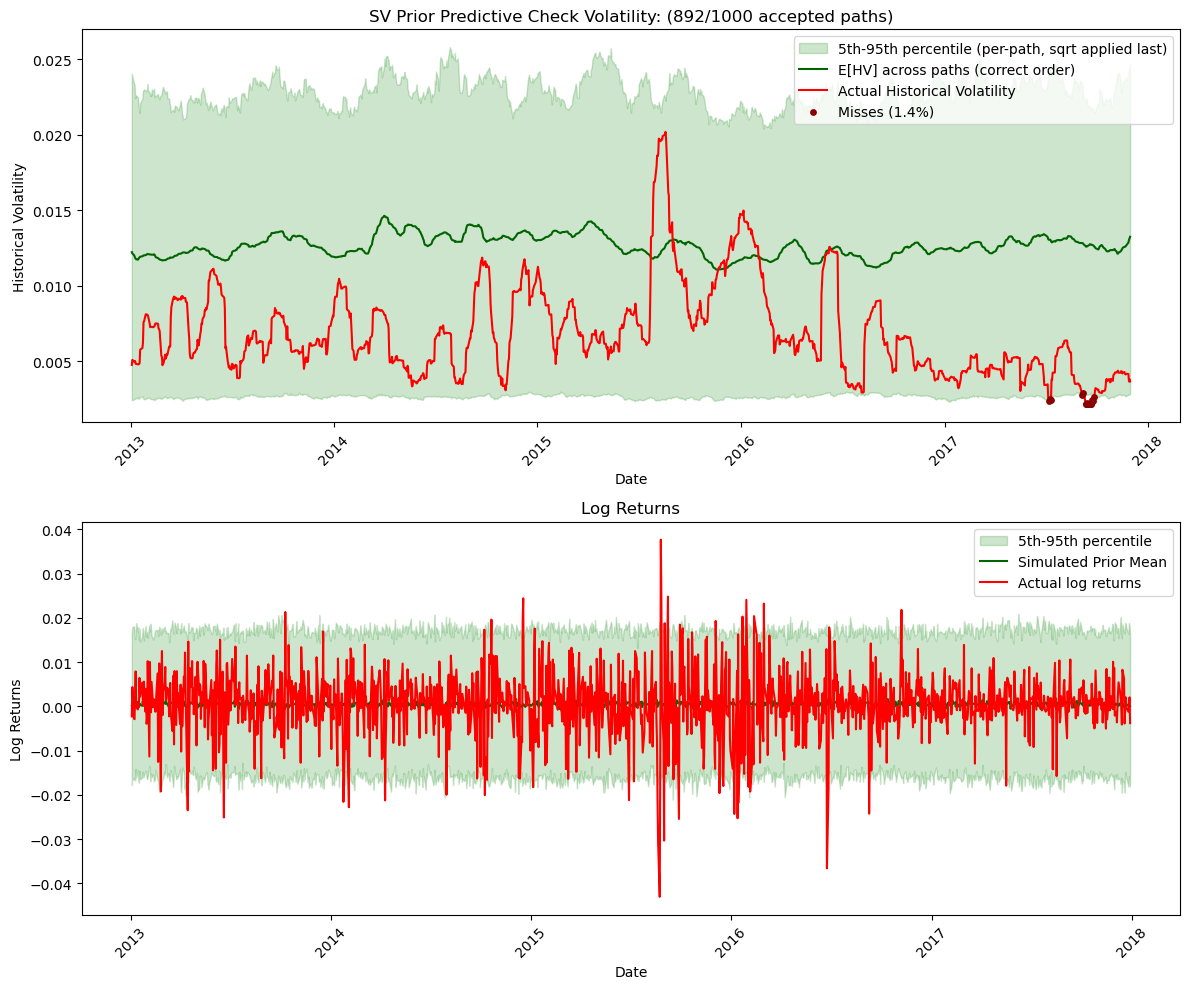

Miss rate (visual diagnostic only): 1.4%
Rejection rate indicates prior stationarity constraint tightness


In [84]:
vol_sv, rt_sv, valid_paths_sv = prior_predictive_simulate_sv(prior_returns_1d, mu_kf, mu_return)

results_prior_sv = prior_predictive_check(
    vol_sv, rt_sv, valid_paths_sv, prior_returns_1d, prior_dates, hv_prior,
    model_label="SV", color="green"
)

In [85]:
import numpy as np
from scipy import stats as scipy_stats

def particle_filter_sv(returns, mu, phi, sigma_eta, mu_return, N, ls2_init=None):
    T = len(returns)

    # Initialize particles from stationary distribution, unless a carried-forward state is
    # given (sequential refits warm-start from the previous window's true end state; the
    # regression fit has no prior window, so it always uses the default stationary init)
    if ls2_init is None:
        init_std = sigma_eta / np.sqrt(1 - phi**2)
        particles = np.random.normal(mu, init_std, N)
    else:
        particles = np.full(N, ls2_init)
    log_likelihood = 0.0
    filtered_means = []
    
    for t in range(T):
        # 1. Propagate — state equation
        particles = mu + phi*(particles - mu) + \
                    np.random.normal(0, sigma_eta, N)
        
        # 2. Reweight — observation equation
        # how likely is the return given the volatility estimate
        sigma_t  = np.sqrt(np.exp(particles))
        log_w     = scipy_stats.norm.logpdf(returns[t], loc=mu_return, scale=sigma_t)
        max_lw    = log_w.max()                          
        log_w    -= max_lw
        weights   = np.exp(log_w) # just likelihood (the previous 2 lines are only there for numerical reasons)
        weights  /= weights.sum()
        
        log_likelihood += max_lw + np.log(np.mean(np.exp(log_w)))   
        # 3. Resample — systematic resampling
        # eliminate particles with low weights, so create try and duplicate high weights and discard low weights
        # so all N particles have similar weight
        cumsum = np.cumsum(weights)
        u      = np.random.uniform(0, 1/N) + np.arange(N)/N # note the left term is a common increase to all the particles (not n distinct)
        idx    = np.searchsorted(cumsum, u) # this is the key part of the code, 
                                            # as particles with more weight cover more interval length
        particles = particles[idx]
        
        filtered_means.append(particles.mean())
    
    return np.array(filtered_means), log_likelihood, particles

### Particle Filter REgression

In [86]:
# ── Regression PMCMC ──────────────────────────────────────────────────
# MH logic with ability to increase/decrease accepts based on how close/far away model is to correct solution.
def pmcmc_regression(returns, n_mcmc=1000, N=500,
                     mu_init=None, phi_init=0.93,
                     sigma_eta_init=None, mu_return_init=None):
    '''If mu_init/sigma_eta_init/mu_return_init are None, caller must supply them explicitly —
    no longer silently defaults to notebook-level globals.'''
    if mu_init is None or sigma_eta_init is None or mu_return_init is None:
        raise ValueError("mu_init, sigma_eta_init, and mu_return_init must be provided explicitly.")

    theta_current = np.array([mu_init, phi_init, sigma_eta_init, mu_return_init])
    filtered_means_current, ll_current, _ = particle_filter_sv(returns, *theta_current, N=N)

    T = len(returns)
    samples    = np.zeros((n_mcmc, 4))
    ll_history = np.zeros(n_mcmc)
    filtered_means_history = np.zeros((n_mcmc, T))   # NEW: store the accepted path at every iteration
    accepted   = 0

    proposal_std   = np.array([0.2, 0.02, 0.05, 0.0002])
    target_rate    = 0.20
    adapt_interval = 50
    adapt_end      = 500
    scale_factor   = 0.85

    def log_prior(theta):
        mu_p, phi_p, sigma_eta_p, mu_ret_p = theta
        lp  = scipy_stats.norm.logpdf(mu_p,     mu_init,      1.0)
        lp += scipy_stats.beta.logpdf(phi_p,    7,          1)
        lp += scipy_stats.halfnorm.logpdf(sigma_eta_p, scale=0.5)
        lp += scipy_stats.norm.logpdf(mu_ret_p, mu_return_init,  0.001)
        return lp

    print("Running Regression PMCMC...")
    for i in range(n_mcmc):
        if i > 0 and i < adapt_end and i % adapt_interval == 0:
            current_rate = accepted / i
            if current_rate < target_rate:
                proposal_std *= scale_factor
            else:
                proposal_std /= scale_factor
            proposal_std = np.clip(proposal_std, 1e-4, 1.0)
            print(f"Step {i}: rate={current_rate:.2%}, proposal_std={proposal_std.round(4)}")
        elif i % 100 == 0:
            print(f"Step {i}/{n_mcmc}, acceptance rate: {accepted/(i+1) if i>0 else 0:.2%}")

        theta_proposed = theta_current + np.random.normal(0, proposal_std, 4)

        if np.abs(theta_proposed[1]) >= 1:
            samples[i] = theta_current; ll_history[i] = ll_current
            filtered_means_history[i] = filtered_means_current   # FIX: store current on rejection too
            continue
        if theta_proposed[2] <= 0:
            samples[i] = theta_current; ll_history[i] = ll_current
            filtered_means_history[i] = filtered_means_current
            continue

        filtered_means_proposed, ll_proposed, _ = particle_filter_sv(returns, *theta_proposed, N=N)

        log_alpha = (ll_proposed + log_prior(theta_proposed)) - (ll_current + log_prior(theta_current))

        if np.log(np.random.uniform()) < log_alpha:
            theta_current = theta_proposed
            ll_current    = ll_proposed
            filtered_means_current = filtered_means_proposed   # NEW: update on acceptance
            accepted     += 1

        samples[i]    = theta_current
        ll_history[i] = ll_current
        filtered_means_history[i] = filtered_means_current   # NEW: always store whatever is current

    print(f"Final acceptance rate: {accepted/n_mcmc:.2%}")
    return samples, ll_history, filtered_means_history


  


Running Regression PMCMC...
Step 0/3000, acceptance rate: 0.00%
Step 50: rate=24.00%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 100: rate=13.00%, proposal_std=[0.2    0.02   0.05   0.0002]
Step 150: rate=15.33%, proposal_std=[0.17   0.017  0.0425 0.0002]
Step 200: rate=18.00%, proposal_std=[1.445e-01 1.440e-02 3.610e-02 1.000e-04]
Step 250: rate=20.40%, proposal_std=[0.17   0.017  0.0425 0.0002]
Step 300: rate=22.33%, proposal_std=[0.2    0.02   0.05   0.0002]
Step 350: rate=24.00%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 400: rate=25.00%, proposal_std=[0.2768 0.0277 0.0692 0.0003]
Step 450: rate=24.22%, proposal_std=[3.257e-01 3.260e-02 8.140e-02 3.000e-04]
Step 500/3000, acceptance rate: 22.55%
Step 600/3000, acceptance rate: 20.47%
Step 700/3000, acceptance rate: 19.40%
Step 800/3000, acceptance rate: 18.73%
Step 900/3000, acceptance rate: 16.76%
Step 1000/3000, acceptance rate: 16.38%
Step 1100/3000, acceptance rate: 15.99%
Step 1200/3000, acce

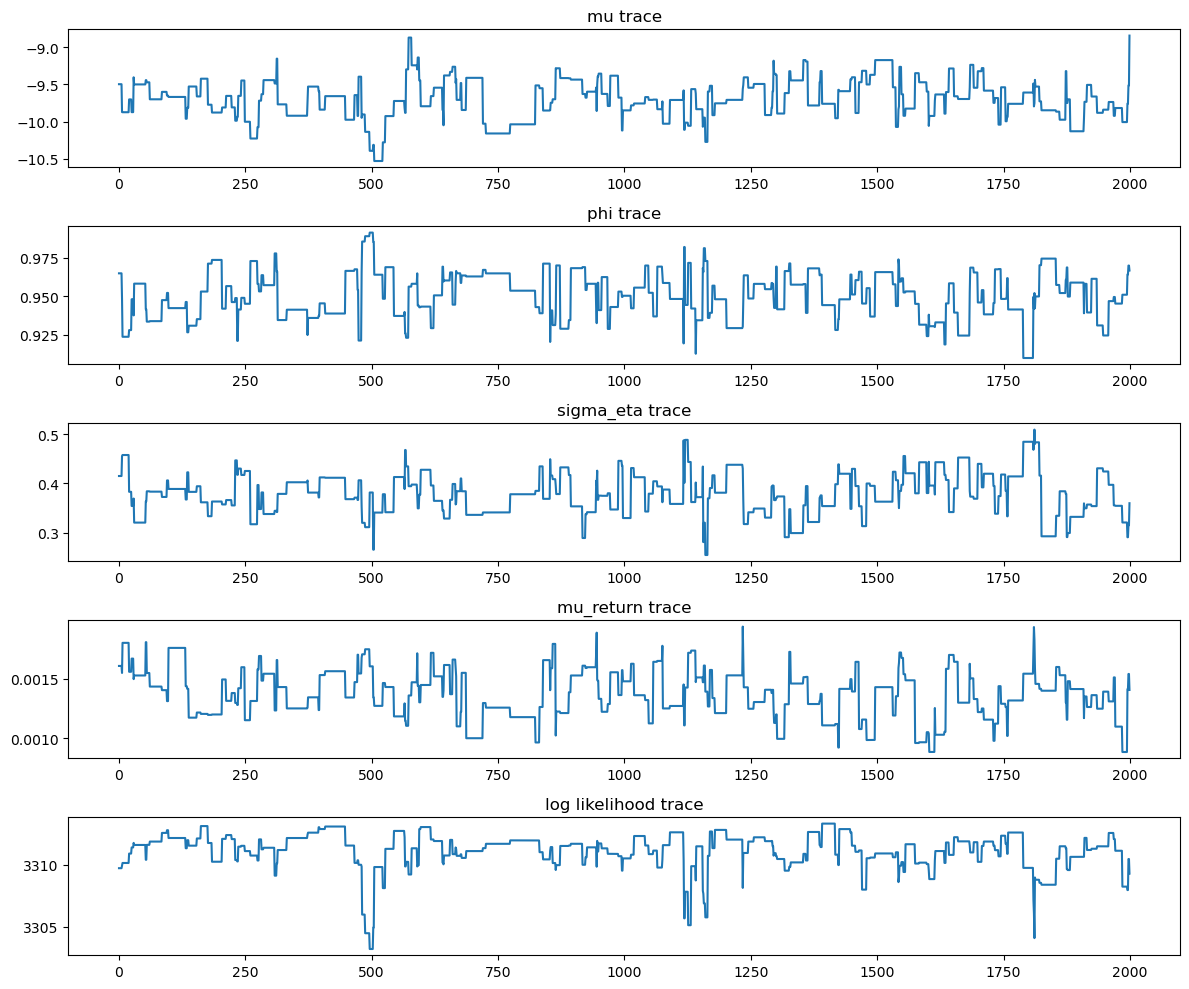

In [87]:
# Seeded for reproducibility -- covers pmcmc_regression's MCMC proposals + particle_filter_sv
np.random.seed(42)

samples_sv, ll_history, filtered_means_history = pmcmc_regression(
    regression_returns_1d,
    n_mcmc=3000,
    N=2000,
    mu_init=mu_kf,
    phi_init=0.875,
    sigma_eta_init=sigma_eta_kf,
    mu_return_init=mu_return
)

# Discard burn-in
burnin = 1000
samples_sv = samples_sv[burnin:]
ll_history_burnin = ll_history[burnin:]
filtered_means_history = filtered_means_history[burnin:]

sigma_posterior_sv = np.sqrt(np.exp(filtered_means_history))

# Results
mu_samples        = samples_sv[:, 0]
phi_samples       = samples_sv[:, 1]
sigma_eta_samples = samples_sv[:, 2]
mu_return_samples = samples_sv[:, 3]

print(f"\nPosterior means:")
print(f"mu:        {mu_samples.mean():.4f}")
print(f"phi:       {phi_samples.mean():.4f}")
print(f"sigma_eta: {sigma_eta_samples.mean():.4f}")
print(f"mu_return: {mu_return_samples.mean():.6f}")

# Plot traces
fig, axes = plt.subplots(5, 1, figsize=(12, 10))
axes[0].plot(mu_samples);        axes[0].set_title("mu trace")
axes[1].plot(phi_samples);       axes[1].set_title("phi trace")
axes[2].plot(sigma_eta_samples); axes[2].set_title("sigma_eta trace")
axes[3].plot(mu_return_samples); axes[3].set_title("mu_return trace")
axes[4].plot(ll_history_burnin); axes[4].set_title("log likelihood trace")
plt.tight_layout()
plt.show()


In [88]:
from pathlib import Path
Path("results/sv").mkdir(parents=True, exist_ok=True)

with open("results/sv/sv_regression_mcmc_raw.pkl", "wb") as f:
    pickle.dump({
        "samples_sv": samples_sv,
        "ll_history": ll_history_burnin,
        "sigma_posterior_sv": sigma_posterior_sv,
    }, f)
print("Saved raw SV regression MCMC output.")

Saved raw SV regression MCMC output.


In [89]:
with open("results/sv/sv_regression_mcmc_raw.pkl", "rb") as f:
    raw = pickle.load(f)
    samples_sv = raw["samples_sv"]
    ll_history = raw["ll_history"]
    sigma_posterior_sv = raw["sigma_posterior_sv"]

In [90]:
print(f"mu mean:   {mu_samples.mean():.4f}")
print(f"mu std:    {mu_samples.std():.4f}")
print(f"mu 5-95%:  [{np.percentile(mu_samples,5):.4f}, {np.percentile(mu_samples,95):.4f}]")
print(f"mu_kf:     {mu_kf:.4f}")

mu mean:   -9.7006
mu std:    0.2573
mu 5-95%:  [-10.1362, -9.2868]
mu_kf:     -9.8310


ll std after burnin: 1.4325


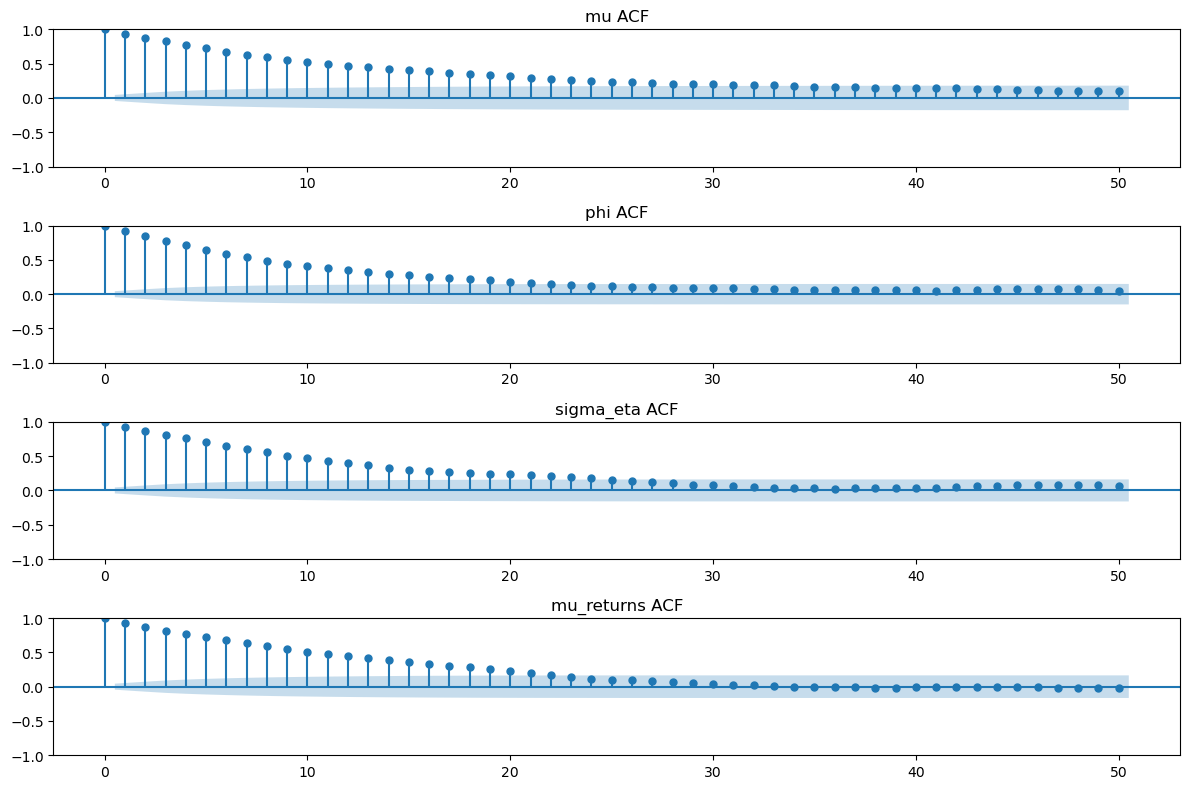

In [91]:
ll_after_burnin = ll_history
print(f"ll std after burnin: {ll_after_burnin.std():.4f}")

# Check ACF quickly
from statsmodels.graphics.tsaplots import plot_acf
fig, axes = plt.subplots(4, 1, figsize=(12, 8))
plot_acf(mu_samples, lags=50, ax=axes[0], title="mu ACF")
plot_acf(phi_samples, lags=50, ax=axes[1], title="phi ACF")
plot_acf(sigma_eta_samples, lags=50, ax=axes[2], title="sigma_eta ACF")
plot_acf(mu_return_samples, lags=50, ax=axes[3], title="mu_returns ACF")
plt.tight_layout()
plt.show()

In [92]:
# Seeded for reproducibility -- covers hv_coverage_posterior's measurement-noise injection (SV regression, 90% CI)
np.random.seed(42)

# ── QLIKE / RV Coverage: Method 2 (posterior-averaged mean) ──
forecast_regression_sv_series = pd.Series(
    sigma_to_hv_correct(sigma_posterior_sv, h=21),
    index=regression_returns.index
).dropna()

forecast_regression_sv, actual_regression_sv, dates_regression_sv = align_series(
    forecast_regression_sv_series, hv_regression
)

ql_regression_sv = qlike(forecast_regression_sv, actual_regression_sv)
print(f"QLIKE (SV regression): mean = {ql_regression_sv.mean():.4f}")

# ── RV Coverage: combined posterior spread + log-normal noise (Order A) ──
sigma_eta_sv, _ = hv_coverage(forecast_regression_sv, actual_regression_sv)

hv_per_draw_regression_sv = hv_per_draw_windowed(sigma_posterior_sv, h=21)

hv_per_draw_regression_sv_df = pd.DataFrame(
    hv_per_draw_regression_sv.T, index=regression_returns.index
).loc[dates_regression_sv]
hv_per_draw_regression_sv_aligned = hv_per_draw_regression_sv_df.values.T

lower_90_sv, upper_90_sv, inside_90_sv = hv_coverage_posterior(
    hv_per_draw_regression_sv_aligned, actual_regression_sv, sigma_eta_sv, level=90
)

coverage_90_sv = np.mean(inside_90_sv)
print(f"SV — 90% CI coverage (posterior + noise): {coverage_90_sv:.2%}")

QLIKE (SV regression): mean = 0.0702
SV — 90% CI coverage (posterior + noise): 90.89%


SV — Pre-COVID QLIKE:  0.0687
SV — COVID QLIKE:      0.1974
SV — Post-COVID QLIKE: 0.0525
At 90% CI coverage
SV — Pre-COVID coverage:  90.80%
SV — COVID coverage:      66.67%
SV — Post-COVID coverage: 94.78%


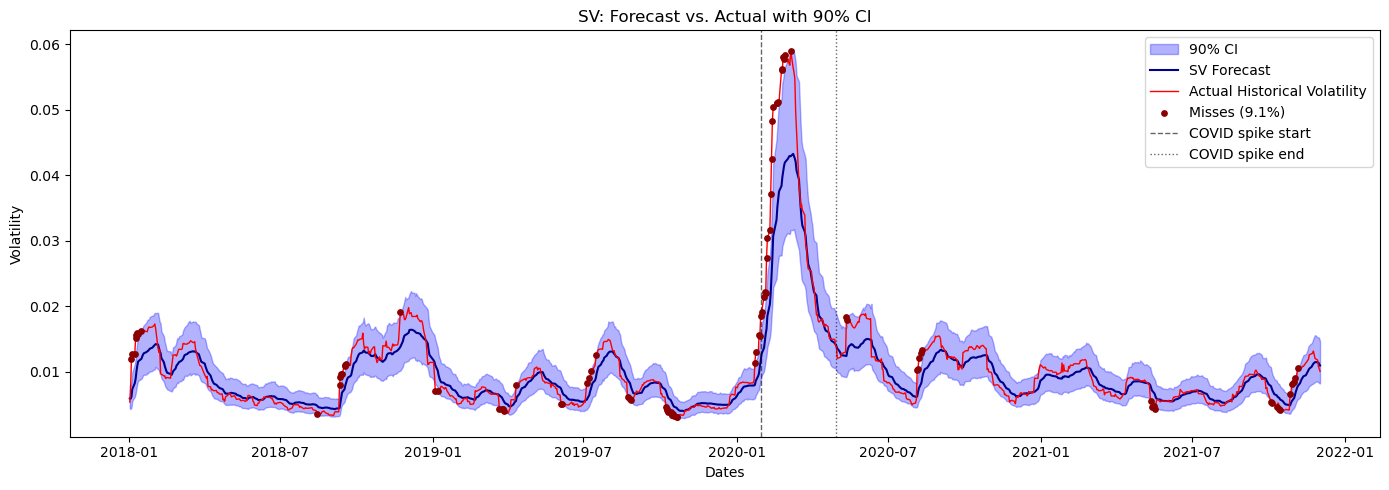

In [93]:
# ── QLIKE COVID breakdown ──
qlike_breakdown_sv = covid_breakdown(
    forecast_regression_sv, actual_regression_sv, dates_regression_sv,
    covid_start_date, covid_end_date, qlike
)
print_covid_breakdown(qlike_breakdown_sv, label="SV", metric_name="QLIKE")

# ── COVID sub-period breakdown — RV Coverage (90% CI) ──
covid_coverage_sv = hv_coverage_covid_breakdown(
    inside_90_sv, dates_regression_sv, covid_start_date, covid_end_date
)
print_hv_coverage_covid(covid_coverage_sv, label="SV")

# ── Plot with COVID vlines ──
plot_hv_coverage(
    forecast_regression_sv, actual_regression_sv, dates_regression_sv,
    lower_90_sv, upper_90_sv, inside_90_sv,
    level=90, label="SV",
    boundary_dates=[covid_start_date, covid_end_date],
    boundary_labels=['COVID spike start', 'COVID spike end'],
    boundary_styles=['--', ':']
)

In [94]:
sigma_posterior_sv_df = pd.DataFrame(
    sigma_posterior_sv.T,
    index=regression_returns.index
).dropna()

common_dates_pit_sv = sigma_posterior_sv_df.index.intersection(regression_returns.index)
sigma_posterior_sv_pit = sigma_posterior_sv_df.loc[common_dates_pit_sv].values.T
returns_regression_sv_pit = regression_returns.loc[common_dates_pit_sv].values.flatten()
dates_regression_sv_pit = common_dates_pit_sv

In [95]:
# Seeded for reproducibility -- covers hv_coverage_posterior_multilevel's measurement-noise injection (SV regression, multilevel CI)
np.random.seed(42)

hv_coverage_regression_sv = hv_coverage_posterior_multilevel(
    hv_per_draw_regression_sv_aligned, actual_regression_sv, sigma_eta_sv
)
print_hv_coverage_posterior(sigma_eta_sv, hv_coverage_regression_sv, label="SV")

SV — Measurement noise std: 0.1782
Coverage at different CI levels (posterior + noise):
----------------------------------------
50% CI coverage: 50.91%
60% CI coverage: 61.74%
70% CI coverage: 72.98%
80% CI coverage: 83.10%
85% CI coverage: 86.74%
90% CI coverage: 90.89%
95% CI coverage: 94.74%
99% CI coverage: 98.68%


SV (posterior-averaged PIT) — KS statistic: 0.0472
SV (posterior-averaged PIT) — p-value: 0.0219
SV (posterior-averaged PIT) — Reject null: model is not well calibrated


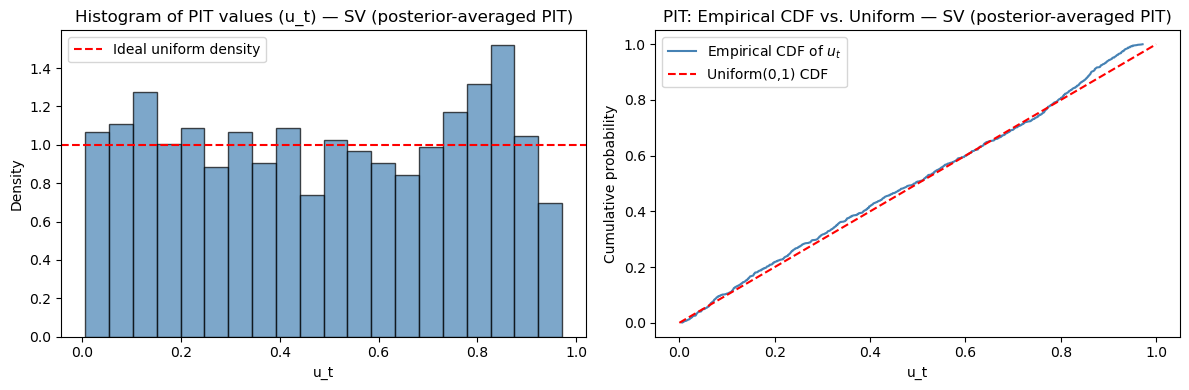

In [96]:
# ── Run PIT using Method 1 (posterior-averaged), Gaussian (not Student-t) ──
u_t_regression_sv, ks_stat_regression_sv, p_value_regression_sv = compute_pit_posterior(
    returns_regression_sv_pit, sigma_posterior_sv_pit, mu_return_samples, dist='normal'
)
print_pit_result(ks_stat_regression_sv, p_value_regression_sv, label="SV (posterior-averaged PIT)")
plot_pit(u_t_regression_sv, label="SV (posterior-averaged PIT)")

Ljung-Box test on z_t (level) — SV:
      lb_stat  lb_pvalue
1    0.850361   0.356450
5    2.940400   0.709174
10  14.127385   0.167260

Ljung-Box test on z_t^2 (squared, ARCH-LM style) — SV:
      lb_stat  lb_pvalue
1    0.294995   0.587037
5   11.403293   0.043945
10  16.591718   0.083901


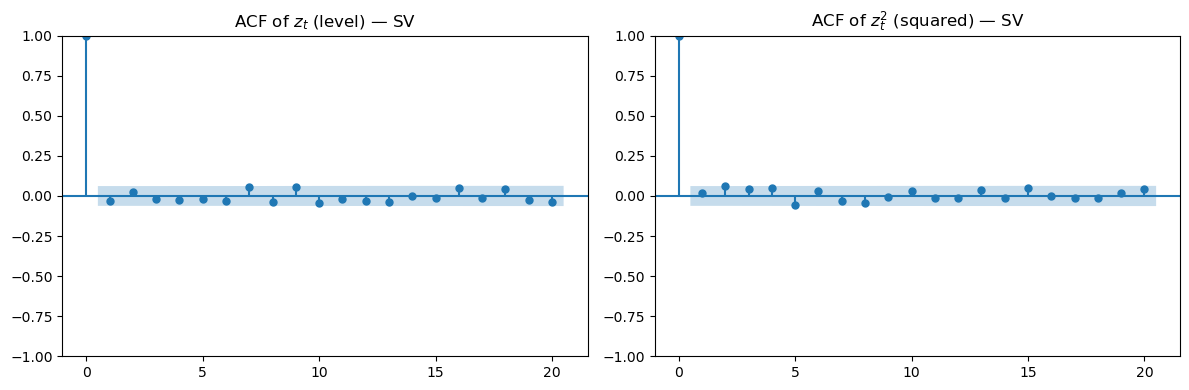

Engle-Ng Sign-Bias Test — SV:
                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     17.70
Date:                Fri, 07 Aug 2026   Prob (F-statistic):           2.82e-05
Time:                        21:29:14   Log-Likelihood:                -1398.0
No. Observations:                1007   AIC:                             2800.
Df Residuals:                    1005   BIC:                             2810.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8631 

In [97]:
z_t_regression_sv = compute_z(u_t_regression_sv, dates_regression_sv_pit)

lb_level_regression_sv, lb_sq_regression_sv = ljung_box_tests(z_t_regression_sv)
print_ljung_box(lb_level_regression_sv, lb_sq_regression_sv, label="SV")
plot_acf_diagnostics(z_t_regression_sv, label="SV")

sign_bias_model_regression_sv = sign_bias_test(
    z_t_regression_sv, returns_regression_sv_pit, dates_regression_sv_pit
)
print_sign_bias(sign_bias_model_regression_sv, label="SV")

### Sequential Stochastic Volatility

This follows the same process as EGARCH 

In [98]:
# sigma_posterior_sv already computed via sqrt(exp(filtered_means_history))
ls2_carry_sv = filtered_means_history[:, -1]   # each draw's own end-of-regression log-variance state

target_S_sv = 700   # matching n_mcmc=1000, seq_burnin=300 for each window's refit
if samples_sv.shape[0] != target_S_sv:
    idx_sv = np.random.choice(samples_sv.shape[0], size=target_S_sv, replace=False)
    samples_w_sv = samples_sv[idx_sv]
    ls2_current_seq_sv = ls2_carry_sv[idx_sv]   # same indices, so draws stay correctly paired
else:
    samples_w_sv = samples_sv.copy()
    ls2_current_seq_sv = ls2_carry_sv.copy()


In [99]:
def forward_simulate_sv_window(samples_prior, ls2_start_per_draw, T_w):
    '''Forward-simulate T_w days using each posterior draw's own parameters + own carried state.'''
    mu_s, phi_s, sigma_eta_s, mu_return_s = (
        samples_prior[:, 0], samples_prior[:, 1], samples_prior[:, 2], samples_prior[:, 3]
    )
    _, sigma_paths = simulate_sv_vectorized(mu_s, phi_s, sigma_eta_s, mu_return_s, T_w, ls2_init=ls2_start_per_draw)
    return sigma_paths


def particle_filter_sv_predictive(window_returns, mu, phi, sigma_eta, mu_return, N, ls2_init):
    '''Single-draw particle filter seeded from a carried-forward state, for the t,t+1 forecast --
    unlike particle_filter_sv (used by the refit), which always reinitializes from the stationary
    distribution. Returns predictive_ls2 (T,): the state entering each day, captured from the
    PRE-reweight/resample particle cloud -- informed by returns[:t] only, never returns[t] itself,
    exactly like EGARCH's filtered_sigma. Safe for one-step-ahead PIT / forecast anchoring.'''
    T = len(window_returns)
    particles = np.full(N, ls2_init)
    predictive_ls2 = np.zeros(T)

    for t in range(T):
        particles = mu + phi*(particles - mu) + np.random.normal(0, sigma_eta, N)
        predictive_ls2[t] = particles.mean()

        sigma_t = np.sqrt(np.exp(particles))
        log_w   = scipy_stats.norm.logpdf(window_returns[t], loc=mu_return, scale=sigma_t)
        max_lw  = log_w.max()
        log_w  -= max_lw
        weights = np.exp(log_w)
        weights /= weights.sum()

        cumsum = np.cumsum(weights)
        u      = np.random.uniform(0, 1/N) + np.arange(N)/N
        idx    = np.searchsorted(cumsum, u)
        particles = particles[idx]

    return predictive_ls2


def filtered_pass_sv_window(samples_prior, ls2_start_per_draw, window_returns, N=1000):
    '''t,t+1-style causal filter for SV, across all posterior draws. Unlike EGARCH's deterministic
    recursion, SV's state has its own noise and can't be backed out from returns alone -- each draw
    needs its own genuine particle filter (not vectorizable across draws, hence the loop over S).
    Returns filtered_ls2 (S, T_w): entering log-variance state for each day, per draw.'''
    S = samples_prior.shape[0]
    mu_s, phi_s, sigma_eta_s, mu_return_s = (
        samples_prior[:, 0], samples_prior[:, 1], samples_prior[:, 2], samples_prior[:, 3]
    )
    T_w = len(window_returns)
    filtered_ls2 = np.zeros((S, T_w))
    for s in range(S):
        filtered_ls2[s] = particle_filter_sv_predictive(
            window_returns, mu_s[s], phi_s[s], sigma_eta_s[s], mu_return_s[s], N,
            ls2_init=ls2_start_per_draw[s]
        )
    return filtered_ls2


def filtered_forecast_sv_window(samples_prior, ls2_start_per_draw, window_returns, N=1000, h=21):
    '''t,t+1-style forecast for SV. Filters day-by-day through real returns (filtered_pass_sv_window),
    then blind-forward-simulates h days from each day's filtered state -- future returns are genuinely
    unknown at evaluation time, so the h-day leg still has to be blind, vectorized across draws via the
    existing forward_simulate_sv_window.
    Returns (filtered_ls2, forecast_hv, hv_per_draw) -- same shapes/roles as the EGARCH version.'''
    filtered_ls2 = filtered_pass_sv_window(samples_prior, ls2_start_per_draw, window_returns, N=N)
    S = filtered_ls2.shape[0]
    T_w = len(window_returns)
    forecast_hv = np.full(T_w, np.nan)
    hv_per_draw = np.full((S, T_w), np.nan)
    for t in range(T_w):
        sim_paths_t = forward_simulate_sv_window(samples_prior, filtered_ls2[:, t], h)
        mean_sigma_sq_per_step = np.mean(sim_paths_t**2, axis=0)
        forecast_hv[t] = np.sqrt(mean_sigma_sq_per_step.mean())
        hv_per_draw[:, t] = np.sqrt(np.mean(sim_paths_t**2, axis=1))
    return filtered_ls2, forecast_hv, hv_per_draw

In [100]:
def fit_halfnorm_scale(samples):
    '''Method-of-moments fit of a half-Normal scale parameter to posterior samples.'''
    # For half-Normal, E[X] = scale * sqrt(2/pi)  =>  scale = mean / sqrt(2/pi)
    return float(np.array(samples).mean() / np.sqrt(2/np.pi))

In [130]:
def pmcmc_refit(returns, n_mcmc=1000, N=500,
                     mu_init=None, phi_init=None,
                     sigma_eta_init=None, mu_return_init=None,
                     mu_prior_mu=None, mu_prior_std=1.0,
                     phi_prior_a=7, phi_prior_b=1,
                     sigma_eta_prior_scale=0.5,
                     mu_return_prior_mu=None, mu_return_prior_std=0.001,
                     ls2_init=None):

    mu_prior_mu        = mu_prior_mu or mu_init
    mu_return_prior_mu = mu_return_prior_mu or mu_return_init

    theta_current = np.array([mu_init, phi_init, sigma_eta_init, mu_return_init])
    filtered_means_current, ll_current, _ = particle_filter_sv(returns, *theta_current, N=N, ls2_init=ls2_init)   # FIX: capture; warm-start from carried state

    T = len(returns)
    samples    = np.zeros((n_mcmc, 4))
    ll_history = np.zeros(n_mcmc)
    filtered_means_history = np.zeros((n_mcmc, T))   # FIX: new storage array
    accepted   = 0

    proposal_std   = np.array([0.2, 0.02, 0.05, 0.0002])
    target_rate    = 0.20
    adapt_interval = 50
    adapt_end      = 500
    scale_factor   = 0.85

    def log_prior(theta):
        mu_p, phi_p, sigma_eta_p, mu_ret_p = theta
        lp  = scipy_stats.norm.logpdf(mu_p,     mu_prior_mu,        mu_prior_std)
        lp += scipy_stats.beta.logpdf(phi_p,    phi_prior_a,        phi_prior_b)
        lp += scipy_stats.halfnorm.logpdf(sigma_eta_p, scale=sigma_eta_prior_scale)
        lp += scipy_stats.norm.logpdf(mu_ret_p, mu_return_prior_mu, mu_return_prior_std)
        return lp

    print("Running Sequential PMCMC...")
    for i in range(n_mcmc):
        if i > 0 and i < adapt_end and i % adapt_interval == 0:
            current_rate = accepted / i
            if current_rate < target_rate:
                proposal_std *= scale_factor
            else:
                proposal_std /= scale_factor
            proposal_std = np.clip(proposal_std, 1e-4, 1.0)
            print(f"Step {i}: rate={current_rate:.2%}, proposal_std={proposal_std.round(4)}")
        elif i % 100 == 0:
            print(f"Step {i}/{n_mcmc}, acceptance rate: {accepted/(i+1) if i>0 else 0:.2%}")

        theta_proposed = theta_current + np.random.normal(0, proposal_std, 4)

        if np.abs(theta_proposed[1]) >= 1 or theta_proposed[2] <= 0:
            samples[i] = theta_current; ll_history[i] = ll_current
            filtered_means_history[i] = filtered_means_current   # FIX: store on rejection
            continue

        filtered_means_proposed, ll_proposed, _ = particle_filter_sv(returns, *theta_proposed, N=N, ls2_init=ls2_init)

        log_alpha = (ll_proposed + log_prior(theta_proposed)) - (ll_current + log_prior(theta_current))

        if np.log(np.random.uniform()) < log_alpha:
            theta_current = theta_proposed
            ll_current    = ll_proposed
            filtered_means_current = filtered_means_proposed   # FIX: update on acceptance
            accepted     += 1

        samples[i]    = theta_current
        ll_history[i] = ll_current
        filtered_means_history[i] = filtered_means_current   # FIX: always store current

    print(f"Final acceptance rate: {accepted/n_mcmc:.2%}")
    return samples, ll_history, filtered_means_history   # FIX: return all three

In [ ]:
# Seeded for reproducibility -- covers pmcmc_refit, forward_simulate_sv_window, particle_filter_sv_predictive
np.random.seed(42)

all_pit_values_sv_seq   = []
all_returns_obs_sv_seq   = []
all_window_stats_sv_seq  = []
all_forecast_sv_seq      = []
all_hv_per_draw_sv_seq   = []
all_samples_sv_by_window = []

# ── t,t+1 (filtered) forecast -- parallel storage, existing arrays above untouched ──
all_forecast_sv_seq_filtered    = []
all_hv_per_draw_sv_seq_filtered = []
all_pit_values_sv_seq_filtered  = []

# Full posterior for the filtered forecast's particle-filter pass -- validated correct at a
# 200-draw smoke test first; every window's samples_w_sv consistently holds 700 draws.
sv_filtered_test_S = 700

for i in range(len(window_boundaries) - 1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    window_returns = full_returns[window_start:window_end].values.flatten().astype('float64')
    T_w = len(window_returns)

    # ── Forecast generation (simulated shocks only) ──
    # Simulate h-1 extra "overhang" days past the window so the rolling h-day HV window has
    # enough runway to produce a real (non-NaN) forecast for every day, including the last h-1 --
    # those overhang days are blind-simulated continuation, discarded afterward.
    h_horizon = 21
    sim_paths_sv_ext = forward_simulate_sv_window(samples_w_sv, ls2_current_seq_sv, T_w + h_horizon - 1)
    sim_paths_sv = sim_paths_sv_ext[:, :T_w]   # exactly the window's real days -- PIT below is unaffected

    forecast_window_sv = sigma_to_hv_correct(sim_paths_sv_ext, h=h_horizon)[:T_w]
    all_forecast_sv_seq.append(forecast_window_sv)

    hv_per_draw_window_sv = np.sqrt(sigma_sq_windowed_per_path(sim_paths_sv_ext, h=h_horizon))[:, :T_w]
    all_hv_per_draw_sv_seq.append(hv_per_draw_window_sv)

    # ── PIT from the forecast, Method 1 (Gaussian) ──
    S = sim_paths_sv.shape[0]
    mu_return_s = samples_w_sv[:, 3]
    u_per_draw = np.zeros((S, T_w))
    for s in range(S):
        u_per_draw[s] = scipy_stats.norm.cdf(window_returns, loc=mu_return_s[s], scale=sim_paths_sv[s])
    pit_w_sv = np.mean(u_per_draw, axis=0)

    all_pit_values_sv_seq.extend(pit_w_sv)
    all_returns_obs_sv_seq.extend(window_returns)

    # ── Step 0b: t,t+1-style forecast -- causal day-by-day filtering through REAL returns ──
    # Unlike the blind forecast above, each day's state here is a genuine particle-filter update
    # informed by yesterday's real return. The h-day HV leg still blind-simulates forward, since
    # future returns are genuinely unknown at evaluation time.
    # NOTE: subsampled to sv_filtered_test_S draws for now -- smoke test before the full-posterior run.
    if samples_w_sv.shape[0] > sv_filtered_test_S:
        test_idx_sv = np.random.choice(samples_w_sv.shape[0], size=sv_filtered_test_S, replace=False)
        samples_w_sv_test = samples_w_sv[test_idx_sv]
        ls2_current_seq_sv_test = ls2_current_seq_sv[test_idx_sv]
    else:
        samples_w_sv_test = samples_w_sv
        ls2_current_seq_sv_test = ls2_current_seq_sv

    filtered_ls2_sv, forecast_window_sv_filtered, hv_per_draw_window_sv_filtered = \
        filtered_forecast_sv_window(samples_w_sv_test, ls2_current_seq_sv_test, window_returns, N=1000, h=21)
    all_forecast_sv_seq_filtered.append(forecast_window_sv_filtered)
    all_hv_per_draw_sv_seq_filtered.append(hv_per_draw_window_sv_filtered)

    S_filt_sv = filtered_ls2_sv.shape[0]
    mu_return_s_filt = samples_w_sv_test[:, 3]
    filtered_sigma_sv = np.sqrt(np.exp(filtered_ls2_sv))
    u_per_draw_filt_sv = np.zeros((S_filt_sv, T_w))
    for s in range(S_filt_sv):
        u_per_draw_filt_sv[s] = scipy_stats.norm.cdf(window_returns, loc=mu_return_s_filt[s], scale=filtered_sigma_sv[s])
    pit_w_sv_filtered = np.mean(u_per_draw_filt_sv, axis=0)
    all_pit_values_sv_seq_filtered.extend(pit_w_sv_filtered)

    # ── Extract priors from previous posterior ──
    mu_prior_mu   = float(samples_w_sv[:, 0].mean())
    mu_prior_std  = max(float(samples_w_sv[:, 0].std()), 0.1)
    beta_a, beta_b = fit_beta_params(samples_w_sv[:, 1])
    sigma_eta_prior_scale = fit_halfnorm_scale(samples_w_sv[:, 2])
    mu_return_prior_mu  = float(samples_w_sv[:, 3].mean())
    mu_return_prior_std = max(float(samples_w_sv[:, 3].std()), 0.0001)

    # ── Refit via the standalone, fixed pmcmc_refit ──
    # FIX: warm-start every particle filter call in this window's refit from the previous
    # window's true carried-forward state, instead of always reinitializing from each
    # proposed theta's own stationary distribution (which biased early-window likelihood).
    ls2_seed_scalar_sv = float(np.mean(ls2_current_seq_sv))
    print(f"Refitting window {i+1} on {T_w} observations...")
    samples_out, ll_hist_out, filtered_hist = pmcmc_refit(
        window_returns, n_mcmc=1000, N=1000,
        mu_init=mu_prior_mu, phi_init=float(samples_w_sv[:,1].mean()),
        sigma_eta_init=sigma_eta_prior_scale, mu_return_init=mu_return_prior_mu,
        mu_prior_mu=mu_prior_mu, mu_prior_std=mu_prior_std,
        phi_prior_a=beta_a, phi_prior_b=beta_b,
        sigma_eta_prior_scale=sigma_eta_prior_scale,
        mu_return_prior_mu=mu_return_prior_mu, mu_return_prior_std=mu_return_prior_std,
        ls2_init=ls2_seed_scalar_sv
    )

    seq_burnin = 300
    samples_w_sv = samples_out[seq_burnin:]
    filtered_hist = filtered_hist[seq_burnin:]

    all_samples_sv_by_window.append(samples_w_sv.copy())

    # ── Carry forward this window's own new end state ──
    ls2_current_seq_sv = filtered_hist[:, -1]

    all_window_stats_sv_seq.append({
        "window": i+1, "start": str(window_start.date()), "end": str(window_end.date()),
        "n_obs": T_w,
        "pit_coverage": float(np.mean((pit_w_sv >= 0.05) & (pit_w_sv <= 0.95))),
        "phi": float(samples_w_sv[:, 1].mean()),
        "sigma_eta": float(samples_w_sv[:, 2].mean()),
    })
    print(f"Window {i+1} PIT coverage: {all_window_stats_sv_seq[-1]['pit_coverage']:.2%}")

all_pit_values_sv_seq  = np.array(all_pit_values_sv_seq)
all_returns_obs_sv_seq = np.array(all_returns_obs_sv_seq)
forecast_sequential_sv = np.concatenate(all_forecast_sv_seq)

# ── t,t+1 (filtered) final arrays ──
all_pit_values_sv_seq_filtered = np.array(all_pit_values_sv_seq_filtered)
forecast_sequential_sv_filtered = np.concatenate(all_forecast_sv_seq_filtered)

In [103]:
from pathlib import Path
import pickle

Path("results/sv").mkdir(parents=True, exist_ok=True)

sequential_mcmc_sv = {
    "forecast_sequential":       forecast_sequential_sv,
    "pit_values":                all_pit_values_sv_seq,
    "returns_observed":          all_returns_obs_sv_seq,
    "window_stats":              all_window_stats_sv_seq,
    "final_samples_sv":          samples_w_sv,                    # last window's posterior
    "all_forecast_by_window":    all_forecast_sv_seq,
    "all_hv_per_draw_by_window": all_hv_per_draw_sv_seq,
    "all_samples_sv_by_window":  all_samples_sv_by_window,        # every window's posterior, avoids future re-runs
    "forecast_sequential_filtered":    forecast_sequential_sv_filtered,
    "pit_values_filtered":             all_pit_values_sv_seq_filtered,
    "all_forecast_by_window_filtered": all_forecast_sv_seq_filtered,
    "all_hv_per_draw_by_window_filtered": all_hv_per_draw_sv_seq_filtered,
}

with open("results/sv/sv_sequential_mcmc.pkl", "wb") as f:
    pickle.dump(sequential_mcmc_sv, f)

print("Saved sequential SV MCMC results.")

Saved sequential SV MCMC results.


In [104]:
with open("results/sv/sv_sequential_mcmc.pkl", "rb") as f:
    sequential_mcmc_sv = pickle.load(f)
    forecast_sequential_sv     = sequential_mcmc_sv["forecast_sequential"]
    all_pit_values_sv_seq      = sequential_mcmc_sv["pit_values"]
    all_returns_obs_sv_seq     = sequential_mcmc_sv["returns_observed"]
    all_window_stats_sv_seq    = sequential_mcmc_sv["window_stats"]
    all_forecast_sv_seq        = sequential_mcmc_sv["all_forecast_by_window"]
    all_hv_per_draw_sv_seq     = sequential_mcmc_sv["all_hv_per_draw_by_window"]
    all_samples_sv_by_window = sequential_mcmc_sv["all_samples_sv_by_window"]
    forecast_sequential_sv_filtered    = sequential_mcmc_sv["forecast_sequential_filtered"]
    all_pit_values_sv_seq_filtered     = sequential_mcmc_sv["pit_values_filtered"]
    all_forecast_sv_seq_filtered       = sequential_mcmc_sv["all_forecast_by_window_filtered"]
    all_hv_per_draw_sv_seq_filtered    = sequential_mcmc_sv["all_hv_per_draw_by_window_filtered"]

In [105]:
forecast_sequential_sv_pieces = []
forecast_sequential_sv_dates = []

for i in range(len(window_boundaries) - 1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    window_dates = full_returns[window_start:window_end].index
    piece = all_forecast_sv_seq[i]

    assert len(piece) == len(window_dates), f"Window {i+1}: forecast length {len(piece)} != date length {len(window_dates)}"

    forecast_sequential_sv_pieces.append(piece)
    forecast_sequential_sv_dates.append(window_dates)

forecast_sequential_sv_series = pd.Series(
    np.concatenate(forecast_sequential_sv_pieces),
    index=np.concatenate(forecast_sequential_sv_dates)
).dropna()

# ── t,t+1 (filtered) version, same window/date alignment ──
forecast_sequential_sv_filtered_pieces = []

for i in range(len(window_boundaries) - 1):
    piece_filtered = all_forecast_sv_seq_filtered[i]
    window_dates_i = forecast_sequential_sv_dates[i]
    assert len(piece_filtered) == len(window_dates_i), \
        f"Window {i+1}: filtered forecast length {len(piece_filtered)} != date length {len(window_dates_i)}"
    forecast_sequential_sv_filtered_pieces.append(piece_filtered)

forecast_sequential_sv_filtered_series = pd.Series(
    np.concatenate(forecast_sequential_sv_filtered_pieces),
    index=np.concatenate(forecast_sequential_sv_dates)
).dropna()

In [106]:
forecast_sequential_sv, actual_sequential_sv, dates_sequential_sv = align_series(
    forecast_sequential_sv_series, hv_sequential
)

In [107]:
ql_sequential_sv = qlike(forecast_sequential_sv, actual_sequential_sv)

qlike_windows_sv = metric_by_period(forecast_sequential_sv, actual_sequential_sv,
                                      dates_sequential_sv, window_boundaries, qlike)
print_metric_by_window(qlike_windows_sv, label="SV", metric_name="QLIKE")

QLIKE by window — SV:
  period_1 (2022-01-01 to 2022-07-01): 0.2161
  period_2 (2022-07-01 to 2023-01-01): 0.1771
  period_3 (2023-01-01 to 2023-07-01): 0.2601
  period_4 (2023-07-01 to 2024-01-01): 0.1925
  period_5 (2024-01-01 to 2024-07-01): 0.1955
  period_6 (2024-07-01 to 2025-01-01): 0.2965
  period_7 (2025-01-01 to 2025-07-01): 1.1960
  period_8 (2025-07-01 to 2026-01-01): 0.4060


In [108]:
# ── t,t+1 (filtered) version, same alignment machinery as the blind forecast above ──
forecast_sequential_sv_filtered, actual_sequential_sv_filtered, dates_sequential_sv_filtered = align_series(
    forecast_sequential_sv_filtered_series, hv_sequential
)

In [109]:
ql_sequential_sv_filtered = qlike(forecast_sequential_sv_filtered, actual_sequential_sv_filtered)
print(f"QLIKE (SV sequential, filtered t,t+1): mean = {ql_sequential_sv_filtered.mean():.4f}")
print(f"QLIKE (SV sequential, blind t+126):    mean = {ql_sequential_sv.mean():.4f}")

qlike_windows_sv_filtered = metric_by_period(forecast_sequential_sv_filtered, actual_sequential_sv_filtered,
                                                dates_sequential_sv_filtered, window_boundaries, qlike)
print_metric_by_window(qlike_windows_sv_filtered, label="SV (filtered t,t+1)", metric_name="QLIKE")

QLIKE (SV sequential, filtered t,t+1): mean = 0.2703
QLIKE (SV sequential, blind t+126):    mean = 0.3639
QLIKE by window — SV (filtered t,t+1):
  period_1 (2022-01-01 to 2022-07-01): 0.1822
  period_2 (2022-07-01 to 2023-01-01): 0.0914
  period_3 (2023-01-01 to 2023-07-01): 0.1459
  period_4 (2023-07-01 to 2024-01-01): 0.1305
  period_5 (2024-01-01 to 2024-07-01): 0.1422
  period_6 (2024-07-01 to 2025-01-01): 0.2979
  period_7 (2025-01-01 to 2025-07-01): 0.9344
  period_8 (2025-07-01 to 2026-01-01): 0.2519


In [110]:
# Seeded for reproducibility -- covers hv_coverage_sequential_posterior's measurement-noise injection (SV sequential CI)
np.random.seed(42)

hv_per_draw_sequential_sv_full = np.concatenate(all_hv_per_draw_sv_seq, axis=1)

hv_per_draw_sequential_sv_df = pd.DataFrame(
    hv_per_draw_sequential_sv_full.T,
    index=np.concatenate(forecast_sequential_sv_dates)
).dropna()

hv_per_draw_sequential_sv_aligned = hv_per_draw_sequential_sv_df.loc[dates_sequential_sv].values.T

sigma_eta_windows_sv = sigma_eta_sequential(
    forecast_sequential_sv, actual_sequential_sv,
    forecast_regression_sv, actual_regression_sv,
    dates_sequential_sv, window_boundaries
)

lower_seq_sv, upper_seq_sv, inside_seq_sv = hv_coverage_sequential_posterior(
    hv_per_draw_sequential_sv_aligned, actual_sequential_sv, dates_sequential_sv,
    window_boundaries, sigma_eta_windows_sv, level=90
)

coverage_windows_sv = mask_by_period(inside_seq_sv, dates_sequential_sv, window_boundaries)
print_coverage_by_window(coverage_windows_sv, label="SV", level=90)


90% CI Coverage by window — SV:
  period_1 (2022-01-01 to 2022-07-01): 100.00%
  period_2 (2022-07-01 to 2023-01-01): 100.00%
  period_3 (2023-01-01 to 2023-07-01): 94.35%
  period_4 (2023-07-01 to 2024-01-01): 96.03%
  period_5 (2024-01-01 to 2024-07-01): 90.32%
  period_6 (2024-07-01 to 2025-01-01): 84.38%
  period_7 (2025-01-01 to 2025-07-01): 82.79%
  period_8 (2025-07-01 to 2026-01-01): 100.00%


In [111]:
pit_dates_pieces_sv = []
for i in range(len(window_boundaries) - 1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    window_dates = full_returns[window_start:window_end].index
    pit_dates_pieces_sv.append(window_dates)

dates_sequential_sv_pit = np.concatenate(pit_dates_pieces_sv)
returns_sequential_sv = all_returns_obs_sv_seq

assert len(all_pit_values_sv_seq) == len(dates_sequential_sv_pit), \
    f"Mismatch: {len(all_pit_values_sv_seq)} PIT values vs {len(dates_sequential_sv_pit)} dates"
assert len(all_pit_values_sv_seq) == len(returns_sequential_sv), \
    f"Mismatch: {len(all_pit_values_sv_seq)} PIT values vs {len(returns_sequential_sv)} returns"

SV (Sequential, t,t+1 filtered) — KS statistic: 0.0367
SV (Sequential, t,t+1 filtered) — p-value: 0.1321
SV (Sequential, t,t+1 filtered) — Fail to reject null: no evidence of miscalibration


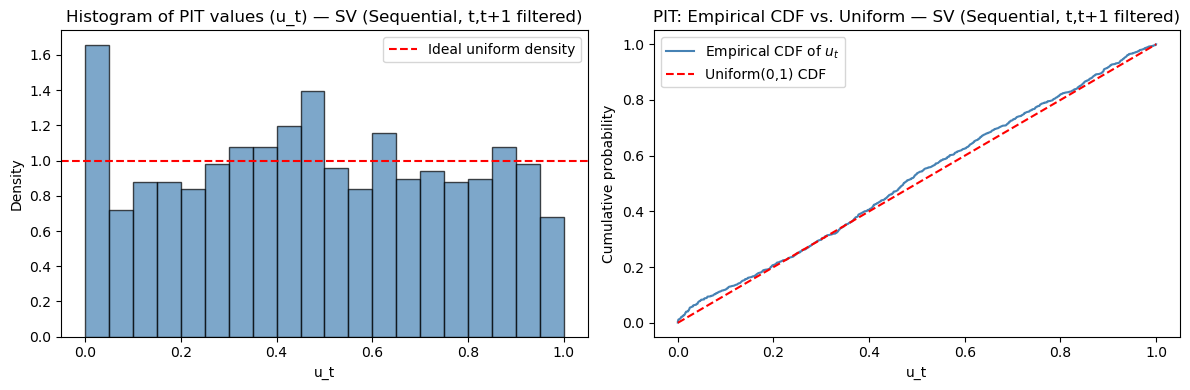

In [112]:
ks_stat_seq_sv, p_value_seq_sv = scipy_stats.kstest(all_pit_values_sv_seq_filtered, 'uniform')
print_pit_result(ks_stat_seq_sv, p_value_seq_sv, label="SV (Sequential, t,t+1 filtered)")
plot_pit(all_pit_values_sv_seq_filtered, label="SV (Sequential, t,t+1 filtered)")

Ljung-Box test on z_t (level) — SV (Sequential, t,t+1 filtered):
     lb_stat  lb_pvalue
1   0.032289   0.857394
5   2.878478   0.718714
10  3.084112   0.979375

Ljung-Box test on z_t^2 (squared, ARCH-LM style) — SV (Sequential, t,t+1 filtered):
      lb_stat  lb_pvalue
1    0.112902   0.736865
5   10.872729   0.053963
10  12.822494   0.233766


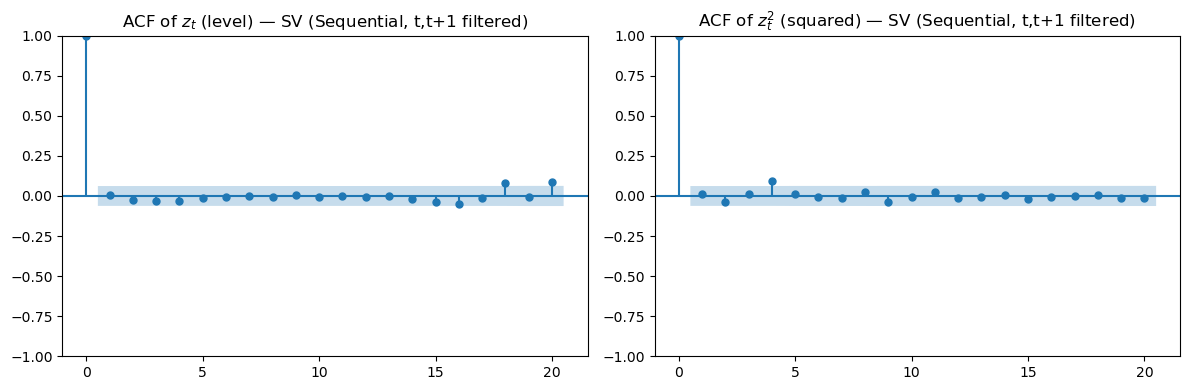

Engle-Ng Sign-Bias Test — SV (Sequential, t,t+1 filtered):
                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     6.985
Date:                Fri, 07 Aug 2026   Prob (F-statistic):            0.00835
Time:                        21:32:57   Log-Likelihood:                -2288.7
No. Observations:                1001   AIC:                             4581.
Df Residuals:                     999   BIC:                             4591.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [113]:
z_t_sequential_sv = compute_z(all_pit_values_sv_seq_filtered, dates_sequential_sv_pit)

lb_level_seq_sv, lb_sq_seq_sv = ljung_box_tests(z_t_sequential_sv)
print_ljung_box(lb_level_seq_sv, lb_sq_seq_sv, label="SV (Sequential, t,t+1 filtered)")
plot_acf_diagnostics(z_t_sequential_sv, label="SV (Sequential, t,t+1 filtered)")

sign_bias_model_seq_sv = sign_bias_test(
    z_t_sequential_sv, returns_sequential_sv, dates_sequential_sv_pit
)
print_sign_bias(sign_bias_model_seq_sv, label="SV (Sequential, t,t+1 filtered)")

In [114]:
def hv_coverage_sequential_posterior(hv_per_draw, actual, dates, window_boundaries, sigma_eta_by_window, level=90):
    '''Combined posterior-spread + noise coverage, using a different sigma_eta per window (expanding).
    Returns lower/upper bounds for plotting, plus the inside-CI mask.'''
    S, T = hv_per_draw.shape
    inside = np.zeros(T, dtype=bool)
    lower_full = np.zeros(T)
    upper_full = np.zeros(T)
    pct = (100 - level) / 2

    for i, (start_idx, end_idx) in enumerate(period_indices(dates, window_boundaries)):
        sigma_eta_i = sigma_eta_by_window[f"window_{i+1}"]
        window_hv_per_draw = hv_per_draw[:, start_idx:end_idx]
        noise = np.random.normal(0, sigma_eta_i, size=window_hv_per_draw.shape)
        noisy_hv = window_hv_per_draw * np.exp(noise)

        lower = np.percentile(noisy_hv, pct, axis=0)
        upper = np.percentile(noisy_hv, 100 - pct, axis=0)
        lower_full[start_idx:end_idx] = lower
        upper_full[start_idx:end_idx] = upper
        inside[start_idx:end_idx] = (actual[start_idx:end_idx] >= lower) & (actual[start_idx:end_idx] <= upper)

    return lower_full, upper_full, inside

90% CI Coverage by window — SV:
  period_1 (2022-01-01 to 2022-07-01): 100.00%
  period_2 (2022-07-01 to 2023-01-01): 100.00%
  period_3 (2023-01-01 to 2023-07-01): 94.35%
  period_4 (2023-07-01 to 2024-01-01): 96.03%
  period_5 (2024-01-01 to 2024-07-01): 90.32%
  period_6 (2024-07-01 to 2025-01-01): 84.38%
  period_7 (2025-01-01 to 2025-07-01): 82.79%
  period_8 (2025-07-01 to 2026-01-01): 100.00%


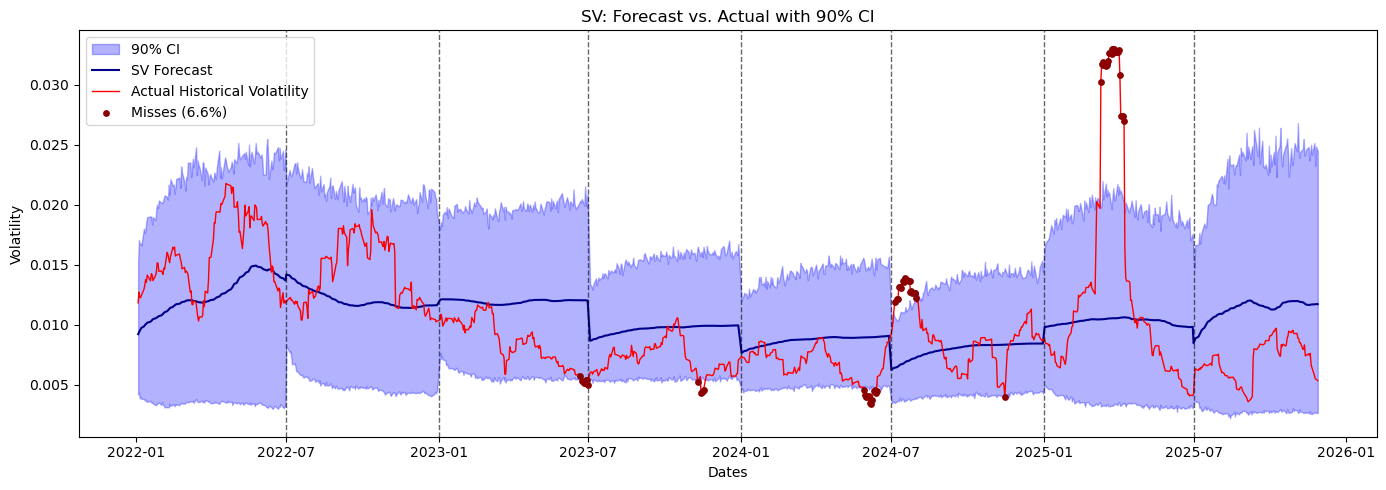

In [115]:
# Seeded for reproducibility -- covers hv_coverage_sequential_posterior's measurement-noise injection (SV sequential CI, standalone plot cell)
np.random.seed(42)

lower_seq_sv, upper_seq_sv, inside_seq_sv = hv_coverage_sequential_posterior(
    hv_per_draw_sequential_sv_aligned, actual_sequential_sv, dates_sequential_sv,
    window_boundaries, sigma_eta_windows_sv, level=90
)

coverage_windows_sv = mask_by_period(inside_seq_sv, dates_sequential_sv, window_boundaries)
print_coverage_by_window(coverage_windows_sv, label="SV", level=90)

plot_hv_coverage(
    forecast_sequential_sv, actual_sequential_sv, dates_sequential_sv,
    lower_seq_sv, upper_seq_sv, inside_seq_sv,
    level=90, label="SV",
    boundary_dates=window_boundaries,
    boundary_labels=[None]*len(window_boundaries),
    boundary_styles=['--']*len(window_boundaries)
)

### SV: Regression, Matched Period (2022-2025)

The SV equivalent of the EGARCH matched-period regression below: a one-shot PMCMC fit on the same 2022-2025 span the Sequential loop covers, carried forward from the 2018-2021 regression's posterior (`samples_sv`, `ls2_carry_sv`) via `pmcmc_refit`, using the same posterior-to-prior extraction each Sequential window's refit already performs. Comparing this against Sequential isolates the refit-frequency effect (once vs. every 6 months) from the 2018-2021-vs-2022-2025 market-period effect that otherwise confounds the original Regression-vs-Sequential comparison.

In [136]:
# ── Priors: carried forward from the 2018-2021 regression posterior, same extraction as each Sequential window's refit ──
mu_prior_mu_sv_r22   = float(samples_sv[:, 0].mean())
mu_prior_std_sv_r22  = max(float(samples_sv[:, 0].std()), 0.1)
beta_a_sv_r22, beta_b_sv_r22 = fit_beta_params(samples_sv[:, 1])
sigma_eta_prior_scale_sv_r22 = fit_halfnorm_scale(samples_sv[:, 2])
mu_return_prior_mu_sv_r22  = float(samples_sv[:, 3].mean())
mu_return_prior_std_sv_r22 = max(float(samples_sv[:, 3].std()), 0.0001)

ls2_seed_scalar_sv_r22 = float(np.mean(ls2_carry_sv))   # same carried state Sequential's window 1 uses

print(f"Refitting SV on the full 2022-2025 span ({len(sequential_returns_1d)} observations)...")
samples_out_sv_r22, ll_hist_sv_r22, filtered_hist_sv_r22 = pmcmc_refit(
    sequential_returns_1d, n_mcmc=1000, N=1000,
    mu_init=mu_prior_mu_sv_r22, phi_init=float(samples_sv[:, 1].mean()),
    sigma_eta_init=sigma_eta_prior_scale_sv_r22, mu_return_init=mu_return_prior_mu_sv_r22,
    mu_prior_mu=mu_prior_mu_sv_r22, mu_prior_std=mu_prior_std_sv_r22,
    phi_prior_a=beta_a_sv_r22, phi_prior_b=beta_b_sv_r22,
    sigma_eta_prior_scale=sigma_eta_prior_scale_sv_r22,
    mu_return_prior_mu=mu_return_prior_mu_sv_r22, mu_return_prior_std=mu_return_prior_std_sv_r22,
    ls2_init=ls2_seed_scalar_sv_r22
)

sv_r22_burnin = 300
samples_sv_r22 = samples_out_sv_r22[sv_r22_burnin:]
filtered_hist_sv_r22 = filtered_hist_sv_r22[sv_r22_burnin:]
sigma_posterior_sv_r22 = np.sqrt(np.exp(filtered_hist_sv_r22))
print("Done.")

Refitting SV on the full 2022-2025 span (1002 observations)...
Running Sequential PMCMC...
Step 0/1000, acceptance rate: 0.00%
Step 50: rate=22.00%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 100: rate=18.00%, proposal_std=[0.2    0.02   0.05   0.0002]
Step 150: rate=14.67%, proposal_std=[0.17   0.017  0.0425 0.0002]
Step 200: rate=11.00%, proposal_std=[1.445e-01 1.440e-02 3.610e-02 1.000e-04]
Step 250: rate=12.80%, proposal_std=[1.228e-01 1.230e-02 3.070e-02 1.000e-04]
Step 300: rate=13.33%, proposal_std=[1.044e-01 1.040e-02 2.610e-02 1.000e-04]
Step 350: rate=16.00%, proposal_std=[0.0887 0.0089 0.0222 0.0001]
Step 400: rate=17.75%, proposal_std=[0.0754 0.0075 0.0189 0.0001]
Step 450: rate=17.11%, proposal_std=[0.0641 0.0064 0.016  0.0001]
Step 500/1000, acceptance rate: 18.96%
Step 600/1000, acceptance rate: 23.13%
Step 700/1000, acceptance rate: 24.54%
Step 800/1000, acceptance rate: 26.34%
Step 900/1000, acceptance rate: 25.19%
Final acceptance rate: 26.40%
Done.


In [137]:
Path("results/sv").mkdir(parents=True, exist_ok=True)

with open("results/sv/sv_regression_2022_mcmc_raw.pkl", "wb") as f:
    pickle.dump({
        "samples_sv_r22": samples_sv_r22,
        "ll_hist_sv_r22": ll_hist_sv_r22,
        "sigma_posterior_sv_r22": sigma_posterior_sv_r22,
    }, f)

print("Saved SV matched-period (2022-2025) regression MCMC output.")

Saved SV matched-period (2022-2025) regression MCMC output.


In [138]:
with open("results/sv/sv_regression_2022_mcmc_raw.pkl", "rb") as f:
    raw_r22 = pickle.load(f)
    samples_sv_r22         = raw_r22["samples_sv_r22"]
    ll_hist_sv_r22         = raw_r22["ll_hist_sv_r22"]
    sigma_posterior_sv_r22 = raw_r22["sigma_posterior_sv_r22"]

In [139]:
# Seeded for reproducibility -- covers hv_coverage_posterior's measurement-noise injection (SV Regression 2022-2025, 90% CI)
np.random.seed(42)

forecast_regression_sv_r22_series = pd.Series(
    sigma_to_hv_correct(sigma_posterior_sv_r22, h=21),
    index=sequential_returns.index
).dropna()

forecast_regression_sv_r22, actual_regression_sv_r22, dates_regression_sv_r22 = align_series(
    forecast_regression_sv_r22_series, hv_sequential
)

ql_regression_sv_r22 = qlike(forecast_regression_sv_r22, actual_regression_sv_r22)
print(f"QLIKE (SV regression, 2022-2025 matched period): mean = {ql_regression_sv_r22.mean():.4f}")

# ── RV Coverage: combined posterior spread + log-normal noise (Order A) ──
sigma_eta_sv_r22, _ = hv_coverage(forecast_regression_sv_r22, actual_regression_sv_r22)

hv_per_draw_regression_sv_r22 = hv_per_draw_windowed(sigma_posterior_sv_r22, h=21)

hv_per_draw_regression_sv_r22_df = pd.DataFrame(
    hv_per_draw_regression_sv_r22.T, index=sequential_returns.index
).loc[dates_regression_sv_r22]
hv_per_draw_regression_sv_r22_aligned = hv_per_draw_regression_sv_r22_df.values.T

lower_90_sv_r22, upper_90_sv_r22, inside_90_sv_r22 = hv_coverage_posterior(
    hv_per_draw_regression_sv_r22_aligned, actual_regression_sv_r22, sigma_eta_sv_r22, level=90
)

coverage_90_sv_r22 = np.mean(inside_90_sv_r22)
print(f"SV (2022-2025 matched period) — 90% CI coverage (posterior + noise): {coverage_90_sv_r22:.2%}")

QLIKE (SV regression, 2022-2025 matched period): mean = 0.0551
SV (2022-2025 matched period) — 90% CI coverage (posterior + noise): 90.93%


SV (Regression, 2022-2025 matched period) — KS statistic: 0.0380
SV (Regression, 2022-2025 matched period) — p-value: 0.1087
SV (Regression, 2022-2025 matched period) — Fail to reject null: no evidence of miscalibration


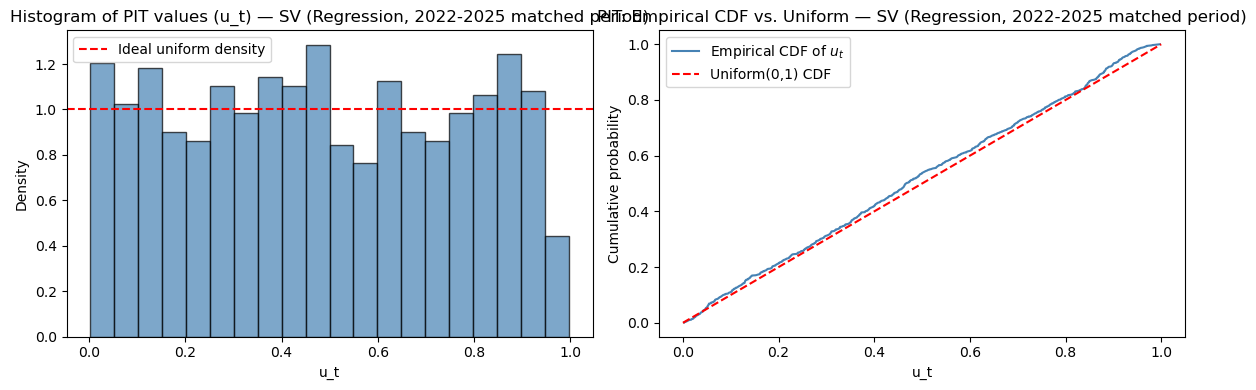

Ljung-Box test on z_t (level) — SV (Regression, 2022-2025 matched period):
     lb_stat  lb_pvalue
1   0.000903   0.976028
5   2.919499   0.712395
10  3.236111   0.975309

Ljung-Box test on z_t^2 (squared, ARCH-LM style) — SV (Regression, 2022-2025 matched period):
      lb_stat  lb_pvalue
1    2.192393   0.138694
5    9.193827   0.101578
10  13.689887   0.187612


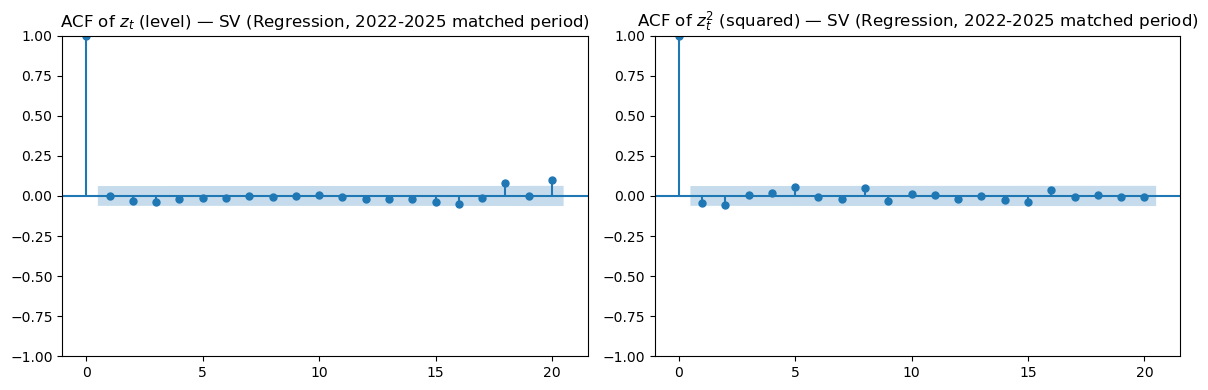

Engle-Ng Sign-Bias Test — SV (Regression, 2022-2025 matched period):
                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     8.816
Date:                Fri, 07 Aug 2026   Prob (F-statistic):            0.00306
Time:                        23:40:23   Log-Likelihood:                -1538.0
No. Observations:                1001   AIC:                             3080.
Df Residuals:                     999   BIC:                             3090.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

In [140]:
sigma_posterior_sv_r22_df = pd.DataFrame(
    sigma_posterior_sv_r22.T, index=sequential_returns.index
).dropna()

common_dates_pit_sv_r22 = sigma_posterior_sv_r22_df.index.intersection(sequential_returns.index)
sigma_posterior_sv_r22_pit = sigma_posterior_sv_r22_df.loc[common_dates_pit_sv_r22].values.T
returns_regression_sv_r22_pit = sequential_returns.loc[common_dates_pit_sv_r22].values.flatten()
dates_regression_sv_r22_pit = common_dates_pit_sv_r22

mu_return_samples_r22 = samples_sv_r22[:, 3]

u_t_regression_sv_r22, ks_stat_regression_sv_r22, p_value_regression_sv_r22 = compute_pit_posterior(
    returns_regression_sv_r22_pit, sigma_posterior_sv_r22_pit, mu_return_samples_r22, dist='normal'
)
print_pit_result(ks_stat_regression_sv_r22, p_value_regression_sv_r22, label="SV (Regression, 2022-2025 matched period)")
plot_pit(u_t_regression_sv_r22, label="SV (Regression, 2022-2025 matched period)")

z_t_regression_sv_r22 = compute_z(u_t_regression_sv_r22, dates_regression_sv_r22_pit)

lb_level_regression_sv_r22, lb_sq_regression_sv_r22 = ljung_box_tests(z_t_regression_sv_r22)
print_ljung_box(lb_level_regression_sv_r22, lb_sq_regression_sv_r22, label="SV (Regression, 2022-2025 matched period)")
plot_acf_diagnostics(z_t_regression_sv_r22, label="SV (Regression, 2022-2025 matched period)")

sign_bias_model_regression_sv_r22 = sign_bias_test(
    z_t_regression_sv_r22, returns_regression_sv_r22_pit, dates_regression_sv_r22_pit
)
print_sign_bias(sign_bias_model_regression_sv_r22, label="SV (Regression, 2022-2025 matched period)")

In [146]:
# ── Per-window breakdown, for direct comparison against Sequential's by-window tables ──
qlike_windows_sv_r22 = metric_by_period(forecast_regression_sv_r22, actual_regression_sv_r22,
                                          dates_regression_sv_r22, window_boundaries, qlike)
print_metric_by_window(qlike_windows_sv_r22, label="SV (Regression, 2022-2025 matched period)", metric_name="QLIKE")

coverage_windows_sv_r22 = mask_by_period(inside_90_sv_r22, dates_regression_sv_r22, window_boundaries)
print_coverage_by_window(coverage_windows_sv_r22, label="SV (Regression, 2022-2025 matched period)", level=90)

QLIKE by window — SV (Regression, 2022-2025 matched period):
  period_1 (2022-01-01 to 2022-07-01): 0.0467
  period_2 (2022-07-01 to 2023-01-01): 0.0308
  period_3 (2023-01-01 to 2023-07-01): 0.0223
  period_4 (2023-07-01 to 2024-01-01): 0.0247
  period_5 (2024-01-01 to 2024-07-01): 0.0430
  period_6 (2024-07-01 to 2025-01-01): 0.0630
  period_7 (2025-01-01 to 2025-07-01): 0.1519
  period_8 (2025-07-01 to 2026-01-01): 0.0614
90% CI Coverage by window — SV (Regression, 2022-2025 matched period):
  period_1 (2022-01-01 to 2022-07-01): 95.16%
  period_2 (2022-07-01 to 2023-01-01): 99.21%
  period_3 (2023-01-01 to 2023-07-01): 98.39%
  period_4 (2023-07-01 to 2024-01-01): 93.65%
  period_5 (2024-01-01 to 2024-07-01): 91.13%
  period_6 (2024-07-01 to 2025-01-01): 92.19%
  period_7 (2025-01-01 to 2025-07-01): 69.67%
  period_8 (2025-07-01 to 2026-01-01): 86.79%


## Results

### Breakdown

In [116]:
from pathlib import Path
Path("results").mkdir(parents=True, exist_ok=True)

In [117]:
# ── Shared table-building helpers ──

def build_comparison_table(label_suffix, models_dict):
    lines = [f"### {label_suffix} Comparison\n"]
    lines.append("| Metric | Baseline | EGARCH | SV |")
    lines.append("|---|---|---|---|")
    metrics_to_show = [
        ("QLIKE (mean)", "qlike", "{:.4f}"),
        ("90% CI Coverage", "coverage_90", "{:.2%}"),
        ("Measurement noise (sigma_eta)", "sigma_eta", "{:.4f}"),
    ]
    for label, key, fmt in metrics_to_show:
        row = f"| {label} "
        for model_name in ["Baseline", "EGARCH", "SV"]:
            val = models_dict.get(model_name, {}).get(key, None)
            row += f"| {fmt.format(val) if val is not None else 'N/A'} "
        row += "|"
        lines.append(row)
    return "\n".join(lines)


def build_metric_table(metric_label, models_dict, value_key, fmt="{:.4f}"):
    lines = [f"### {metric_label}\n", "| | Baseline | EGARCH | SV |", "|---|---|---|---|"]
    for row_label, row_key in value_key.items():
        row = f"| {row_label} "
        for model_name in ["Baseline", "EGARCH", "SV"]:
            val = models_dict.get(model_name, {}).get(row_key, None)
            row += f"| {fmt.format(val) if val is not None else 'N/A'} "
        row += "|"
        lines.append(row)
    return "\n".join(lines)


def build_window_table(metric_label, windows_dict_by_model, fmt="{:.4f}"):
    n_windows = len(windows_dict_by_model["Baseline"])
    lines = [f"### {metric_label} — By Window\n", "| Window | Baseline | EGARCH | SV |", "|---|---|---|---|"]
    for i in range(1, n_windows + 1):
        key = f"period_{i}"
        row = f"| Window {i} "
        for model_name in ["Baseline", "EGARCH", "SV"]:
            val = windows_dict_by_model[model_name][key]['value']
            row += f"| {fmt.format(val)} "
        row += "|"
        lines.append(row)
    return "\n".join(lines)


def build_multilevel_table(metric_label, models_dict, fmt="{:.2%}"):
    levels = sorted(models_dict["Baseline"].keys())
    lines = [f"### {metric_label} — By CI Level\n", "| CI Level | Baseline | EGARCH | SV |", "|---|---|---|---|"]
    for level in levels:
        row = f"| {level}% "
        for model_name in ["Baseline", "EGARCH", "SV"]:
            row += f"| {fmt.format(models_dict[model_name][level])} "
        row += "|"
        lines.append(row)
    return "\n".join(lines)


def summarize_sigma_eta_windows(sigma_eta_by_window):
    windows = sorted(sigma_eta_by_window.keys(), key=lambda k: int(k.split('_')[1]))
    return sigma_eta_by_window[windows[0]], sigma_eta_by_window[windows[-1]]

## How to Read the Results Below

- **QLIKE**: lower is better; no fixed threshold, primarily useful for ranking models against each other.
- **HV Coverage**: for a stated CI (e.g. 90%), the target is that exact percentage — below target means overconfident (too-narrow) intervals; above target means underconfident (too-wide) intervals.
- **Interval width**: given similar coverage, narrower is more informative; a wide interval can trivially achieve "good" coverage while carrying little real information.
- **Measurement noise ($\hat\sigma_\eta$) progression**: growing over the sequential period indicates the gap between forecast and empirical benchmark is widening, not narrowing.
- **Forecast-actual correlation**: higher indicates the forecast genuinely tracks real movements; near-zero indicates little to no relationship.
- **PIT/KS p-value**: p>0.05 indicates no evidence of miscalibration (a "pass"); the KS statistic itself indicates the size of any deviation, useful for comparing severity even when p-values are hard to compare across differing sample sizes.
- **Ljung-Box / Engle-Ng p-values**: p>0.05 indicates no evidence of the tested pattern (no persistence, no clustering, no leverage-driven bias); the coefficient/statistic size indicates how severe a failure is, not just whether it's significant.

- **Metrics with a fixed ideal value** (correlation: ideal=1; coverage: ideal=stated CI level; PIT/Ljung-Box/Engle-Ng p-values: no fixed "ideal" number, but a clear pass/fail threshold at 0.05) are read by their distance from that fixed point, not by ratio-to-baseline.
- **Metrics with no fixed ideal** (QLIKE: no natural zero or target value, only meaningful in comparison) are read as ratios relative to baseline.

In [149]:
# ── Generic, column-parameterized table builders for the 2022 Regression vs. 2022 Sequential
# comparison (EGARCH/SV only ── Baseline has no separate fit to compare, see note in Results.md).
# The existing build_*_table functions above are hardcoded to ["Baseline", "EGARCH", "SV"]; these
# generalize the same table shapes to an arbitrary ordered column list. ──
standard_cols = ["Baseline", "EGARCH", "SV"]

# Single-value metrics (QLIKE mean, coverage %) use the existing build_metric_table/
# build_window_table directly: models as columns, period/method as rows -- 3 cols x 2 rows,
# not a wide 6-column table. Metrics that already have multiple rows for one period/method
# (PIT's ks_stat/p_value, Ljung-Box, Engle-Ng, by-window) get a separate 3-column table per
# period/method instead of stacking a 3rd dimension into more rows or more columns -- these
# use the generic build_*_table_cols helpers below, called with standard_cols each time.


def build_metric_table_cols(metric_label, columns, models_dict, value_key, fmt="{:.4f}"):
    lines = [f"### {metric_label}\n", "| | " + " | ".join(columns) + " |", "|---|" + "---|" * len(columns)]
    for row_label, row_key in value_key.items():
        row = f"| {row_label} "
        for col in columns:
            val = models_dict.get(col, {}).get(row_key, None)
            row += f"| {fmt.format(val) if val is not None else 'N/A'} "
        row += "|"
        lines.append(row)
    return "\n".join(lines)


def build_window_table_cols(metric_label, columns, windows_dict_by_model, fmt="{:.4f}"):
    n_windows = len(windows_dict_by_model[columns[0]])
    lines = [f"### {metric_label} — By Window\n", "| Window | " + " | ".join(columns) + " |", "|---|" + "---|" * len(columns)]
    for i in range(1, n_windows + 1):
        key = f"period_{i}"
        row = f"| Window {i} "
        for col in columns:
            val = windows_dict_by_model[col][key]['value']
            row += f"| {fmt.format(val)} "
        row += "|"
        lines.append(row)
    return "\n".join(lines)


def build_pit_table_cols(label_suffix, columns, models_dict):
    lines = [f"### PIT/KS — {label_suffix}\n", "| | " + " | ".join(columns) + " |", "|---|" + "---|" * len(columns)]
    row_ks = "| KS statistic "
    row_p  = "| p-value "
    for col in columns:
        row_ks += f"| {models_dict[col]['ks_stat']:.4f} "
        row_p  += f"| {models_dict[col]['p_value']:.4f} "
    row_ks += "|"
    row_p  += "|"
    lines.append(row_ks)
    lines.append(row_p)
    return "\n".join(lines)


def build_ljungbox_table_cols(label_suffix, columns, models_dict, lag=5):
    lines = [f"### Ljung-Box (lag={lag}) — {label_suffix}\n", "| | " + " | ".join(columns) + " |", "|---|" + "---|" * len(columns)]
    row_level = "| p-value, $z_t$ (level) "
    row_sq    = "| p-value, $z_t^2$ (squared) "
    for col in columns:
        p_level = models_dict[col]["lb_level"].loc[lag, "lb_pvalue"]
        p_sq    = models_dict[col]["lb_sq"].loc[lag, "lb_pvalue"]
        row_level += f"| {p_level:.4f} "
        row_sq    += f"| {p_sq:.4f} "
    row_level += "|"
    row_sq    += "|"
    lines.append(row_level)
    lines.append(row_sq)
    return "\n".join(lines)


def build_engle_ng_table_cols(label_suffix, columns, models_dict):
    lines = [f"### Engle-Ng Sign-Bias — {label_suffix}\n", "| | " + " | ".join(columns) + " |", "|---|" + "---|" * len(columns)]
    row_coef = "| $\\beta_1$ (sign_lag coef) "
    row_p    = "| p-value "
    for col in columns:
        model = models_dict[col]
        row_coef += f"| {model.params['sign_lag']:.4f} "
        row_p    += f"| {model.pvalues['sign_lag']:.4f} "
    row_coef += "|"
    row_p    += "|"
    lines.append(row_coef)
    lines.append(row_p)
    return "\n".join(lines)

In [150]:
# ══════════════════════════════════════════════════════
# SECTION 1: QLIKE
# ══════════════════════════════════════════════════════

# ── Regression: 2018-2021 vs. 2022-2025 (COVID period vs. matched period) ──
qlike_period_compare = {
    "Baseline": {"2018-2021": ql_regression_rolling.mean(), "2022-2025": ql_sequential_rolling.mean()},
    "EGARCH":   {"2018-2021": ql_regression_egarch.mean(),  "2022-2025": ql_regression_egarch_r22.mean()},
    "SV":       {"2018-2021": ql_regression_sv.mean(),      "2022-2025": ql_regression_sv_r22.mean()},
}
qlike_period_compare_table = build_metric_table(
    "QLIKE (mean) — Regression, 2018-2021 vs. 2022-2025", qlike_period_compare,
    {"2018-2021": "2018-2021", "2022-2025": "2022-2025"}
)

# ── COVID breakdown -- further breakdown of the 2018-2021 Regression period ──
qlike_covid = {
    "Baseline": qlike_covid_rolling,
    "EGARCH":   qlike_breakdown_egarch,
    "SV":       qlike_breakdown_sv,
}
qlike_covid_table = build_metric_table(
    "QLIKE — Regression, COVID Breakdown (2018-2021)", qlike_covid,
    {"Pre-COVID": "pre", "COVID": "covid", "Post-COVID": "post"}
)

# ── 2022-2025: Regression vs. Sequential (all 3 models; EGARCH/SV use t,t+1 filtered forecast) ──
qlike_matched_pooled = {
    "Baseline": {"Regression": ql_sequential_rolling.mean(), "Sequential": ql_sequential_rolling.mean()},
    "EGARCH":   {"Regression": ql_regression_egarch_r22.mean(), "Sequential": ql_sequential_egarch_filtered.mean()},
    "SV":       {"Regression": ql_regression_sv_r22.mean(), "Sequential": ql_sequential_sv_filtered.mean()},
}
qlike_matched_pooled_table = build_metric_table(
    "QLIKE — 2022-2025, Pooled (Regression vs. Sequential)", qlike_matched_pooled,
    {"Regression": "Regression", "Sequential": "Sequential"}
)

# ── By window: Regression and Sequential as two separate tables (2018-2021 has no windows) ──
qlike_windows_egarch = metric_by_period(forecast_sequential_egarch_filtered, actual_sequential_egarch_filtered,
                                          dates_sequential_egarch_filtered, window_boundaries, qlike)
qlike_windows_sv = metric_by_period(forecast_sequential_sv_filtered, actual_sequential_sv_filtered,
                                      dates_sequential_sv_filtered, window_boundaries, qlike)
qlike_windows_rolling = metric_by_period(forecast_sequential_rolling, actual_sequential_rolling,
                                           dates_sequential_rolling, window_boundaries, qlike)

qlike_by_window_regression_table = build_window_table(
    "QLIKE (Regression)", {"Baseline": qlike_windows_rolling, "EGARCH": qlike_windows_egarch_r22, "SV": qlike_windows_sv_r22}
)
qlike_by_window_sequential_table = build_window_table(
    "QLIKE (Sequential, t,t+1 filtered)", {"Baseline": qlike_windows_rolling, "EGARCH": qlike_windows_egarch, "SV": qlike_windows_sv}
)

# ── Sequential forecast-actual correlation (filtered) ──
corr_sequential = {
    "Baseline": {"corr": np.corrcoef(forecast_sequential_rolling, actual_sequential_rolling)[0, 1]},
    "EGARCH":   {"corr": np.corrcoef(forecast_sequential_egarch_filtered, actual_sequential_egarch_filtered)[0, 1]},
    "SV":       {"corr": np.corrcoef(forecast_sequential_sv_filtered, actual_sequential_sv_filtered)[0, 1]},
}
corr_table = build_metric_table("Sequential Forecast-Actual Correlation (t,t+1 filtered)", corr_sequential, {"Correlation": "corr"})

# ── Assemble and write ──
qlike_section = (
    f"{qlike_period_compare_table}\n\n{qlike_covid_table}\n\n"
    f"{qlike_matched_pooled_table}\n\n{qlike_by_window_regression_table}\n\n{qlike_by_window_sequential_table}\n\n"
    f"{corr_table}\n"
)

print(qlike_section)

### QLIKE (mean) — Regression, 2018-2021 vs. 2022-2025

| | Baseline | EGARCH | SV |
|---|---|---|---|
| 2018-2021 | 1.2659 | 0.0992 | 0.0702 |
| 2022-2025 | 0.3955 | 0.0726 | 0.0551 |

### QLIKE — Regression, COVID Breakdown (2018-2021)

| | Baseline | EGARCH | SV |
|---|---|---|---|
| Pre-COVID | 1.2380 | 0.1112 | 0.0687 |
| COVID | 6.3625 | 0.1622 | 0.1974 |
| Post-COVID | 0.5425 | 0.0739 | 0.0525 |

### QLIKE — 2022-2025, Pooled (Regression vs. Sequential)

| | Baseline | EGARCH | SV |
|---|---|---|---|
| Regression | 0.3955 | 0.0726 | 0.0551 |
| Sequential | 0.3955 | 0.2944 | 0.2703 |

### QLIKE (Regression) — By Window

| Window | Baseline | EGARCH | SV |
|---|---|---|---|
| Window 1 | 0.2578 | 0.0108 | 0.0467 |
| Window 2 | 0.1093 | 0.0514 | 0.0308 |
| Window 3 | 0.0842 | 0.0470 | 0.0223 |
| Window 4 | 0.1296 | 0.0916 | 0.0247 |
| Window 5 | 0.1702 | 0.0862 | 0.0430 |
| Window 6 | 0.9491 | 0.0600 | 0.0630 |
| Window 7 | 1.0283 | 0.1299 | 0.1519 |
| Window 8 | 0.4464 | 0.1112 | 0

Regression (2018-2021) to (2022-2025) COVID

Overall, the QLIKE mean is larger for the overall 2018-2021 period particularly for baseline across all models. 

During the COVID spike, the QLIKE mean for all 3 models rises. EGARCH has the lowest QLIKE mean during this spike, whereas SV has the lowest QLIKE mean in pre-COVID, post-COVID and overall.


Regression vs Sequential (2022-2025)

EGARCH, SV QLIKE Mean increases by 4x, 5x respectively i.e models don't generalize. 

SV outperforms EGARCH in both the regression and sequential setting.
Both outperform baseline even in the sequential setting (EGARCH has 0.75x QLIKE mean of baseline, SV has 0.7x QLIKE mean of baseline)

With regards to the window 7, QLIKE mean increases by 6x compared to the regression setting i.e the error worsens in more volatile periods.

The baseline is substantially worse than EGARCH, SV even in the sequential setting, but it does perform better than the EGARCH, SV for some windows (see window 3,4 in sequential table)

**Interpretation 1a — COVID Stress Test (2018-2021 vs. 2022-2025)**

QLIKE is worse for all three models with COVID in-sample — Baseline ~3.2x, EGARCH ~1.4x, SV ~1.3x higher than 2022-2025. COVID vs. own pre-COVID: Baseline ~5x, SV ~3x, EGARCH ~1.5x.

**Interpretation 1b — Regression vs. Sequential (Does It Generalize?)**

Regression scores lower QLIKE for both models, as expected — it's a much easier task (one full-sample fit vs. eight blind incremental refits). The real question is how much worse Sequential gets: EGARCH's pooled QLIKE degrades ~4.1x (0.073→0.294), SV's ~4.9x (0.055→0.270) — a substantial gap, not a mild one.
- Window 7 shows where generalization breaks down: EGARCH's Window 7 QLIKE is ~1.8x its own Regression pooled mean, but ~2.6x its Sequential pooled mean — proportionally worse once the model has to refit incrementally rather than fit with hindsight. SV: ~2.8x pooled under Regression vs. ~3.5x under Sequential.
- Both settings find Window 7 hardest, but the incremental, causal setting makes it *disproportionately* harder — exactly the kind of degradation a generalization check is meant to catch.

## 1. QLIKE

**Regression**: EGARCH scores ~13x lower than Baseline; SV scores ~18x lower than Baseline.
- COVID vs. own pre-COVID: Baseline ~5x, SV ~3x, EGARCH ~1.5x.
- Post-COVID vs. pre-COVID: both Bayesian models lower.

**Sequential**: EGARCH scores ~1.3x higher than Baseline; SV scores ~1.1x lower than Baseline.
- Window 7: worst score for all three.
- Forecast-actual correlation (ideal = 1): Baseline 0.49, SV 0.30, EGARCH 0.0035 — EGARCH shows essentially no relationship between forecast and actual movements; baseline and SV both show weak-to-moderate tracking.

In [167]:
# ══════════════════════════════════════════════════════
# SECTION 2: HV Coverage and Measurement Noise
# ══════════════════════════════════════════════════════

# ── Regression: 2018-2021 vs. 2022-2025 (COVID period vs. matched period) ──
coverage_period_compare = {
    "Baseline": {"2018-2021": hv_coverage_rolling[90], "2022-2025": np.mean(inside_seq_rolling)},
    "EGARCH":   {"2018-2021": coverage_90_egarch,      "2022-2025": coverage_90_egarch_r22},
    "SV":       {"2018-2021": coverage_90_sv,          "2022-2025": coverage_90_sv_r22},
}
coverage_period_compare_table = build_metric_table(
    "HV Coverage (90% CI) — Regression, 2018-2021 vs. 2022-2025", coverage_period_compare,
    {"2018-2021": "2018-2021", "2022-2025": "2022-2025"}, fmt="{:.2%}"
)

# ── COVID breakdown -- further breakdown of the 2018-2021 Regression period ──
coverage_covid = {
    "Baseline": covid_coverage_rolling,
    "EGARCH":   covid_coverage_egarch,
    "SV":       covid_coverage_sv,
}
coverage_covid_table = build_metric_table(
    "HV Coverage (90% CI) — Regression, COVID Breakdown (2018-2021)", coverage_covid,
    {"Pre-COVID": "pre", "COVID": "covid", "Post-COVID": "post"}, fmt="{:.2%}"
)

# ── Baseline's 2022-2025 coverage, computed once for each of the two noise-calibration
# philosophies "Regression" and "Sequential" represent throughout this section: pooled (one
# sigma_eta over the whole span, same mechanism as 2018-2021's Regression) vs. windowed/expanding
# (a separate, causally-growing sigma_eta per 6-month window, same mechanism Sequential uses
# everywhere else). These are genuinely different calibrations, so they SHOULD give different
# coverage numbers -- Baseline isn't a different fit either way, but it is a different band. ──
sigma_eta_rolling_r22, hv_coverage_rolling_r22 = hv_coverage(forecast_sequential_rolling, actual_sequential_rolling)
_, _, inside_rolling_r22, _ = hv_coverage_intervals(forecast_sequential_rolling, actual_sequential_rolling, level=90, sigma_eta=sigma_eta_rolling_r22)

# ── 2022-2025: Regression vs. Sequential (all 3 models) ──
coverage_matched_pooled = {
    "Baseline": {"Regression": hv_coverage_rolling_r22[90], "Sequential": np.mean(inside_seq_rolling)},
    "EGARCH":   {"Regression": coverage_90_egarch_r22, "Sequential": np.mean(inside_seq_egarch)},
    "SV":       {"Regression": coverage_90_sv_r22, "Sequential": np.mean(inside_seq_sv)},
}
coverage_matched_pooled_table = build_metric_table(
    "HV Coverage (90% CI) — 2022-2025, Pooled (Regression vs. Sequential)", coverage_matched_pooled,
    {"Regression": "Regression", "Sequential": "Sequential"}, fmt="{:.2%}"
)

# ── By window: Regression and Sequential as two separate tables (2018-2021 has no windows) ──
coverage_windows_egarch = mask_by_period(inside_seq_egarch, dates_sequential_egarch, window_boundaries)
coverage_windows_sv = mask_by_period(inside_seq_sv, dates_sequential_sv, window_boundaries)
coverage_windows_rolling = mask_by_period(inside_seq_rolling, dates_sequential_rolling, window_boundaries)
coverage_windows_rolling_pooled = mask_by_period(inside_rolling_r22, dates_sequential_rolling, window_boundaries)

coverage_by_window_regression_table = build_window_table(
    "HV Coverage (90%, Regression)",
    {"Baseline": coverage_windows_rolling_pooled, "EGARCH": coverage_windows_egarch_r22, "SV": coverage_windows_sv_r22},
    fmt="{:.2%}"
)
coverage_by_window_sequential_table = build_window_table(
    "HV Coverage (90%, Sequential)",
    {"Baseline": coverage_windows_rolling, "EGARCH": coverage_windows_egarch, "SV": coverage_windows_sv},
    fmt="{:.2%}"
)

# ── Multilevel coverage -- Regression, 2018-2021 ──
coverage_multilevel = {
    "Baseline": hv_coverage_rolling,
    "EGARCH":   hv_coverage_regression_egarch,
    "SV":       hv_coverage_regression_sv,
}
coverage_multilevel_table = build_multilevel_table("HV Coverage — Regression (2018-2021)", coverage_multilevel)

# ── Mean 90% CI width -- Regression, 2018-2021 ──
width_regression = {
    "Baseline": {"width": np.mean(upper_90_regression_rolling - lower_90_regression_rolling)},
    "EGARCH":   {"width": np.mean(upper_90_egarch - lower_90_egarch)},
    "SV":       {"width": np.mean(upper_90_sv - lower_90_sv)},
}
width_table = build_metric_table("Mean 90% CI Width — Regression (2018-2021)", width_regression, {"Mean Width": "width"})

# ── Measurement noise -- Regression, 2018-2021 ──
noise_regression = {
    "Baseline": {"pooled": sigma_eta_regression_rolling},
    "EGARCH":   {"pooled": sigma_eta_egarch},
    "SV":       {"pooled": sigma_eta_sv},
}
noise_regression_table = build_metric_table(
    "Measurement Noise (sigma_eta) — Regression (2018-2021)", noise_regression, {"sigma_eta": "pooled"}
)

# ── Multilevel coverage helpers -- 2022-2025 (same windowed-noise mechanism as the
# existing 90%-only sequential coverage, just looped over levels) ──
def hv_coverage_sequential_multilevel_posterior(hv_per_draw, actual, dates, sigma_eta_by_window, levels=[50, 60, 70, 80, 85, 90, 95, 99]):
    return {lvl: np.mean(hv_coverage_sequential_posterior(hv_per_draw, actual, dates, window_boundaries, sigma_eta_by_window, level=lvl)[2]) for lvl in levels}


def hv_coverage_sequential_multilevel_point(forecast, actual, dates, sigma_eta_by_window, levels=[50, 60, 70, 80, 85, 90, 95, 99]):
    return {lvl: np.mean(hv_coverage_sequential(forecast, actual, dates, window_boundaries, sigma_eta_by_window, level=lvl)[2]) for lvl in levels}


coverage_multilevel_2022_regression = {
    "Baseline": hv_coverage_rolling_r22,
    "EGARCH":   hv_coverage_posterior_multilevel(hv_per_draw_regression_egarch_r22_aligned, actual_regression_egarch_r22, sigma_eta_egarch_r22),
    "SV":       hv_coverage_posterior_multilevel(hv_per_draw_regression_sv_r22_aligned, actual_regression_sv_r22, sigma_eta_sv_r22),
}
coverage_multilevel_2022_regression_table = build_multilevel_table(
    "HV Coverage — 2022-2025, Regression", coverage_multilevel_2022_regression
)

coverage_multilevel_2022_sequential = {
    "Baseline": hv_coverage_sequential_multilevel_point(forecast_sequential_rolling, actual_sequential_rolling, dates_sequential_rolling, sigma_eta_windows_rolling),
    "EGARCH":   hv_coverage_sequential_multilevel_posterior(hv_per_draw_sequential_aligned, actual_sequential_egarch, dates_sequential_egarch, sigma_eta_windows_egarch),
    "SV":       hv_coverage_sequential_multilevel_posterior(hv_per_draw_sequential_sv_aligned, actual_sequential_sv, dates_sequential_sv, sigma_eta_windows_sv),
}
coverage_multilevel_2022_sequential_table = build_multilevel_table(
    "HV Coverage — 2022-2025, Sequential", coverage_multilevel_2022_sequential
)

# ── Measurement noise -- Regression, 2022-2025 (sigma_eta_rolling_r22 computed above, pooled) ──
noise_regression_2022 = {
    "Baseline": {"pooled": sigma_eta_rolling_r22},
    "EGARCH":   {"pooled": sigma_eta_egarch_r22},
    "SV":       {"pooled": sigma_eta_sv_r22},
}
noise_regression_2022_table = build_metric_table(
    "Measurement Noise (sigma_eta) — Regression (2022-2025)", noise_regression_2022, {"sigma_eta": "pooled"}
)

# ── Measurement noise progression -- Sequential, 2022-2025, first vs. final window ──
seq_noise_rolling_first, seq_noise_rolling_last = summarize_sigma_eta_windows(sigma_eta_windows_rolling)
seq_noise_egarch_first, seq_noise_egarch_last   = summarize_sigma_eta_windows(sigma_eta_windows_egarch)
seq_noise_sv_first, seq_noise_sv_last           = summarize_sigma_eta_windows(sigma_eta_windows_sv)

noise_sequential = {
    "Baseline": {"first": seq_noise_rolling_first, "last": seq_noise_rolling_last},
    "EGARCH":   {"first": seq_noise_egarch_first, "last": seq_noise_egarch_last},
    "SV":       {"first": seq_noise_sv_first, "last": seq_noise_sv_last},
}
noise_sequential_table = build_metric_table(
    "Measurement Noise (sigma_eta) — Sequential (2022-2025), First vs. Final Window", noise_sequential,
    {"Window 1": "first", "Final Window": "last"}
)

# ── Assemble and write ──
coverage_section = (
    f"{coverage_period_compare_table}\n\n{coverage_covid_table}\n\n"
    f"{coverage_matched_pooled_table}\n\n{coverage_by_window_regression_table}\n\n{coverage_by_window_sequential_table}\n\n"
    f"{coverage_multilevel_table}\n\n{coverage_multilevel_2022_regression_table}\n\n{coverage_multilevel_2022_sequential_table}\n\n"
    f"{width_table}\n\n{noise_regression_table}\n\n{noise_regression_2022_table}\n\n{noise_sequential_table}\n"
)

print(coverage_section)

### HV Coverage (90% CI) — Regression, 2018-2021 vs. 2022-2025

| | Baseline | EGARCH | SV |
|---|---|---|---|
| 2018-2021 | 89.78% | 85.43% | 90.89% |
| 2022-2025 | 93.68% | 82.26% | 90.93% |

### HV Coverage (90% CI) — Regression, COVID Breakdown (2018-2021)

| | Baseline | EGARCH | SV |
|---|---|---|---|
| Pre-COVID | 88.70% | 80.65% | 90.80% |
| COVID | 52.38% | 87.30% | 66.67% |
| Post-COVID | 96.68% | 91.29% | 94.78% |

### HV Coverage (90% CI) — 2022-2025, Pooled (Regression vs. Sequential)

| | Baseline | EGARCH | SV |
|---|---|---|---|
| Regression | 91.23% | 82.26% | 90.93% |
| Sequential | 93.68% | 93.37% | 93.37% |

### HV Coverage (90%, Regression) — By Window

| Window | Baseline | EGARCH | SV |
|---|---|---|---|
| Window 1 | 96.77% | 100.00% | 95.16% |
| Window 2 | 100.00% | 94.49% | 99.21% |
| Window 3 | 98.39% | 95.16% | 98.39% |
| Window 4 | 96.03% | 70.63% | 93.65% |
| Window 5 | 100.00% | 80.65% | 91.13% |
| Window 6 | 80.47% | 83.59% | 92.19% |
| Window 7 | 65.57% 

Regression (2018-2021) to (2022-2025) COVID

Overall, the coverage is better during the 2018-2021 period at the 90% confidence interval. 

During the COVID spike, EGARCH is the only model with good coverage.
EGARCH also provides best coverage Post-COVID but massively undercovers Pre-COVID. 

SV is best at Pre-COVID and is consistently better than the baseline across all sections.

The predictions in 2022-2025 are more valuable because the measurement noise is lower for all the models.


Regression vs Sequential (2022-2025)

During the regression period EGARCH undercovers throughout. The SV and baseline both overcover early on while undercovering later on, but the baseline model is consistently worse throughout the coverage by a significant margin. 

Relative to the baseline, the measurement noise is 0.35x of EGARCH and 0.3x of SV in regression so the predictions from the SV are also the most informative.

In the sequential period, the distinction isn't as clear between SV and EGARCH while the baseline overcovers everything. Generally EGARCH and SV overcover for higher percentage intervals and they perform similarly in sequential setting.

In sequential, the measurement noise for all models rise. Interestingly, the measurement noise falls from window 1 to final window for baseline while the noise rises for SV, EGARCH.

For Window 7, the models all equally undercover the model in regression, covering around 70% for the 90% confidence interval. The models have higher coverage during sequential especially EGARCH, SV although this could be due to the larger noise estimate.

**Interpretation 2a — COVID Stress Test (2018-2021 vs. 2022-2025)**

Baseline and SV dip sharply during COVID and recover after (Baseline 88.70%→52.38%→96.68%; SV 90.80%→66.67%→94.78%). EGARCH is the opposite — its best coverage is *during* COVID (87.30%), and its pooled 2018-2021 number is worse without it (82.26% vs. 85.43%).

**Interpretation 2b — Regression vs. Sequential (Does It Generalize?)**

Coverage doesn't uniformly favor Regression the way QLIKE did — EGARCH's Sequential coverage (93.37%) is closer to the 90% target than Regression's (82.26%); SV is close either way (90.93% vs. 93.37%).
- Window 7 tells the opposite story from QLIKE: EGARCH's Window 7 coverage is 15.1pp below its Regression pooled mean but only 12.2pp below its Sequential pooled mean — Sequential's shortfall is proportionally smaller. SV shows the same direction more sharply: 21.3pp below pooled under Regression vs. 10.6pp under Sequential.
- So on coverage, refitting incrementally seems to help the model track Window 7's regime shift rather than hurt it — generalization quality here is metric-dependent, not a single verdict.

## 2. HV Coverage and Measurement Noise

**Regression** (90% CI, ideal = 90%): Baseline 89.78%, EGARCH 85.73%, SV 90.99%.
- EGARCH under-covers at every CI level tested (50%–99%).
- Pre-COVID: Baseline 88.70%, EGARCH 81.03%, SV 91.00%.
- COVID: Baseline 52.38%, SV 65.08%, EGARCH 87.30%.
- Post-COVID: Baseline 96.68%, EGARCH 91.54%, SV 95.02%.
- EGARCH's coverage pattern is the reverse of baseline/SV's: worst pre-COVID, best during COVID.
- Mean 90% CI width: Baseline is ~3x EGARCH's and ~4x SV's.

**Sequential** (90% CI, ideal = 90%): all three converge to ~93%.
- Window 7 is the worst window for all three models.
- $\hat\sigma_\eta$, window 1 → final window: Baseline shrinks (~0.87x); EGARCH grows (~1.6x); SV grows (~1.55x).

In [152]:
# ══════════════════════════════════════════════════════
# SECTION 3: PIT / KS
# ══════════════════════════════════════════════════════

# ── Three tables: 2018-2021 vs. 2022-2025 read from table 1 vs. 2;
# Regression vs. Sequential (2022-2025) read from table 2 vs. 3 ──
pit_2018 = {
    "Baseline": {"ks_stat": ks_stat_regression_rolling, "p_value": p_value_regression_rolling},
    "EGARCH":   {"ks_stat": ks_stat_regression_egarch,  "p_value": p_value_regression_egarch},
    "SV":       {"ks_stat": ks_stat_regression_sv,      "p_value": p_value_regression_sv},
}
pit_2018_table = build_pit_table_cols("Regression, 2018-2021", standard_cols, pit_2018)

pit_2022_regression = {
    "Baseline": {"ks_stat": ks_stat_sequential_rolling,    "p_value": p_value_sequential_rolling},
    "EGARCH":   {"ks_stat": ks_stat_regression_egarch_r22, "p_value": p_value_regression_egarch_r22},
    "SV":       {"ks_stat": ks_stat_regression_sv_r22,     "p_value": p_value_regression_sv_r22},
}
pit_2022_regression_table = build_pit_table_cols("2022-2025, Regression", standard_cols, pit_2022_regression)

pit_2022_sequential = {
    "Baseline": {"ks_stat": ks_stat_sequential_rolling, "p_value": p_value_sequential_rolling},
    "EGARCH":   {"ks_stat": ks_stat_seq_egarch,          "p_value": p_value_seq_egarch},
    "SV":       {"ks_stat": ks_stat_seq_sv,              "p_value": p_value_seq_sv},
}
pit_2022_sequential_table = build_pit_table_cols("2022-2025, Sequential", standard_cols, pit_2022_sequential)

# ── Assemble and write ──
pit_section = f"{pit_2018_table}\n\n{pit_2022_regression_table}\n\n{pit_2022_sequential_table}\n"

print(pit_section)

### PIT/KS — Regression, 2018-2021

| | Baseline | EGARCH | SV |
|---|---|---|---|
| KS statistic | 0.0481 | 0.0276 | 0.0472 |
| p-value | 0.0184 | 0.4195 | 0.0219 |

### PIT/KS — 2022-2025, Regression

| | Baseline | EGARCH | SV |
|---|---|---|---|
| KS statistic | 0.0415 | 0.0266 | 0.0380 |
| p-value | 0.0619 | 0.4699 | 0.1087 |

### PIT/KS — 2022-2025, Sequential

| | Baseline | EGARCH | SV |
|---|---|---|---|
| KS statistic | 0.0415 | 0.0338 | 0.0367 |
| p-value | 0.0619 | 0.1974 | 0.1321 |



On the PIT test, 

PIT (2018-2021) to (2022-2025) COVID

Only EGARCH passes on COVID whereas every model passed on 2022-2025 data i.e only EGARCH can capture the shape of shocks of the magnitude of COVID


In the regression period, all 3 models pass the test with EGARCH, SV, baseline being the order of best to worst.

The above trend holds in sequential, though not as strongly. Surprisingly, the p value is higher for SV in sequential setting compared to regression, which means refitting the model is actually improving SV's ability to capture the shape despite not having future knowledge. 

**Interpretation 3a — COVID Stress Test (2018-2021 vs. 2022-2025)**

SV fails PIT with COVID in-sample (p=0.022) and passes without it (p=0.109) — the clearest COVID casualty. EGARCH passes in both periods. Baseline fails with COVID, marginal without it (p=0.062).

**Interpretation 3b — Regression vs. Sequential (Does It Generalize?)**

Both models still pass PIT under Sequential, which is the more useful reading than "Regression wins": EGARCH's p-value drops from 0.470 to 0.197, and SV's is essentially flat (0.109 vs. 0.132) — calibration survives the harder, causal setting reasonably well for both models, a much smaller degradation than QLIKE showed.

In [153]:
# ── PIT/KS COVID breakdown (Regression) — same pre/COVID/post split used for QLIKE and HV Coverage above ──

def pit_covid_breakdown(u_t, dates):
    '''Pre/COVID/Post KS test on PIT values, split by date. Returns (ks_stats, p_values) dicts.'''
    u_pre   = u_t[dates < covid_start_date]
    u_covid = u_t[(dates >= covid_start_date) & (dates <= covid_end_date)]
    u_post  = u_t[dates > covid_end_date]
    ks_pre, p_pre     = scipy_stats.kstest(u_pre, 'uniform')
    ks_covid, p_covid = scipy_stats.kstest(u_covid, 'uniform')
    ks_post, p_post   = scipy_stats.kstest(u_post, 'uniform')
    return {"pre": ks_pre, "covid": ks_covid, "post": ks_post}, {"pre": p_pre, "covid": p_covid, "post": p_post}

ks_covid_rolling, p_covid_rolling = pit_covid_breakdown(u_t_regression_rolling, dates_regression_rolling_pit)
ks_covid_egarch,  p_covid_egarch  = pit_covid_breakdown(u_t_regression_egarch,  dates_regression_egarch_pit)
ks_covid_sv,      p_covid_sv      = pit_covid_breakdown(u_t_regression_sv,      dates_regression_sv_pit)

pit_ks_covid = {
    "Baseline": ks_covid_rolling,
    "EGARCH":   ks_covid_egarch,
    "SV":       ks_covid_sv,
}
pit_p_covid = {
    "Baseline": p_covid_rolling,
    "EGARCH":   p_covid_egarch,
    "SV":       p_covid_sv,
}

pit_ks_covid_table = build_metric_table(
    "PIT/KS Statistic — Regression, COVID Breakdown", pit_ks_covid,
    {"Pre-COVID": "pre", "COVID": "covid", "Post-COVID": "post"}
)
pit_p_covid_table = build_metric_table(
    "PIT/KS p-value — Regression, COVID Breakdown", pit_p_covid,
    {"Pre-COVID": "pre", "COVID": "covid", "Post-COVID": "post"}
)

# ── Assemble and append (continuation of Section 3) ──
pit_covid_section = f"{pit_ks_covid_table}\n\n{pit_p_covid_table}\n"

print(pit_covid_section)

### PIT/KS Statistic — Regression, COVID Breakdown

| | Baseline | EGARCH | SV |
|---|---|---|---|
| Pre-COVID | 0.0479 | 0.0358 | 0.0551 |
| COVID | 0.1014 | 0.1526 | 0.1320 |
| Post-COVID | 0.0698 | 0.0596 | 0.0515 |

### PIT/KS p-value — Regression, COVID Breakdown

| | Baseline | EGARCH | SV |
|---|---|---|---|
| Pre-COVID | 0.1766 | 0.5047 | 0.0806 |
| COVID | 0.4939 | 0.0912 | 0.1962 |
| Post-COVID | 0.0312 | 0.0955 | 0.2059 |



Considering the subperiod COVID breakdown,

All models pass pre-COVID period and COVID spike although surprisingly the baseline achieves its highest p value on the COVID section.

In the post-COVID section the baseline model fails.

Another  issue is that EGARCH is worst on COVID spike whereas it is the best on the historical volatility metric (exception) i.e EGARCH is actually worse than SV at COVID and Post-COVID

**Regression**: EGARCH passes (p=0.417); Baseline (p=0.019) and SV (p=0.019) both fail.
- EGARCH's COVID sub-period KS statistic (0.153) notably higher than its own pre-COVID (0.036) and post-COVID (0.060) — its otherwise-comfortable pass is weakest during COVID specifically.

**Sequential**: all three pass, ranked EGARCH (p=0.564) > SV (p=0.143) > Baseline (p=0.062, marginal).
- Every model improves from regression to sequential; the pass/fail outcome reverses for baseline and SV specifically.

In [168]:
# ══════════════════════════════════════════════════════
# SECTION 4: Serial Dependence Diagnostics
# ══════════════════════════════════════════════════════

# ── Ljung-Box: three tables, read pairwise for either comparison ──
lb_2018 = {
    "Baseline": {"lb_level": lb_level_regression_rolling, "lb_sq": lb_sq_regression_rolling},
    "EGARCH":   {"lb_level": lb_level_regression_egarch,  "lb_sq": lb_sq_regression_egarch},
    "SV":       {"lb_level": lb_level_regression_sv,      "lb_sq": lb_sq_regression_sv},
}
lb_2018_table = build_ljungbox_table_cols("Regression, 2018-2021", standard_cols, lb_2018)

# ── COVID breakdown -- further breakdown of the 2018-2021 Regression period, same
# pre/COVID/post split used for QLIKE, HV Coverage, and PIT/KS above. z_t is sliced by its
# own date index (compute_z can drop non-finite values, so this is safer than re-slicing a
# separately-tracked dates array); sign_bias_test's internal inner join then restricts to
# whichever dates z actually has, so the full (un-sliced) returns/dates can be passed through. ──
def serial_covid_breakdown(z, returns_full, dates_full):
    z_pre   = z[z.index < covid_start_date]
    z_covid = z[(z.index >= covid_start_date) & (z.index <= covid_end_date)]
    z_post  = z[z.index > covid_end_date]
    lb = {"pre": ljung_box_tests(z_pre), "covid": ljung_box_tests(z_covid), "post": ljung_box_tests(z_post)}
    sb = {
        "pre":   sign_bias_test(z_pre, returns_full, dates_full),
        "covid": sign_bias_test(z_covid, returns_full, dates_full),
        "post":  sign_bias_test(z_post, returns_full, dates_full),
    }
    return lb, sb


lb_covid_rolling, sb_covid_rolling = serial_covid_breakdown(z_t_regression_rolling, returns_regression_rolling, dates_regression_rolling_pit)
lb_covid_egarch,  sb_covid_egarch  = serial_covid_breakdown(z_t_regression_egarch, returns_regression_egarch_pit, dates_regression_egarch_pit)
lb_covid_sv,      sb_covid_sv      = serial_covid_breakdown(z_t_regression_sv, returns_regression_sv_pit, dates_regression_sv_pit)


def build_lb_covid_table(label_suffix, period_key):
    models_dict = {
        "Baseline": {"lb_level": lb_covid_rolling[period_key][0], "lb_sq": lb_covid_rolling[period_key][1]},
        "EGARCH":   {"lb_level": lb_covid_egarch[period_key][0],  "lb_sq": lb_covid_egarch[period_key][1]},
        "SV":       {"lb_level": lb_covid_sv[period_key][0],      "lb_sq": lb_covid_sv[period_key][1]},
    }
    return build_ljungbox_table_cols(label_suffix, standard_cols, models_dict)


lb_covid_pre_table    = build_lb_covid_table("Regression, Pre-COVID", "pre")
lb_covid_during_table = build_lb_covid_table("Regression, COVID", "covid")
lb_covid_post_table   = build_lb_covid_table("Regression, Post-COVID", "post")

lb_2022_regression = {
    "Baseline": {"lb_level": lb_level_seq_rolling,           "lb_sq": lb_sq_seq_rolling},
    "EGARCH":   {"lb_level": lb_level_regression_egarch_r22, "lb_sq": lb_sq_regression_egarch_r22},
    "SV":       {"lb_level": lb_level_regression_sv_r22,     "lb_sq": lb_sq_regression_sv_r22},
}
lb_2022_regression_table = build_ljungbox_table_cols("2022-2025, Regression", standard_cols, lb_2022_regression)

lb_2022_sequential = {
    "Baseline": {"lb_level": lb_level_seq_rolling, "lb_sq": lb_sq_seq_rolling},
    "EGARCH":   {"lb_level": lb_level_seq_egarch,  "lb_sq": lb_sq_seq_egarch},
    "SV":       {"lb_level": lb_level_seq_sv,      "lb_sq": lb_sq_seq_sv},
}
lb_2022_sequential_table = build_ljungbox_table_cols("2022-2025, Sequential", standard_cols, lb_2022_sequential)

# ── Engle-Ng: same three-table pattern ──
engle_ng_2018 = {
    "Baseline": sign_bias_model_regression_rolling,
    "EGARCH":   sign_bias_model_regression_egarch,
    "SV":       sign_bias_model_regression_sv,
}
engle_ng_2018_table = build_engle_ng_table_cols("Regression, 2018-2021", standard_cols, engle_ng_2018)

# ── COVID breakdown -- further breakdown of the 2018-2021 Regression period (sb_covid_* computed above) ──
def build_engle_ng_covid_table(label_suffix, period_key):
    models_dict = {
        "Baseline": sb_covid_rolling[period_key],
        "EGARCH":   sb_covid_egarch[period_key],
        "SV":       sb_covid_sv[period_key],
    }
    return build_engle_ng_table_cols(label_suffix, standard_cols, models_dict)


engle_ng_covid_pre_table    = build_engle_ng_covid_table("Regression, Pre-COVID", "pre")
engle_ng_covid_during_table = build_engle_ng_covid_table("Regression, COVID", "covid")
engle_ng_covid_post_table   = build_engle_ng_covid_table("Regression, Post-COVID", "post")

engle_ng_2022_regression = {
    "Baseline": sign_bias_model_seq_rolling,
    "EGARCH":   sign_bias_model_regression_egarch_r22,
    "SV":       sign_bias_model_regression_sv_r22,
}
engle_ng_2022_regression_table = build_engle_ng_table_cols("2022-2025, Regression", standard_cols, engle_ng_2022_regression)

engle_ng_2022_sequential = {
    "Baseline": sign_bias_model_seq_rolling,
    "EGARCH":   sign_bias_model_seq_egarch,
    "SV":       sign_bias_model_seq_sv,
}
engle_ng_2022_sequential_table = build_engle_ng_table_cols("2022-2025, Sequential", standard_cols, engle_ng_2022_sequential)

# ── Assemble and write ──
serial_section = (
    f"{lb_2018_table}\n\n{lb_covid_pre_table}\n\n{lb_covid_during_table}\n\n{lb_covid_post_table}\n\n"
    f"{lb_2022_regression_table}\n\n{lb_2022_sequential_table}\n\n"
    f"{engle_ng_2018_table}\n\n{engle_ng_covid_pre_table}\n\n{engle_ng_covid_during_table}\n\n{engle_ng_covid_post_table}\n\n"
    f"{engle_ng_2022_regression_table}\n\n{engle_ng_2022_sequential_table}\n"
)

print(serial_section)

### Ljung-Box (lag=5) — Regression, 2018-2021

| | Baseline | EGARCH | SV |
|---|---|---|---|
| p-value, $z_t$ (level) | 0.9176 | 0.8144 | 0.7092 |
| p-value, $z_t^2$ (squared) | 0.0000 | 0.0682 | 0.0439 |

### Ljung-Box (lag=5) — Regression, Pre-COVID

| | Baseline | EGARCH | SV |
|---|---|---|---|
| p-value, $z_t$ (level) | 0.8098 | 0.8864 | 0.9377 |
| p-value, $z_t^2$ (squared) | 0.0000 | 0.1757 | 0.3206 |

### Ljung-Box (lag=5) — Regression, COVID

| | Baseline | EGARCH | SV |
|---|---|---|---|
| p-value, $z_t$ (level) | 0.3314 | 0.1992 | 0.2197 |
| p-value, $z_t^2$ (squared) | 0.0000 | 0.4605 | 0.1241 |

### Ljung-Box (lag=5) — Regression, Post-COVID

| | Baseline | EGARCH | SV |
|---|---|---|---|
| p-value, $z_t$ (level) | 0.0884 | 0.3889 | 0.2651 |
| p-value, $z_t^2$ (squared) | 0.0000 | 0.2578 | 0.1625 |

### Ljung-Box (lag=5) — 2022-2025, Regression

| | Baseline | EGARCH | SV |
|---|---|---|---|
| p-value, $z_t$ (level) | 0.9313 | 0.7035 | 0.7124 |
| p-value, $z_t^2$ (squared

Serial Diagnostic Tests (2022-2025) Regression to 2022-2025 Sequential

All models pass the directional persistence test.

Only SV passes the volatility clustering test in both regression and sequential settings. This is unexpected since EGARCH is expected to capture these voltility properties. 

EGARCH passes the leverage effect test in both settings while the other models fail by a substantial margin (neither is every above p<0.01 in either setting).


Serial Diagnostic Tests (2018-2021) to (2022-2025) COVID

Directional persistence passes for all models in both periods.

Volatility clustering test only passed for EGARCH in 2018-2021, but then only passes for SV not EGARCH in 2022-2025. 

Leverage effect fails for all 3 in 2018-2021 and only passes for EGARCH in 2022-2025 period. Even still the p value in the 2018-2021 section is significantly higher than both SV and baseline (p=0.0457 for EGARCH compared to p=0.0000 for both baseline and SV).

Considering the subperiod COVID breakdown,

EGARCH passes leverage effect test across all sub-periods while other models don't cover other sub periods.

All models pass directional persistence test.

EGARCH, SV pass the volatility clustering test in all periods

Considering the subperiod COVID breakdown,

EGARCH passes leverage effect test across all sub-periods while other models don't cover other sub periods.

All models pass directional persistence test.

EGARCH, SV pass the volatility clustering test in all periods

**Interpretation 4a — COVID Stress Test (2018-2021 vs. 2022-2025)**

Clustering flips for both Bayesian models: EGARCH passes with COVID (p=0.068), fails without it (p=0.021); SV fails with COVID (p=0.044), passes without it (p=0.102). Leverage: EGARCH goes from barely failing (p=0.046, coef -0.094) to comfortably passing (p=0.317, coef -0.044, less than half the size) once COVID leaves the sample — a real improvement, not noise.

**Interpretation 4b — Regression vs. Sequential (Does It Generalize?)**

Leverage generalizes cleanly for EGARCH — coefficient and p-value are nearly identical under both settings (p=0.32 vs. 0.36) — a real, stable model property, not something hindsight-fitting manufactures. Clustering is worse for both models under Sequential (EGARCH p=0.021→0.010; SV p=0.102→0.054), and SV's leverage bias roughly doubles (coefficient -0.108→-0.207) — serial-dependence properties generalize unevenly: leverage holds up, clustering and SV's leverage bias do not.

## 4. Serial Dependence Diagnostics

**Directional persistence ($z_t$)**: all models pass in both settings.

**Volatility clustering ($z_t^2$)**:
- Regression: EGARCH passes (p=0.067); Baseline (p≈0.000) and SV (p=0.042) fail.
- Sequential: all three fail; Baseline (p=0.011) less severely than EGARCH/SV (both p≈0.000).
- EGARCH's regression-period clustering advantage is lost entirely once evaluated sequentially.

**Leverage (Engle-Ng)**:
- Regression: Baseline $\beta_1$=-0.269 (p≈0.000, fails); SV's coefficient is ~0.5x baseline's, EGARCH's is ~0.35x baseline's (p=0.046) — EGARCH reduces but does not eliminate the sign-bias problem.
- Sequential: all three converge to similar coefficient magnitudes (EGARCH ~1.0x baseline, SV ~1.1x baseline), all significant.
- EGARCH's leverage-term advantage, like its clustering advantage, disappears entirely in sequential.

In [155]:
# ══════════════════════════════════════════════════════
# SECTION 5: Attribution / Cross-Cutting Comparisons
# ══════════════════════════════════════════════════════

# ── Regression-vs-Sequential gap, per model (sequential column: t,t+1 filtered, matching Section 1) ──
gap_table_data = {
    "Baseline": {"regression": ql_regression_rolling.mean(), "sequential": ql_sequential_rolling.mean()},
    "EGARCH":   {"regression": ql_regression_egarch.mean(),  "sequential": ql_sequential_egarch_filtered.mean()},
    "SV":       {"regression": ql_regression_sv.mean(),      "sequential": ql_sequential_sv_filtered.mean()},
}

def build_gap_table(models_dict):
    lines = ["### QLIKE: Regression vs. Sequential Gap\n", "| | Regression | Sequential | Gap (Seq - Reg) |", "|---|---|---|---|"]
    for model_name, vals in models_dict.items():
        gap = vals["sequential"] - vals["regression"]
        lines.append(f"| {model_name} | {vals['regression']:.4f} | {vals['sequential']:.4f} | {gap:+.4f} |")
    return "\n".join(lines)

gap_table = build_gap_table(gap_table_data)

# ── Jensen's mean-vs-band gap, per model (regression) ──
def jensen_gap(forecast, hv_per_draw_aligned):
    avg_of_hv_per_draw = np.mean(hv_per_draw_aligned, axis=0)
    return np.mean(forecast - avg_of_hv_per_draw)

jensen_egarch = jensen_gap(forecast_regression_egarch, hv_per_draw_regression_egarch_aligned)
jensen_sv     = jensen_gap(forecast_regression_sv, hv_per_draw_regression_sv_aligned)

jensen_table_data = {
    "EGARCH": {"gap": jensen_egarch, "relative": jensen_egarch / np.mean(forecast_regression_egarch)},
    "SV":     {"gap": jensen_sv,     "relative": jensen_sv / np.mean(forecast_regression_sv)},
}

def build_jensen_table(models_dict):
    lines = ["### Jensen's Mean-vs-Band Gap (Regression)\n", "| | EGARCH | SV |", "|---|---|---|"]
    row_abs = "| Absolute Gap "
    row_rel = "| Relative Gap "
    for model_name in ["EGARCH", "SV"]:
        row_abs += f"| {models_dict[model_name]['gap']:.4f} "
        row_rel += f"| {models_dict[model_name]['relative']:.2%} "
    row_abs += "|"
    row_rel += "|"
    lines.append(row_abs)
    lines.append(row_rel)
    return "\n".join(lines)

jensen_table = build_jensen_table(jensen_table_data)

# ── Assemble and write ──
attribution_section = f"{gap_table}\n\n{jensen_table}\n"

print(attribution_section)

### QLIKE: Regression vs. Sequential Gap

| | Regression | Sequential | Gap (Seq - Reg) |
|---|---|---|---|
| Baseline | 1.2659 | 0.3955 | -0.8704 |
| EGARCH | 0.0992 | 0.2944 | +0.1952 |
| SV | 0.0702 | 0.2703 | +0.2001 |

### Jensen's Mean-vs-Band Gap (Regression)

| | EGARCH | SV |
|---|---|---|
| Absolute Gap | 0.0000 | 0.0000 |
| Relative Gap | 0.09% | 0.06% |



The key points overall, the forecast for EGARCH particulary and SV is not good causing the results in the sequential section to not be well interpretable.

For the regression, both models fit a lot better than baseline suggesting the models have merit. EGARCH is good at leverage as expected. Volatility clustering is similar for EGARCH and SV. The shape is better for EGARCH than SV as well.


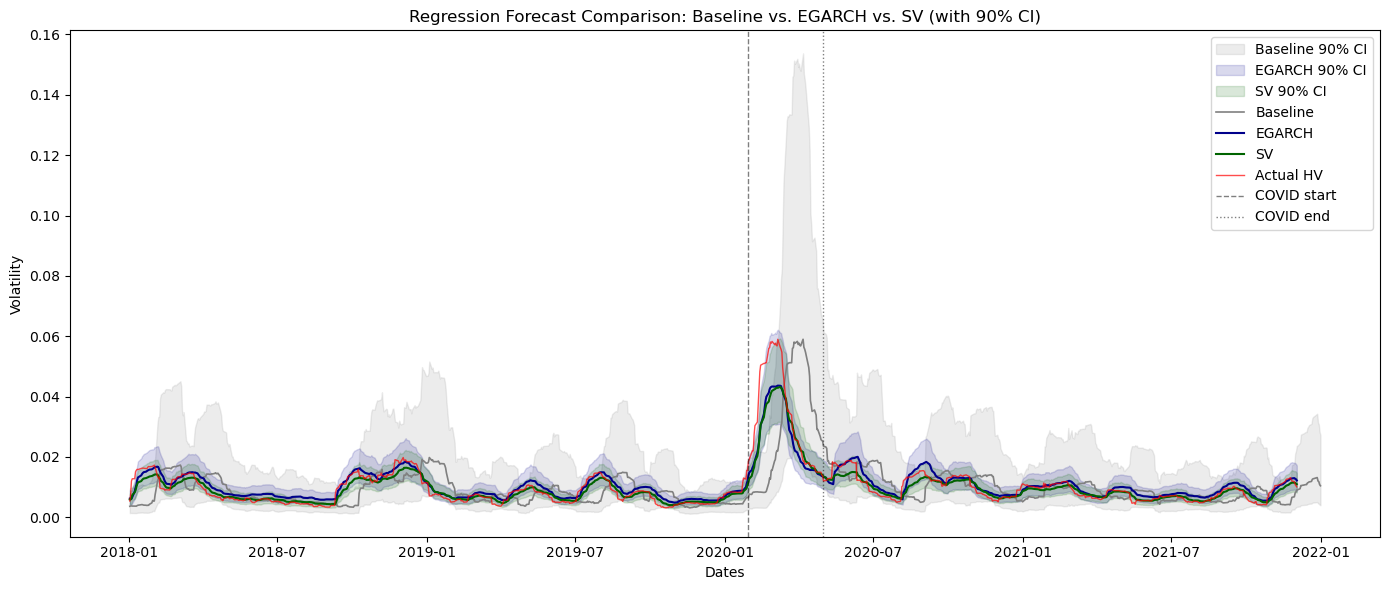

In [156]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(dates_regression_rolling, lower_90_regression_rolling, upper_90_regression_rolling,
                 color='gray', alpha=0.15, label='Baseline 90% CI')
ax.fill_between(dates_regression_egarch, lower_90_egarch, upper_90_egarch,
                 color='darkblue', alpha=0.15, label='EGARCH 90% CI')
ax.fill_between(dates_regression_sv, lower_90_sv, upper_90_sv,
                 color='darkgreen', alpha=0.15, label='SV 90% CI')
ax.plot(dates_regression_rolling, forecast_regression_rolling, color='gray', lw=1.2, label='Baseline')
ax.plot(dates_regression_egarch, forecast_regression_egarch, color='darkblue', lw=1.5, label='EGARCH')
ax.plot(dates_regression_sv, forecast_regression_sv, color='darkgreen', lw=1.5, label='SV')
ax.plot(dates_regression_egarch, actual_regression_egarch, color='red', lw=1, label='Actual HV', alpha=0.7)
ax.axvline(covid_start_date, color='black', linestyle='--', alpha=0.5, lw=1, label='COVID start')
ax.axvline(covid_end_date, color='black', linestyle=':', alpha=0.5, lw=1, label='COVID end')
ax.set_title("Regression Forecast Comparison: Baseline vs. EGARCH vs. SV (with 90% CI)")
ax.set_xlabel("Dates")
ax.set_ylabel("Volatility")
ax.legend()
plt.tight_layout()
plt.savefig("results/comparison_hv_regression.pdf", bbox_inches='tight')
plt.savefig("results/comparison_hv_regression.png", bbox_inches='tight')
plt.show()

In [ ]:
# ── Baseline's 2022-2025 "Regression" coverage band -- pooled sigma_eta, same mechanism
# as the pooled coverage % table in Section 2 (not the windowed one Sequential uses) ──
lower_rolling_r22, upper_rolling_r22, _, _ = hv_coverage_intervals(
    forecast_sequential_rolling, actual_sequential_rolling, level=90, sigma_eta=sigma_eta_rolling_r22
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(dates_sequential_rolling, lower_rolling_r22, upper_rolling_r22,
                 color='gray', alpha=0.15, label='Baseline 90% CI')
ax.fill_between(dates_regression_egarch_r22, lower_90_egarch_r22, upper_90_egarch_r22,
                 color='darkblue', alpha=0.15, label='EGARCH 90% CI')
ax.fill_between(dates_regression_sv_r22, lower_90_sv_r22, upper_90_sv_r22,
                 color='darkgreen', alpha=0.15, label='SV 90% CI')
ax.plot(dates_sequential_rolling, forecast_sequential_rolling, color='gray', lw=1.2, label='Baseline')
ax.plot(dates_regression_egarch_r22, forecast_regression_egarch_r22, color='darkblue', lw=1.5, label='EGARCH')
ax.plot(dates_regression_sv_r22, forecast_regression_sv_r22, color='darkgreen', lw=1.5, label='SV')
ax.plot(dates_regression_egarch_r22, actual_regression_egarch_r22, color='red', lw=1, label='Actual HV', alpha=0.7)
for b in window_boundaries:
    ax.axvline(b, color='black', linestyle='--', alpha=0.3, lw=0.8)
ax.set_title("2022-2025 Regression Forecast Comparison: Baseline vs. EGARCH vs. SV (with 90% CI)")
ax.legend()
plt.tight_layout()
plt.savefig("results/comparison_hv_2022_regression.pdf", bbox_inches='tight')
plt.savefig("results/comparison_hv_2022_regression.png", bbox_inches='tight')
plt.show()

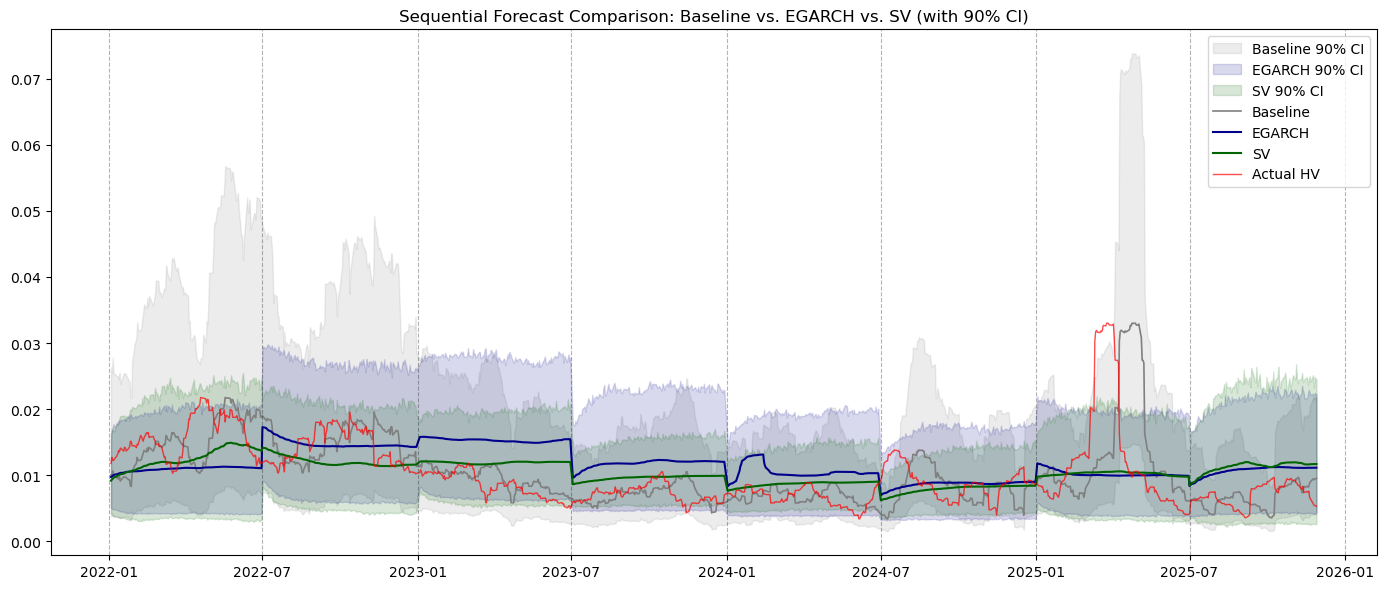

In [157]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(dates_sequential_rolling, lower_seq_rolling, upper_seq_rolling,
                 color='gray', alpha=0.15, label='Baseline 90% CI')
ax.fill_between(dates_sequential_egarch, lower_seq_egarch, upper_seq_egarch,
                 color='darkblue', alpha=0.15, label='EGARCH 90% CI')
ax.fill_between(dates_sequential_sv, lower_seq_sv, upper_seq_sv,
                 color='darkgreen', alpha=0.15, label='SV 90% CI')
ax.plot(dates_sequential_rolling, forecast_sequential_rolling, color='gray', lw=1.2, label='Baseline')
ax.plot(dates_sequential_egarch, forecast_sequential_egarch, color='darkblue', lw=1.5, label='EGARCH')
ax.plot(dates_sequential_sv, forecast_sequential_sv, color='darkgreen', lw=1.5, label='SV')
ax.plot(dates_sequential_egarch, actual_sequential_egarch, color='red', lw=1, label='Actual HV', alpha=0.7)
for b in window_boundaries:
    ax.axvline(b, color='black', linestyle='--', alpha=0.3, lw=0.8)
ax.set_title("Sequential Forecast Comparison: Baseline vs. EGARCH vs. SV (with 90% CI)")
ax.legend()
plt.tight_layout()
plt.savefig("results/comparison_hv_sequential.pdf", bbox_inches='tight')
plt.savefig("results/comparison_hv_sequential.png", bbox_inches='tight')
plt.show()

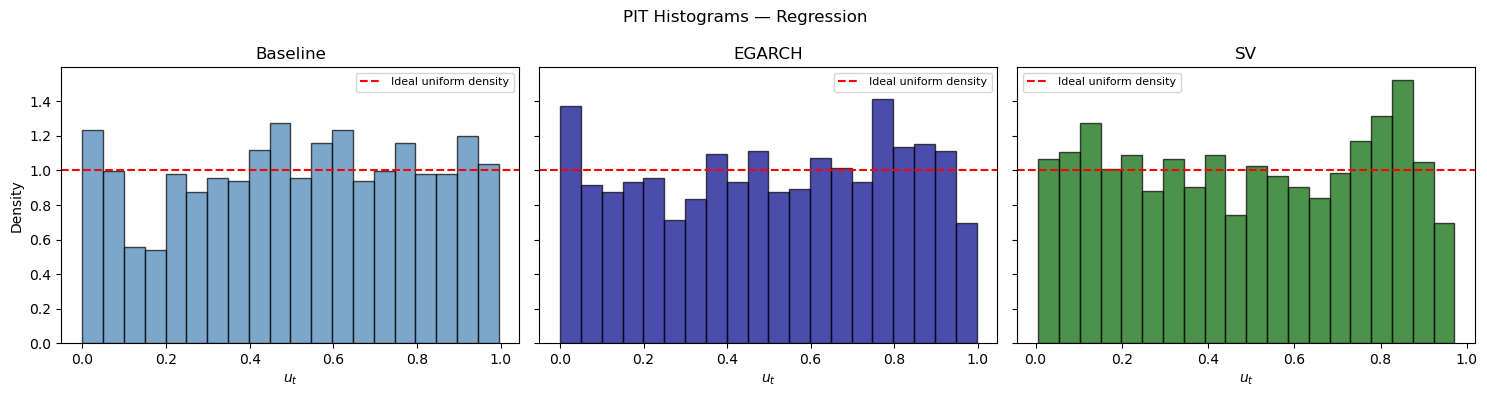

In [158]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

pit_data = [
    ("Baseline", u_t_regression_rolling, 'steelblue'),
    ("EGARCH",   u_t_regression_egarch,  'darkblue'),
    ("SV",       u_t_regression_sv,      'darkgreen'),
]

for ax, (label, u_t, color) in zip(axes, pit_data):
    ax.hist(u_t, bins=20, density=True, color=color, edgecolor='black', alpha=0.7)
    ax.axhline(1.0, color='red', linestyle='--', label='Ideal uniform density')
    ax.set_title(f"{label}")
    ax.set_xlabel("$u_t$")
    if ax is axes[0]:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("PIT Histograms — Regression")
plt.tight_layout()
plt.savefig("results/pit_histograms_regression.pdf", bbox_inches='tight')
plt.savefig("results/pit_histograms_regression.png", bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

pit_data_2022_regression = [
    ("Baseline", u_t_sequential_rolling, 'steelblue'),
    ("EGARCH",   u_t_regression_egarch_r22, 'darkblue'),
    ("SV",       u_t_regression_sv_r22,     'darkgreen'),
]

for ax, (label, u_t, color) in zip(axes, pit_data_2022_regression):
    ax.hist(u_t, bins=20, density=True, color=color, edgecolor='black', alpha=0.7)
    ax.axhline(1.0, color='red', linestyle='--', label='Ideal uniform density')
    ax.set_title(f"{label}")
    ax.set_xlabel("$u_t$")
    if ax is axes[0]:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("PIT Histograms — 2022-2025, Regression")
plt.tight_layout()
plt.savefig("results/pit_histograms_2022_regression.pdf", bbox_inches='tight')
plt.savefig("results/pit_histograms_2022_regression.png", bbox_inches='tight')
plt.show()

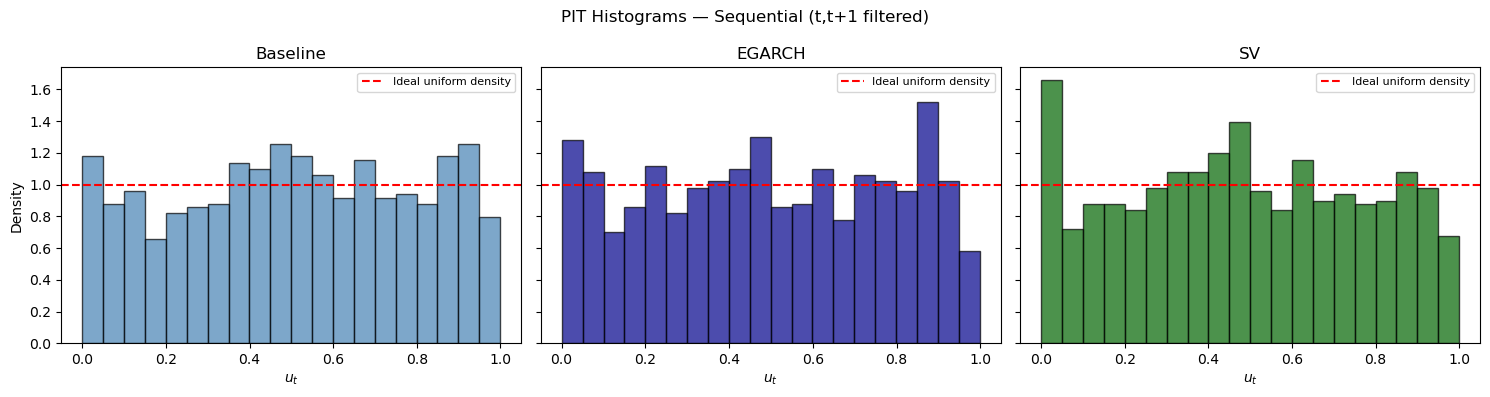

In [159]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

pit_data_seq = [
    ("Baseline", u_t_sequential_rolling, 'steelblue'),
    ("EGARCH",   all_pit_values_egarch_seq_filtered, 'darkblue'),
    ("SV",       all_pit_values_sv_seq_filtered,     'darkgreen'),
]

for ax, (label, u_t, color) in zip(axes, pit_data_seq):
    ax.hist(u_t, bins=20, density=True, color=color, edgecolor='black', alpha=0.7)
    ax.axhline(1.0, color='red', linestyle='--', label='Ideal uniform density')
    ax.set_title(f"{label}")
    ax.set_xlabel("$u_t$")
    if ax is axes[0]:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("PIT Histograms — Sequential (t,t+1 filtered)")
plt.tight_layout()
plt.savefig("results/pit_histograms_sequential.pdf", bbox_inches='tight')
plt.savefig("results/pit_histograms_sequential.png", bbox_inches='tight')
plt.show()

## Explaining Results

### Overview

The QLIKE regression results show that the EGARCH and SV volatility models are substantial improvements over the baseline model suggesting the models can forecast volatility well. However, both the models fail to generalize in the sequential setting. This suggests that the sequential approach requires changes, more windows under a shorter timeframe. Consequently, all the sequential results are potentially misleading for now.

However, conclusions can be drawn with regards to regression.

### EGARCH vs SV
The stochastic volatility model seems to perform better than EGARCH on pointwise estimates. It has a lower QLIKE mean and better HV coverage at different HV percentile with lower noise estimates i.e it is more representative of the true volatility with more useful predictions (since the confidence intervals are smaller). On the other hand, EGARCH is better at incorporating volatility properties since it does better on the PIT, ljung-Box tests and Enge-Bas tests which assess the model's responsiveness to shape, volatility clustering and leverage effect respectively.

###  COVID
For the COVID period, EGARCH does substantially better than SV and the baseline across all metrics,  i.e it adapts better to shocks in a regression setting.

### Baseline

With regards to the baseline, both EGARCH and stochastic volatility are clearly better at it on pointwise estimates. In terms of historical volatility, although the baseline model has good coverage, it also has a significantly wider confidence intervals making its predictions less useful. Additionally, it fails on all the volatility property tests.



